## Helpers

In [1]:
import torch
import math
import seaborn as sns

# set seed
torch.manual_seed(42)
sns.set_theme()
sns.set_palette("colorblind")

def interference_ds(a1, a2, x):
    """Computes interference E_x[||a1x - a2x||]
    
    Args:
        a1, a2 (torch.Tensor): (D,D)
        x (torch.Tensor): (N, D)

    Returns:
        float: interference
    """
    if a1.ndim == 1:
        a1 = a1.unsqueeze(0)
    if a2.ndim == 1:
        a2 = a2.unsqueeze(0)
    diff = a1 @ x.T - a2 @ x.T  # shape (D, N)
    return torch.linalg.norm(diff, dim=0).mean().item()


def interference_mats(a1, a2, x):
    """Computes interference E_x[||a1x - a2x||]
    
    Args:
        a1, a2 (torch.Tensor): (D,D)
        x (torch.Tensor): (N, D)

    Returns:
        float: interference
    """
    diff = a1 @ x.T - a2 @ x.T  # shape (D, N)
    return torch.linalg.norm(diff, dim=0).mean().item()

# For debugging
def interference_abs(a1, a2, x):
    """Computes interference E_x[||a1x - a2x||]
    
    Args:
        a1, a2 (torch.Tensor): (D)
        x (torch.Tensor): (N, D)

    Returns:
        float: interference
    """
    assert a1.ndim == 1 and a2.ndim == 1, "a1 and a2 must be 1D"
    diffs = (a1 - a2) @ x.T  # shape (N,)
    return diffs.abs().mean().item()

def rot2d(theta: float) -> torch.Tensor:
    # Only supports 2D rotation
    tt = torch.tensor(theta)
    return torch.tensor([
        [torch.cos(tt), -torch.sin(tt)],
        [torch.sin(tt),  torch.cos(tt)]
    ])

def create_datasets_and_task_vectors_2d(theta, sigma_perturb=0.05, sigma_scale=0.1, n_samples=1000, t0idx=-1, sigma_mag=0.0):
    # thetas is a list of angles
    t0 = torch.eye(2)[t0idx]
    t1 = rot2d(theta) @ t0
    task_vectors = torch.stack([t0, t1], dim=0) # (N, D) = (2, 2)
    task_vectors = task_vectors / torch.linalg.norm(task_vectors, dim=1, keepdim=True)

    if sigma_mag > 0.0:
        task_vectors = task_vectors * (1.0 + (torch.randn(2, 1) * sigma_mag))

    n_tasks, d_task = task_vectors.shape[0], task_vectors.shape[1]
    x_tasks = task_vectors + torch.randn(n_samples, n_tasks, d_task) * sigma_perturb
    x_tasks = x_tasks * (1.0 + torch.randn(n_samples, n_tasks, 1) * sigma_scale)
    return x_tasks, task_vectors


def create_datasets_and_task_vectors(n_tasks=3, d_task=32, sigma_perturb=0.05, sigma_scale=0.1, n_samples=1000):
    task_vectors = torch.randn(n_tasks, d_task)
    task_vectors = task_vectors / torch.linalg.norm(task_vectors, dim=1, keepdim=True)
    x_tasks = task_vectors + torch.randn(n_samples, n_tasks, d_task) * sigma_perturb
    # random scaling but same direction
    x_tasks = x_tasks * (1.0 + torch.randn(n_samples, n_tasks, 1) * sigma_scale)
    return x_tasks, task_vectors



def merge_tsv_mags(x: torch.Tensor, mags=False):
    """Merges task vectors x: (N, D)"""
    # make all xs unit vectors
    N, D = x.shape
    m = torch.linalg.norm(x, dim=1, keepdim=True) if mags else torch.ones(N)
    print(m)
    x_unit = x / m
    # u, _, vt = torch.linalg.svd(x_unit, full_matrices=False)
    q = compute_procrustes(x_unit.T).T  
    # add mags
    return (m * q).sum(dim=0)



def cos_sim(a, b):
    a, b = a.flatten(), b.flatten()
    return a.T @ b / (torch.linalg.norm(a) * torch.linalg.norm(b))


def merge_dwa1(us):
    """Merges task vectors using the DWA method.
    
    Args:
        us (torch.Tensor): (N, D)

    Returns:
        torch.Tensor: (N, *)
    """
    N, D = us.shape
    us_expanded = us.unsqueeze(0).repeat(N, 1, 1)
    m = torch.arange(1, N+1)  # multipliers
    w = m.reshape(-1, 1, 1) * us_expanded
    w = w / N**2
    w = w.sum(dim=0)
    return w.sum(dim=0)

def merge_dwa2(us, mode='all', p=0.5):
    N, D = us.shape
    P = math.pow(N, p)
    C = 2*P/(N*N*(N+1))
    us_expanded = us.unsqueeze(0).repeat(N, 1, 1)
    alphas = torch.arange(1, N+1) * C

    if mode != 'all':
        # boundary sum only
        # multiply by 0 for all but the first and last alpha
        alphas = (torch.eye(N)[0] + torch.eye(N)[-1]) * alphas

    w = us_expanded * alphas.reshape(-1, 1, 1)
    w = w.sum(dim=0).sum(dim=0)  # (D,)
    return w


def merge_mci(us):
    """Merges task vectors using the min constructive interference method.
    
    Args:
        us (torch.Tensor): (N, D)

    Returns:
        torch.Tensor: (D,)
    """

    w_bar = us.sum(dim=0)
    p_k = torch.einsum('ni,nj->nij', us, us)
    p_bar = p_k.sum(dim=0)
    # u, s, vt = torch.linalg.svd(p_bar, full_matrices=False)
    # p_pinv = vt.T @ torch.linalg.inv(s) @ u.T
    p_pinv = torch.linalg.pinv(p_bar)
    w_m = p_pinv @ w_bar
    return w_m

def merge_mci_mats(ws, mode='left'):
    """Merges task vectors using the min constructive interference method.
    
    Args:
        us (torch.Tensor): (N, Do, Di)

    Returns:
        torch.Tensor: (Do, Di)
    """
    N, Do, Di = ws.shape
    w_bar = ws.sum(dim=0)
    us, _, vts = torch.linalg.svd(ws, full_matrices=True)
    if mode == 'left':
        R = Do // N
        us = us[:, :, :R]
        p_k = torch.bmm(us, us.transpose(1, 2))  # (N, Do, Do)
        p_bar = p_k.sum(dim=0)
        p_pinv = torch.linalg.pinv(p_bar)
        w_m = p_pinv @ w_bar
    elif mode == 'right':
        R = Di // N
        vts = vts[:, :R, :]
        p_k = torch.bmm(vts.transpose(1, 2), vts)  # (N, Do, Do)
        p_bar = p_k.sum(dim=0)
        p_pinv = torch.linalg.pinv(p_bar)
        w_m = w_bar @ p_pinv
    elif mode == 'both':
        raise NotImplementedError("Both mode not implemented (computationally intensive)")
    return w_m

def merge_proj(ws, mode="right", *args, **kwargs):
    """Merges task vectors using the min constructive interference method.

    Args:
        us (torch.Tensor): (N, Do, Di)

    Returns:
        torch.Tensor: (Do, Di)
    """
    N_tasks = len(ws)
    u, s, vt = torch.linalg.svd(ws, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, B*Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (B*Rp, Do)
    # tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    p_vo = torch.einsum("ij,jk->ik", vt_ortho.T, vt_ortho)
    p_uo = torch.einsum("ij,jk->ik", u_ortho, u_ortho.T)
    # if mode == "right":
    #     tau_l = torch.einsum("bij,bj,bjk,kk->bik", u, s, vt, p_vo).sum(dim=0)
    # else:  # mode == "both"
    tau_l = torch.einsum("ni,bik,km->bnm", p_uo, ws, p_vo).mean(dim=0)
    return tau_l

def merge_proj_simple(ws, reduce="mean", *args, **kwargs):
    # ws: (N, Do, Di)
    u, s, vt = torch.linalg.svd(ws, full_matrices=False)
    pu = torch.einsum("bij,bjk->bij", u, u.transpose(1, 2)).mean(dim=0)
    pv = torch.einsum("bij,bjk->bij", vt.transpose(1, 2), vt).mean(dim=0)
    ws_proj = torch.einsum("ni,bij,jm->bnm", pu, ws, pv)
    if reduce == "mean":
        ws_proj = ws_proj.mean(dim=0)
    elif reduce == "sum":
        ws_proj = ws_proj.sum(dim=0)
    else:
        raise ValueError(f"Invalid reduce method: {reduce}")
    return ws_proj

def merge_proj_direct(us, *args, **kwargs):
    # us: (N, Do, Di) and orthogonal
    pu = torch.einsum("bij,bjk->bij", us, us.transpose(1, 2)).mean(dim=0)
    
    pass

def merge_aproptwa(ws, *args, **kwargs):
    """Approximately optimal WA."""
    N, Do, Di = ws.shape
    E = torch.einsum("pij,qji", ws, ws.transpose(1, 2))
    alpha = torch.linalg.pinv(E) @ E.sum(dim=-1)
    # print("E", E)
    # print("alpha", alpha)
    return 1/N * torch.einsum("nij,n->ij", ws, alpha)

def merge_aproptwa_vec(Ws):
    # Ws: (N, D)
    E = Ws @ Ws.T
    beta = 1/(E.sum(dim=-1))
    Einv = torch.linalg.pinv(E)
    alpha = 1/beta.sum() * Einv @ (torch.einsum("i,ij->j", beta, E))
    Wm = torch.einsum("n,ni->i", alpha, Ws)
    return Wm

def merge_min_angle(ws, *args, **kwargs):
    """Merges task vectors using the min angle method. I.e., (11ᵀ ΣₖWₜᵀ)(Σₜ Wₜᵀ Wₜ)^†.

    Args:
        ws_raw (torch.Tensor): (N, Do, Di)

    Returns:
        torch.Tensor: (Do, Di)
    """
    # Normalize rows
    N, Do, Di = ws.shape
    w_tilde = ws / ws.norm(dim=-1, keepdim=True)
    w_tilde_bar = w_tilde.sum(dim=0)
    wtw_tilde_bar = torch.bmm(w_tilde.transpose(1, 2), w_tilde).sum(dim=0)
    return torch.ones(Do, Do) @ w_tilde_bar @ torch.linalg.pinv(wtw_tilde_bar)


def merge_tsv_variant(tensors, *args, **kwargs):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = max(R // N_tasks, 1)
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, B*Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (B*Rp, Do)
    w_bar = tensors.mean(dim=0)  # (Di, Do)
    s_hat = torch.einsum("ik,kl,lj->ij", u_ortho, w_bar, vt_ortho)
    s_hat = torch.diag(s_hat)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)  # (Di, Do)
    return tau_l



def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    """Finds best ortho approx of x

    Args:
        x (torch.Tensor): (Di, Do)

    Returns:
        torch.Tensor: (Di, Do)
    """
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt


def merge_tsv(tensors, *args, **kwargs):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)  # (Di, Do)
    return tau_l


@torch.no_grad()
def merge_wa_asym(
    Ws: torch.Tensor,  # (T, Do, Di) real-valued
    k: int = 1024,  # rank of shared subspace
    n_splits: int = 4,  # number of random entrywise splits to average
    p_split: float = 0.5,  # split prob
    seed: int = 0,
    return_debug: bool = False,
    **kwargs,
):
    """
    Rectangular multi-task combining via an Asymmetric-PCA-style shared subspace.

    Ws: (T, Do, Di)

    High-level (rectangular version):
      - For each split s and task t:
          W = W1 + W2 via entrywise Bernoulli mask
          X_t = W1 @ W2.T    (Do x Do)
          Y_t = W2.T @ W1    (Di x Di)
      - Average over tasks and splits:
          Xbar = mean_{s,t} X_t,  Ybar = mean_{s,t} Y_t
      - Compute top-k eigenpairs of Xbar and Ybar
      - Average left+right eigenvectors (left from eig of A.T) for stability
      - Orthonormalize to get U (Do x k), V (Di x k)
      - Per task core: S_t = U.T @ W_t @ V   (k x k)
      - Merge core: Sbar = mean_t S_t
      - Return merged: W_merge = U @ Sbar @ V.T   (Do x Di)

    Collapses to "single W denoise" when T=1 (rank-k projection onto shared U,V).
    """

    assert Ws.ndim == 3, "Ws must be (T, Do, Di)"
    T, Do, Di = Ws.shape
    device = Ws.device
    dtype = Ws.dtype

    g = torch.Generator(device=device)
    g.manual_seed(seed)

    def _split(W: torch.Tensor):
        M = (torch.rand((Do, Di), generator=g, device=device) < p_split).to(dtype)
        return W * M, W * (1.0 - M)

    def _topk_avg_lr_evecs(A: torch.Tensor, k_use: int):
        """
        Returns Q (N x k_use) real orthonormal basis from averaged left/right eigenvectors,
        plus the selected eigenvalues (complex).
        """
        # Right eigenvectors of A
        evals_r, evecs_r = torch.linalg.eig(A)  # complex
        # "Left" eigenvectors are right eigenvectors of A.T
        evals_l, evecs_l = torch.linalg.eig(A.T)  # complex

        # Pick top-k by |lambda| (simple outlier proxy)
        idx_r = torch.topk(evals_r.abs().real, k=k_use, largest=True).indices
        lam = evals_r[idx_r]

        Z = []
        for j in idx_r.tolist():
            lr = evals_r[j]
            # match by closest eigenvalue in complex plane
            iL = torch.argmin((evals_l - lr).abs())
            vR = evecs_r[:, j]
            vL = evecs_l[:, iL]

            # Optional: crude phase/sign alignment to reduce cancellation
            ip = torch.vdot(vL, vR)  # conj(vL)^T vR
            if ip.abs() > 1e-12:
                vL = vL * torch.conj(ip / (ip.abs() + 1e-12))

            z = (vR + vL).real
            z = z / (z.norm() + 1e-12)
            Z.append(z)

        Z = torch.stack(Z, dim=1)  # (N, k_use)

        # Orthonormalize (stabilizes downstream core extraction)
        Q, _ = torch.linalg.qr(Z)
        return Q[:, :k_use], lam

    # Build averaged asymmetric matrices (Do x Do) and (Di x Di)
    Xbar = torch.zeros((Do, Do), device=device, dtype=dtype)
    Ybar = torch.zeros((Di, Di), device=device, dtype=dtype)

    for _ in range(n_splits):
        for t in range(T):
            W1, W2 = _split(Ws[t])
            Xbar += W1 @ W2.T
            Ybar += W2.T @ W1

    Xbar /= T * n_splits
    Ybar /= T * n_splits

    kU = min(k, Do)
    kV = min(k, Di)
    k_eff = min(kU, kV)

    # Shared bases
    U, lamX = _topk_avg_lr_evecs(Xbar, k_use=k_eff)  # (Do, k_eff)
    V, lamY = _topk_avg_lr_evecs(Ybar, k_use=k_eff)  # (Di, k_eff)

    # Per-task cores and merge
    cores = []
    for t in range(T):
        S_t = U.T @ Ws[t] @ V  # (k_eff, k_eff)
        cores.append(S_t)
    Sbar = torch.stack(cores, dim=0).mean(dim=0)

    Wm = U @ Sbar @ V.T  # (Do, Di)

    if return_debug:
        return Wm, {
            "U": U,
            "V": V,
            "Sbar": Sbar,
            "lamX": lamX,
            "lamY": lamY,
            "Xbar": Xbar,
            "Ybar": Ybar,
            "k_eff": k_eff,
        }
    return Wm


# def merge_3ltsv(tensors, *args, **kwargs):
#     # Compute SVDs
#     u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
#     ubar = u.sum(dim=0)
#     vbar = vt.sum(dim=0)
#     smean = s.mean(dim=0)
#     uorth = compute_procrustes(ubar)
#     vtorth = compute_procrustes(vbar.T).T  
#     return torch.einsum("ij,j,jk->ik", uorth, smean, vtorth)

import torch

def merge_3ltsv_corrected(tensors):
    # 1. Compute SVDs: U (B, M, K), S (B, K), Vh (B, K, N)
    u, s, vh = torch.linalg.svd(tensors, full_matrices=False)
    
    # --- FIX START: Resolve Sign Ambiguity ---
    # We fix the first tensor as the "anchor" and align others to it.
    # Check dot product of columns. If negative, flip signs of U and Vh.
    ref_u = u[0] # Reference basis
    ref_vh = vh[0]
    
    for i in range(1, u.shape[0]):
        # Calculate correlations with reference (simple column-wise dot)
        # Note: This is a heuristic. For strict alignment, use Procrustes between u[i] and ref_u
        dot_prod = (u[i] * ref_u).sum(dim=0) # Shape (K,)
        signs = torch.sign(dot_prod) # +1 or -1
        
        # Apply flips to U and Vh (S is always positive)
        u[i] = u[i] * signs.view(1, -1)
        vh[i] = vh[i] * signs.view(-1, 1)
    # --- FIX END ---

    # 2. Average the "Linear" part
    smean = s.mean(dim=0)

    # 3. Average the "Manifold" parts (Projected Mean)
    # Note: u.sum is now safe because signs are aligned
    ubar = u.sum(dim=0) 
    vbar = vh.sum(dim=0) # vh is V^T
    
    # 4. Project back to Manifold (Procrustes / Polar Decomposition)
    # U_orth = U (U^T U)^-1/2
    u_orth = compute_polar(ubar) 
    v_orth = compute_polar(vbar.T).T 

    # 5. Reconstruct
    return u_orth @ torch.diag(smean) @ v_orth

def compute_polar(A):
    # Helper to project A onto the orthogonal group
    # A = UP -> returns U
    U, S, Vh = torch.linalg.svd(A, full_matrices=False)
    return U @ Vh

def merge_maxvar(ws, *args, **kwargs):
    """Merges task vectors using the max variance method.

    Args:
        ws (torch.Tensor): (N, Do, Di)

    Returns:
        torch.Tensor: (Do, Di)
    """
    N, Do, Di = ws.shape
    k = torch.einsum("ik,ok->io", ws.reshape(N, -1), ws.reshape(N, -1))  # (N, N)
    # find top eigenvector of k
    e, v = torch.linalg.eigh(k)  # (N, N)
    # v is now used as mixture weights
    alpha = v[:, 0]
    print("alpha", alpha.shape)
    print("ws", ws.shape)
    wm = torch.einsum("n,npq->pq", alpha, ws)
    return wm

merge_maxvar(torch.randn(2, 32, 64)).shape


alpha torch.Size([2])
ws torch.Size([2, 32, 64])


torch.Size([32, 64])

In [22]:
tvs = torch.ones(2, 2)
tvs[1] = -1 * tvs[1]
compute_procrustes(tvs.T).T

tensor([[ 1.0000e+00, -2.9802e-08],
        [-2.9802e-08, -1.0000e+00]])

In [70]:
import torch

# --- data (yours) ---
V = torch.eye(3)
V = torch.cat([V, torch.tensor([[0, -1, 0]])], dim=0)
W1, W2 = V[:2], V[2:]
W_wa = (W1 + W2) / 2
W_ta = W1 + W2
W_tsv = merge_tsv(torch.stack([W1, W2], dim=0), mode="both")  # (2,3)
print("W1", W1)
print("W2", W2)
print("W_wa", W_wa)
print("W_ta", W_ta)
print("W_tsv", W_tsv)

# W1 tensor([[1., 0., 0.],
#         [0., 1., 0.]])
# W2 tensor([[ 0.,  0.,  1.],
#         [ 0., -1.,  0.]])
# W_wa tensor([[0.5000, 0.0000, 0.5000],
#         [0.0000, 0.0000, 0.0000]])
# W_tsv tensor([[ 0.7071,  0.0000,  0.7071],
#         [-0.7071,  0.0000,  0.7071]])

W1 tensor([[1., 0., 0.],
        [0., 1., 0.]])
W2 tensor([[ 0.,  0.,  1.],
        [ 0., -1.,  0.]])
W_wa tensor([[0.5000, 0.0000, 0.5000],
        [0.0000, 0.0000, 0.0000]])
W_ta tensor([[1., 0., 1.],
        [0., 0., 0.]])
W_tsv tensor([[ 0.7071,  0.0000,  0.7071],
        [-0.7071,  0.0000,  0.7071]])


In [71]:
W = torch.eye(2, 2)
W = torch.cat([W, torch.ones(1, 2)], dim=0)
Worth = compute_procrustes(W.T)
print("TSV", Worth.T.sum(dim=0))
print("TA", W.sum(dim=0))
print("WA", W.mean(dim=0))





TSV tensor([1.1547, 1.1547])
TA tensor([2., 2.])
WA tensor([0.6667, 0.6667])


In [72]:
N, D = 4, 4
w = torch.randn(N, D, D)
yk = 0
esum = 0
for k in range(N):
    ek = torch.einsum("i,j->ij", torch.eye(D)[k], torch.eye(D)[k])
    yk += w[k] @ ek
    esum += ek
    

torch.allclose(yk, w.sum(dim=0), atol=1e-6)

print("yk", yk)
print("w", w[0, :, 0])
print("w", w[1, :, 1])
print("w", w[2, :, 2])
print("w", w[3, :, 3])

# yk tensor([[ 1.1011,  1.0457,  1.6421,  0.2812],
#         [-0.8775, -0.8881,  0.4272,  0.1581],
#         [-0.5421, -0.3381,  2.1257,  0.3270],
#         [ 1.3210,  0.2171,  0.3966,  0.2302]])
# w tensor([ 1.1011, -0.8775, -0.5421,  1.3210])
# w tensor([ 1.0457, -0.8881, -0.3381,  0.2171])
# w tensor([1.6421, 0.4272, 2.1257, 0.3966])
# w tensor([0.2812, 0.1581, 0.3270, 0.2302])

yk tensor([[-0.5197, -1.4492, -0.8030, -1.6672],
        [-0.7373,  1.2677,  0.6624,  0.5637],
        [ 0.2123,  0.3301, -0.1798,  1.1078],
        [-0.4923,  1.3362, -0.1578, -0.8515]])
w tensor([-0.5197, -0.7373,  0.2123, -0.4923])
w tensor([-1.4492,  1.2677,  0.3301,  1.3362])
w tensor([-0.8030,  0.6624, -0.1798, -0.1578])
w tensor([-1.6672,  0.5637,  1.1078, -0.8515])


In [73]:
def merge_aproptwa_vec(Ws):
    # Ws: (N, D)
    E = Ws @ Ws.T
    beta = 1/(E.sum(dim=-1))
    Einv = torch.linalg.pinv(E)
    alpha = 1/beta.sum() * Einv @ (torch.einsum("i,ij->j", beta, E))
    Wm = torch.einsum("n,ni->i", alpha, Ws)
    return Wm
Ws = torch.tensor([[1.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0]])

Wm = merge_aproptwa_vec(Ws)
Wm


tensor([0.5000, 0.5000])

## Synthetic Data

### TSV Multi-Task Interference

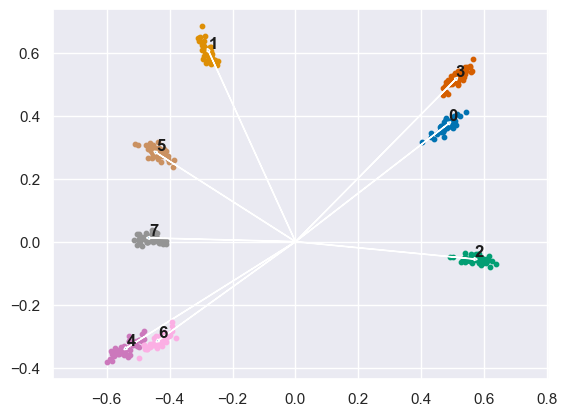

In [297]:
import torch
import matplotlib.pyplot as plt

# set seed
torch.manual_seed(42)

x, tvs = create_datasets_and_task_vectors(n_tasks=8, d_task=8, sigma_perturb=0.01, sigma_scale=0.05, n_samples=50)
for i in range(tvs.shape[0]):
    plt.scatter(x[:,i,0], x[:,i,1], s=10)
    plt.arrow(0, 0, tvs[i,0], tvs[i,1], head_width=0.01, head_length=0.01)
    plt.text(tvs[i,0], tvs[i,1], f"{i}", fontsize=12, color='k', ha='left', va='bottom', fontweight='bold')
plt.axis('equal')
plt.show()


torch.Size([8])


/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_63668/143733293.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_interference, x='Method', y='Interference', ax=ax2, palette=palette, order=method_order, dodge=False)


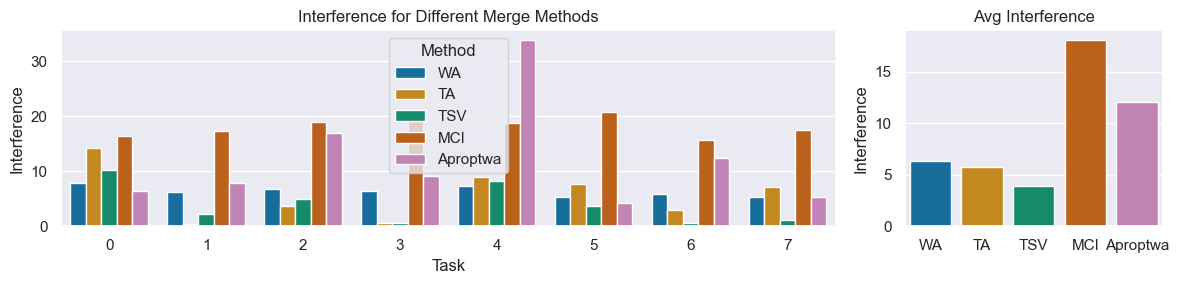

In [300]:
# Compute interference for different merge methods
import seaborn as sns
import pandas as pd

def interference_ds(a1, a2, x):
    """Computes interference E_x[||a1x - a2x||], where x ~ N(0, I)."""
    diff = a1 @ x.T - a2 @ x.T  # shape (D, N)
    norm = torch.linalg.norm(diff, dim=0)  # shape (N,)
    return norm.mean().item()

w_ta = tvs.sum(dim=0)     # (D,)
w_wa = tvs.mean(dim=0)    # (D,)
w_tsv = compute_procrustes(tvs.T).T.sum(dim=0)
w_dwa1 = merge_dwa1(tvs)
w_dwa2a = merge_dwa2(tvs, mode='all')
w_dwa2b = merge_dwa2(tvs, mode='boundary')
w_dwab_p1 = merge_dwa2(tvs, p=1)
w_mci = merge_mci(tvs)
w_aproptwa = merge_aproptwa_vec(tvs)
n_tasks = tvs.shape[0]
print(w_mci.shape)

data = []
for t in range(n_tasks):
    data.append({'Task': t, 'Method': 'TSV', 'Interference': interference_ds(w_tsv, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'TA', 'Interference': interference_ds(w_ta, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'WA', 'Interference': interference_ds(w_wa, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'DWA1', 'Interference': interference_ds(w_dwa1, tvs[t], x[:,t])})
    # data.append({'Task': t, 'Method': 'DWA2a', 'Interference': interference_ds(w_dwa2a, tvs[t], x[:,t])})
    # data.append({'Task': t, 'Method': 'DWA2b', 'Interference': interference_ds(w_dwa2b, tvs[t], x[:,t])})
    # data.append({'Task': t, 'Method': 'DWA2b_p1', 'Interference': interference_ds(w_dwab_p1, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'MCI', 'Interference': interference_ds(w_mci, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'Aproptwa', 'Interference': interference_ds(w_aproptwa, tvs[t], x[:,t])})
df = pd.DataFrame(data)

# Compute average interference for each method
avg_interference = df.groupby('Method')['Interference'].mean().reset_index()

# Specify a consistent palette for both plots, matching the order of methods
method_order = ['WA', 'TA', 'TSV', 'MCI', 'Aproptwa']
palette = dict(zip(method_order, sns.color_palette("colorblind", n_colors=len(method_order))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3), width_ratios=[3,1])

sns.barplot(data=df, x='Task', y='Interference', hue='Method', ax=ax1, palette=palette, hue_order=method_order)
ax1.set(title="Interference for Different Merge Methods", xlabel='Task', ylabel='Interference')

sns.barplot(data=avg_interference, x='Method', y='Interference', ax=ax2, palette=palette, order=method_order, dodge=False)
ax2.set(title="Avg Interference", ylabel='Interference', xlabel='')

plt.tight_layout()
plt.show()

<Axes: >

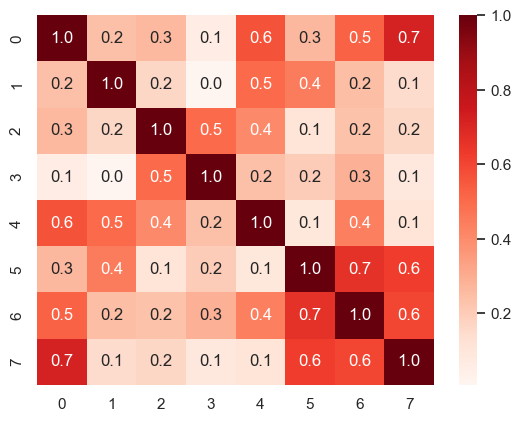

In [80]:
# Compute the proper cosine similarity matrix between all pairs of task vectors
tvs_norm = tvs / tvs.norm(dim=1, keepdim=True)  # (n_tasks, D)
cosim = tvs_norm @ tvs_norm.T  # (n_tasks, n_tasks)
cosim = cosim.abs()

# Use a perceptually uniform palette for the heatmap (cmap="viridis" or "mako")
sns.heatmap(
    cosim.cpu().numpy(), 
    fmt=".1f", 
    cbar=True, 
    cmap="Reds",    # Try 'mako', 'viridis', or 'rocket' for a better palette
    annot=True      # Optional: show values
)

### MCI Multi-Task Interference (as n_tasks varied)

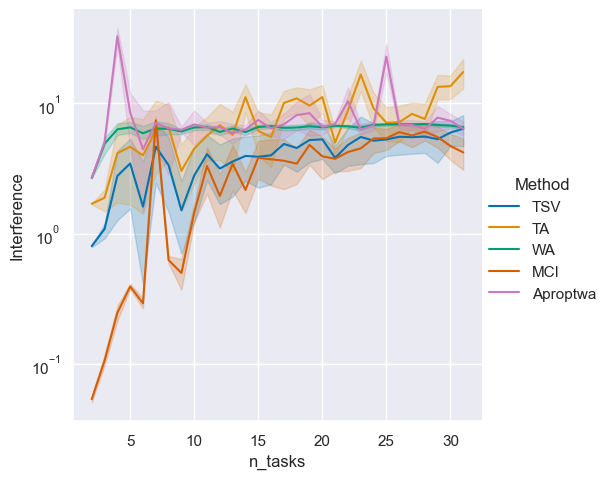

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def interference_ds(a1, a2, x):
    """Computes interference E_x[||a1x - a2x||], where x ~ N(0, I)."""
    diff = a1 @ x.T - a2 @ x.T  # shape (D, N)
    norm = torch.linalg.norm(diff, dim=0)  # shape (N,)
    return norm.mean().item()


# set seed
torch.manual_seed(42)
data = []
for n_tasks in range(2, 32):
    x, tvs = create_datasets_and_task_vectors(n_tasks=n_tasks, d_task=8, sigma_perturb=0.01, sigma_scale=0.05, n_samples=50)
    w_ta = tvs.sum(dim=0)     # (D,)
    w_wa = tvs.mean(dim=0)    # (D,)
    w_tsv = compute_procrustes(tvs.T).T.sum(dim=0)
    w_mci = merge_mci(tvs)
    w_aproptwa = merge_aproptwa_vec(tvs)

    for t in range(n_tasks):
        for method_name, method_mat in zip(['TSV', 'TA', 'WA', 'MCI', 'Aproptwa'], [w_tsv, w_ta, w_wa, w_mci, w_aproptwa]):
            data.append({'Task': t, 'Method': method_name, 'Interference': interference_ds(method_mat, tvs[t], x[:,t]), 'n_tasks': n_tasks})

df = pd.DataFrame(data)
# Plot just the mean interference per method, no error bars
sns.lineplot(data=df, x='n_tasks', y='Interference', hue='Method', errorbar=None)
plt.yscale("log")


tensor([[1., 0.],
        [0., 0.]])


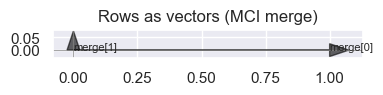

In [ ]:
import torch
import matplotlib.pyplot as plt

# given
# w1, w2 = torch.randn(2, 2), torch.randn(2, 2)
# illustrative matrices (rows are vectors)
w1 = torch.tensor([[1.0, 0.0],
                   [0.0, 1.0]])      # basis directions

w2 = torch.tensor([[1.0, 1.0],
                   [1.0, -1.0]])     # rotated / mixed directions
w2 = w1

ws = torch.stack([w1, w2], dim=0)
w = merge_mci_mats(ws, mode="right")
print(w)
# w = merge_proj(ws, mode="both")

plt.figure(figsize=(4, 4))

# # plot rows of ws
# for i in range(ws.shape[0]):
#     for j in range(ws.shape[1]):
#         v = ws[i, j]
#         plt.arrow(0, 0, v[0], v[1], head_width=0.05, alpha=0.6)
#         plt.text(v[0], v[1], f"w{i+1}[{j}]", fontsize=9)

# plot rows of merged w
for j in range(w.shape[0]):
    v = w[j]
    plt.arrow(0, 0, v[0], v[1], color="black", head_width=0.05, alpha=0.6)
    plt.text(v[0], v[1], f"merge[{j}]", fontsize=8)

plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.gca().set_aspect("equal")
plt.title("Rows as vectors (MCI merge)")
plt.grid(True)
plt.show()




In [37]:
w1 = torch.tensor([[1.0, 0.0],
                   [0.0, 1.0]])      # basis directions
w2 = w1
ws = torch.stack([w1, w2], dim=0)

N, Do, Di = ws.shape
w_bar = ws.sum(dim=0)
us, _, vts = torch.linalg.svd(ws, full_matrices=True)
R = Di // N
vts = vts[:, :R, :]
p_k = torch.bmm(vts.transpose(1, 2), vts)  # (N, Do, Do)
p_bar = p_k.sum(dim=0)
p_pinv = torch.linalg.pinv(p_bar)
w_m = w_bar @ p_pinv
vts


tensor([[[1., 0.]],

        [[1., 0.]]])

### TSV 2-Task Partial Interference Sweep -- Unit Vector

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_63668/3184978153.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)


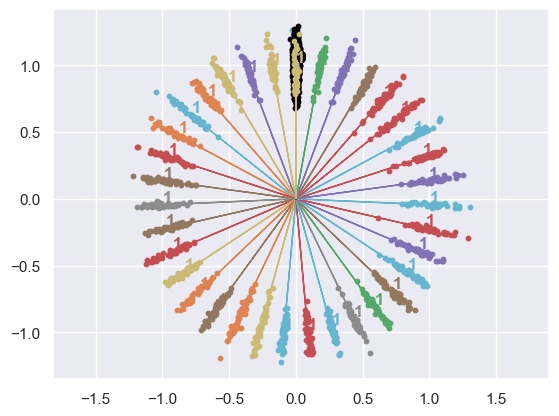

In [301]:
import torch
import math
import matplotlib.pyplot as plt
import random
sns.set_theme()

exps = []
for idx, theta_v in enumerate(torch.linspace(0, math.pi*2, steps=36)):
    x, tvs = create_datasets_and_task_vectors_2d(theta_v, sigma_perturb=0.01, sigma_scale=0.1, n_samples=50)
    exps.append((x, tvs, theta_v))
    for t in range(2):
        color = 'black' if t == 0 else random.choice(['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9'])
        plt.scatter(x[:,t,0], x[:,t,1], s=10, color=color, label=f'Task {t}' if idx == 0 else None)
        plt.arrow(0, 0, tvs[t,0], tvs[t,1], head_width=0.01, head_length=0.01, color=color)
        plt.text(tvs[t,0], tvs[t,1], f"{t}", fontsize=12, color=color, ha='left', va='bottom', fontweight='bold')
plt.axis('equal')
plt.show()


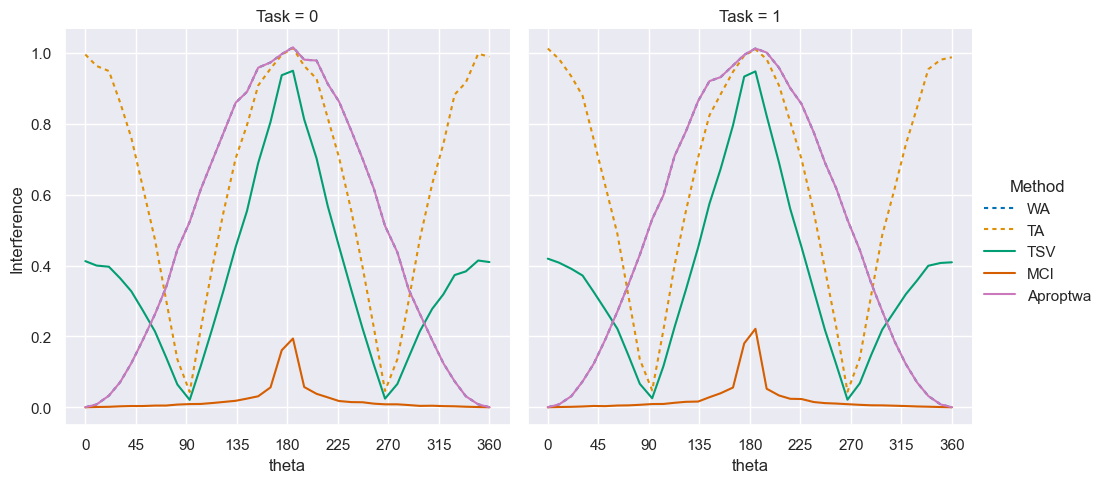

In [306]:
# Compute interference for different merge methods
import seaborn as sns
import pandas as pd
sns.set_theme()
sns.set_palette("colorblind")

data = []
for x, tvs, theta_v in exps:
    w_ta = tvs.sum(dim=0)     # (D,)
    w_wa = tvs.mean(dim=0)    # (D,)
    w_tsv = compute_procrustes(tvs.T).T.sum(dim=0)
    w_dwa1 = merge_dwa1(tvs)
    w_dwa2 = merge_dwa2(tvs)
    w_mci = merge_mci(tvs)
    w_aproptwa = merge_aproptwa_vec(tvs)
    n_tasks = tvs.shape[0]
    theta_deg = torch.round(theta_v * 180 / math.pi).item()
    for t in range(n_tasks):
        data.append({'Task': t, 'Method': 'WA', 'Interference': interference_abs(w_wa, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'TA', 'Interference': interference_abs(w_ta, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'TSV', 'Interference': interference_abs(w_tsv, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'MCI', 'Interference': interference_abs(w_mci, tvs[t], x[:,t]), 'theta': theta_deg})
        # data.append({'Task': t, 'Method': 'DWA1', 'Interference': interference_abs(w_dwa1, tvs[t], x[:,t]), 'theta': theta_deg})
        # data.append({'Task': t, 'Method': 'DWA2', 'Interference': interference_abs(w_dwa2, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'Aproptwa', 'Interference': interference_abs(w_aproptwa, tvs[t], x[:,t]), 'theta': theta_deg})
df = pd.DataFrame(data)

# Emphasize TSV in palette and marker
# g = sns.relplot(data=df, x='theta', y='Interference', kind='line', col='Task', style='Method',  hue='Method', dashes={"TSV": "", "DWA": "", "TA": (2, 2), "WA": (2, 2)})
g = sns.relplot(
    data=df, x="theta", y="Interference",
    kind="line", col="Task",
    hue="Method", style="Method",
    dashes={"TSV": "", "DWA1": "", "DWA2": "", "TA": (2, 2), "WA": (2, 2), "MCI": "", "Aproptwa": ""}
)
g.set(xticks=list(range(0, 361, 45)))


### TSV 2-Task Partial Interference Sweep -- Vector w/ Magnitude Noise

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_19916/473518557.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)


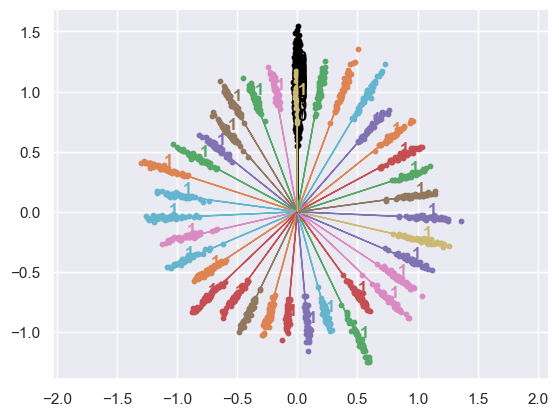

tensor([1.0181, 0.9515])


In [38]:
import torch
import math
import matplotlib.pyplot as plt
import random
sns.set_theme()

exps = []
for idx, theta_v in enumerate(torch.linspace(0, math.pi*2, steps=36)):
    x, tvs = create_datasets_and_task_vectors_2d(theta_v, sigma_perturb=0.01, sigma_scale=0.1, n_samples=50, sigma_mag=0.1)
    exps.append((x, tvs, theta_v))
    for t in range(2):
        color = 'black' if t == 0 else random.choice(['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9'])
        plt.scatter(x[:,t,0], x[:,t,1], s=10, color=color, label=f'Task {t}' if idx == 0 else None)
        plt.arrow(0, 0, tvs[t,0], tvs[t,1], head_width=0.01, head_length=0.01, color=color)
        plt.text(tvs[t,0], tvs[t,1], f"{t}", fontsize=12, color=color, ha='left', va='bottom', fontweight='bold')
plt.axis('equal')
plt.show()

# print dist of mags
print(torch.linalg.norm(tvs, dim=1))

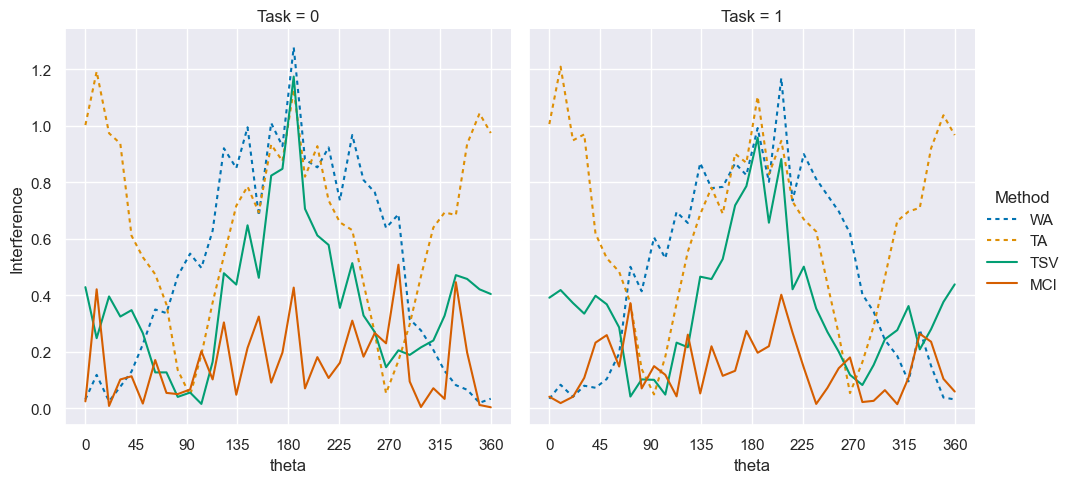

In [41]:
# Compute interference for different merge methods
import seaborn as sns
import pandas as pd
sns.set_theme()
sns.set_palette("colorblind")

data = []
for x, tvs, theta_v in exps:
    w_ta = tvs.sum(dim=0)     # (D,)
    w_wa = tvs.mean(dim=0)    # (D,)
    w_tsv = compute_procrustes(tvs.T).T.sum(dim=0)
    w_dwa1 = merge_dwa1(tvs)
    w_dwa2 = merge_dwa2(tvs)
    w_mci = merge_mci(tvs)
    n_tasks = tvs.shape[0]
    theta_deg = torch.round(theta_v * 180 / math.pi).item()
    for t in range(n_tasks):
        data.append({'Task': t, 'Method': 'WA', 'Interference': interference_abs(w_wa, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'TA', 'Interference': interference_abs(w_ta, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'TSV', 'Interference': interference_abs(w_tsv, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'MCI', 'Interference': interference_abs(w_mci, tvs[t], x[:,t]), 'theta': theta_deg})
        # data.append({'Task': t, 'Method': 'DWA1', 'Interference': interference_abs(w_dwa1, tvs[t], x[:,t]), 'theta': theta_deg})
        # data.append({'Task': t, 'Method': 'DWA2', 'Interference': interference_abs(w_dwa2, tvs[t], x[:,t]), 'theta': theta_deg})
df = pd.DataFrame(data)

# Emphasize TSV in palette and marker
# g = sns.relplot(data=df, x='theta', y='Interference', kind='line', col='Task', style='Method',  hue='Method', dashes={"TSV": "", "DWA": "", "TA": (2, 2), "WA": (2, 2)})
g = sns.relplot(
    data=df, x="theta", y="Interference",
    kind="line", col="Task",
    hue="Method", style="Method",
    dashes={"TSV": "", "DWA1": "", "DWA2": "", "TA": (2, 2), "WA": (2, 2), "MCI": ""}
)
g.set(xticks=list(range(0, 361, 45)))


### TSV 2-Task Partial Interference Sweep -- Matrix

alpha torch.Size([2])
ws torch.Size([2, 2, 2])

Angle (degrees): 0.00
ta error: 1.00, 1.00
wa error: 0.00, 0.00
tsv error: 0.00, 0.00
isoc error: 0.00, 0.00
mci_l error: 0.00, 0.00
mci_r error: 0.00, 0.00
proj error: 0.00, 0.00
proj_aproptwa error: 0.00, 0.00
asym error: 0.00, 0.00
maxvar error: 1.00, 1.00
alpha torch.Size([2])
ws torch.Size([2, 2, 2])

Angle (degrees): 30.00
ta error: 0.87, 0.87
wa error: 0.07, 0.07
tsv error: 0.26, 0.26
isoc error: 0.26, 0.26
mci_l error: 0.07, 0.07
mci_r error: 0.00, 0.00
proj error: 0.07, 0.07
proj_aproptwa error: 0.07, 0.07
asym error: 0.07, 0.07
maxvar error: 1.09, 0.91
alpha torch.Size([2])
ws torch.Size([2, 2, 2])

Angle (degrees): 60.00
ta error: 0.50, 0.50
wa error: 0.25, 0.25
tsv error: 0.52, 0.52
isoc error: 0.50, 0.50
mci_l error: 0.25, 0.25
mci_r error: 0.00, 0.00
proj error: 0.25, 0.25
proj_aproptwa error: 0.25, 0.25
asym error: 0.25, 0.25
maxvar error: 1.35, 0.65
alpha torch.Size([2])
ws torch.Size([2, 2, 2])

Angle (degrees): 90.00
ta 

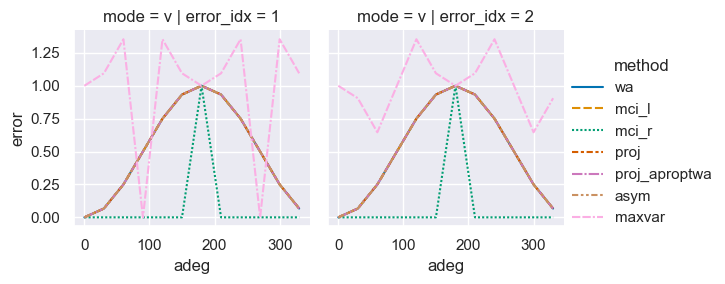

In [10]:
import torch
import math
import itertools
import pandas as pd

def merge_isoc(mats):
    m = sum(mats)
    u, s, vt = torch.linalg.svd(m)
    s_mean = s.mean() * torch.ones_like(s)
    return torch.einsum('ik,k,kj->ij', u, s_mean, vt)

def get_projector_interference(theta_deg, verbose=False, mode='v', sigma_perturb=0.00, sigma_scale=0.0):
    theta_rads = theta_deg/360 * 2*math.pi  
    if mode == 'v':
        x, vs = create_datasets_and_task_vectors_2d(theta_rads, sigma_perturb=sigma_perturb, sigma_scale=sigma_scale, n_samples=50, t0idx=0)
        u = torch.eye(2)[-1]
        u1, u2 = u, u
        v1, v2 = vs[0], vs[1]
    else:
        _, us = create_datasets_and_task_vectors_2d(theta_rads, sigma_perturb=sigma_perturb, sigma_scale=sigma_scale, n_samples=50, t0idx=0)
        x, vs = create_datasets_and_task_vectors_2d(0, sigma_perturb=sigma_perturb, sigma_scale=sigma_scale, n_samples=50, t0idx=-1)
        u1, u2 = us[0], us[1]
        v1, v2 = vs[0], vs[1]

    uorth = compute_procrustes(torch.stack([u1, u2], dim=1)).T
    vorth = compute_procrustes(torch.stack([v1, v2], dim=1)).T

    u1o, u2o = uorth[0], uorth[1]
    v1o, v2o = vorth[0], vorth[1]

    w_targ_1 = torch.einsum('i,j->ij', u1, v1)
    w_targ_2 = torch.einsum('i,j->ij', u2, v2)
    w_ta = w_targ_1 + w_targ_2
    w_wa = 1/2 * w_ta
    w_tsv = torch.einsum('i,j->ij', u1o, v1o) + torch.einsum('i,j->ij', u2o, v2o)
    w_isoc = merge_isoc([w_targ_1, w_targ_2])
    w_mci_l = merge_mci_mats(torch.stack([w_targ_1, w_targ_2]), mode='left')
    w_mci_r = merge_mci_mats(torch.stack([w_targ_1, w_targ_2]), mode='right')
    w_proj = merge_proj(torch.stack([w_targ_1, w_targ_2]))
    w_proj_aproptwa = merge_aproptwa(torch.stack([w_targ_1, w_targ_2]))
    w_asym = merge_wa_asym(torch.stack([w_targ_1, w_targ_2]))
    w_maxvar = merge_maxvar(torch.stack([w_targ_1, w_targ_2]))

    if verbose:
        print(f"\nAngle (degrees): {theta_rads * 180 / math.pi:.2f}")
    errors_1 = {}
    errors_2 = {}
    for w, name in zip(
        [w_ta, w_wa, w_tsv, w_isoc, w_mci_l, w_mci_r, w_proj, w_proj_aproptwa, w_asym, w_maxvar], 
        ['ta', 'wa', 'tsv', 'isoc', 'mci_l',  'mci_r', 'proj', 'proj_aproptwa', 'asym', 'maxvar']):
        y_hat1 = w @ x[:, 0].T  # [D, N]
        y_hat2 = w @ x[:, 1].T  # [D, N]
        y1 = w_targ_1 @ x[:, 0].T  # [D, N]
        y2 = w_targ_2 @ x[:, 1].T  # [D, N]
        diff_1 = y1 - y_hat1
        diff_2 = y2 - y_hat2    
        # error_1 = diff_1.abs().mean().item()
        # error_2 = diff_2.abs().mean().item()
        error_1 = torch.linalg.norm(diff_1, dim=0).mean().item() # [D, D] @ [D, N] -> [D, N]
        error_2 = torch.linalg.norm(diff_2, dim=0).mean().item() # [D, D] @ [D, N] -> [D, N]
        errors_1[name] = error_1
        errors_2[name] = error_2
        if verbose:
            print(f"{name} error: {error_1:.2f}, {error_2:.2f}")
    return errors_1, errors_2


rows = []
for mode in ['v']:
    for adeg in range(0, 360, 30):
        # adeg = adeg.item()
        errors_1, errors_2 = get_projector_interference(adeg, mode=mode, verbose=True)
        rows.extend([
            # {'adeg': adeg, 'method': 'ta', 'error': errors_1['ta'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'wa', 'error': errors_1['wa'], 'error_idx': 1, 'mode': mode},
            # {'adeg': adeg, 'method': 'tsv', 'error': errors_1['tsv'], 'error_idx': 1, 'mode': mode},
            # {'adeg': adeg, 'method': 'ta', 'error': errors_2['ta'], 'error_idx': 2, 'mode': mode},
            {'adeg': adeg, 'method': 'wa', 'error': errors_2['wa'], 'error_idx': 2, 'mode': mode}, 
            # {'adeg': adeg, 'method': 'tsv', 'error': errors_2['tsv'], 'error_idx': 2, 'mode': mode},
            # # iso-c
            # {'adeg': adeg, 'method': 'isoc', 'error': errors_1['isoc'], 'error_idx': 1, 'mode': mode},
            # {'adeg': adeg, 'method': 'isoc', 'error': errors_2['isoc'], 'error_idx': 2, 'mode': mode},
            # # MCI
            {'adeg': adeg, 'method': 'mci_l', 'error': errors_1['mci_l'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'mci_l', 'error': errors_2['mci_l'], 'error_idx': 2, 'mode': mode},
            {'adeg': adeg, 'method': 'mci_r', 'error': errors_1['mci_r'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'mci_r', 'error': errors_2['mci_r'], 'error_idx': 2, 'mode': mode},
            # proj
            {'adeg': adeg, 'method': 'proj', 'error': errors_1['proj'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'proj', 'error': errors_2['proj'], 'error_idx': 2, 'mode': mode},
            # proj_aproptwa
            {'adeg': adeg, 'method': 'proj_aproptwa', 'error': errors_1['proj_aproptwa'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'proj_aproptwa', 'error': errors_2['proj_aproptwa'], 'error_idx': 2, 'mode': mode},
            # asym
            {'adeg': adeg, 'method': 'asym', 'error': errors_1['asym'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'asym', 'error': errors_2['asym'], 'error_idx': 2, 'mode': mode},
            # maxvar
            {'adeg': adeg, 'method': 'maxvar', 'error': errors_1['maxvar'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'maxvar', 'error': errors_2['maxvar'], 'error_idx': 2, 'mode': mode},
        ])

# Plot the errors for both error_idx values side by side using seaborn
df = pd.DataFrame(rows)
sns.relplot(data=df, x='adeg', y='error', style='method', hue='method', col='error_idx', row='mode', kind='line', height=3, aspect=1)



In [14]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math


def make_data_from_vecs(v, sigma_perturb=0.05, sigma_scale=0.1, n_samples=1000):
    N, D = v.shape
    # Create data
    x = v + torch.randn(n_samples, N, D) * sigma_perturb
    # Scale data
    x = x * (1.0 + torch.randn(n_samples, N, 1) * sigma_scale)
    return x

def rad2deg(rad):
    return rad * 180 / math.pi


n_steps = 4*8
theta_max = math.pi*2   
theta_range = torch.arange(n_steps) * (theta_max / n_steps)   # 0, step, ..., 2π-step
# step = 2π/36 = 10° exactly in degrees

def make_interference_data(s1, s2, verbose=False, data_type='disentangled'):

    rows = []
    D = 2
    # theta_range = range(0, 360, 45)

    for theta_v, theta_u in itertools.product(theta_range, theta_range):

        # Create task mats
        u0, v0 = torch.eye(D)[-1], torch.eye(D)[0]
        u1, v1 = rot2d(theta_u) @ u0, rot2d(theta_v) @ v0

        # Create data
        if data_type == 'disentangled':
            # Shape: (N, D, D)
            xs = make_data_from_vecs(torch.stack([v0, v1], dim=0), sigma_perturb=0.05, sigma_scale=0.1, n_samples=50)
        else:
            # sample data with mean zero and unit variance
            xs = torch.randn(50, 2, 2)


        # Create merged mats
        ## Target matrices
        w_targ_0 = torch.einsum('i,j->ij', u0 * s1, v0)
        w_targ_1 = torch.einsum('i,j->ij', u1 * s2, v1)

        ## Task Arithmetic & Weighted Average
        w_ta = w_targ_0 + w_targ_1
        w_wa = 1/2 * w_ta

        ## TSV
        uorth = compute_procrustes(torch.stack([u0, u1], dim=1)).T
        vorth = compute_procrustes(torch.stack([v0, v1], dim=1)).T
        uo0, uo1 = uorth[0], uorth[1]
        vo0, vo1 = vorth[0], vorth[1]
        w_tsv = torch.einsum('i,j->ij', uo0 * s1, vo0) + torch.einsum('i,j->ij', uo1 * s2, vo1)

        # ISO-C
        w_isoc = merge_isoc([w_targ_0, w_targ_1])

        # MCI
        w_mci_r = merge_mci_mats(torch.stack([w_targ_0, w_targ_1]), mode='right')
        w_mci_l = merge_mci_mats(torch.stack([w_targ_0, w_targ_1]), mode='left')

        # Proj
        w_proj = merge_proj(torch.stack([w_targ_0, w_targ_1]))

        # Proj simple
        w_proj_simple_mean = merge_proj_simple(torch.stack([w_targ_0, w_targ_1]), reduce="mean")
        w_proj_simple_sum = merge_proj_simple(torch.stack([w_targ_0, w_targ_1]), reduce="sum")

        # Proj aproptwa
        w_proj_aproptwa = merge_aproptwa(torch.stack([w_targ_0, w_targ_1]))

        # Asym
        w_asym = merge_wa_asym(torch.stack([w_targ_0, w_targ_1]))

        # Maxvar
        w_maxvar = merge_maxvar(torch.stack([w_targ_0, w_targ_1]))

        errors = [
            {'name': 'ta', 'diff': w_ta - w_targ_0, "idx": 0},
            {'name': 'ta', 'diff': w_ta - w_targ_1, "idx": 1},
            {'name': 'wa', 'diff': w_wa - w_targ_0, "idx": 0},
            {'name': 'wa', 'diff': w_wa - w_targ_1, "idx": 1},
            {'name': 'tsv', 'diff': w_tsv - w_targ_0, "idx": 0},
            {'name': 'tsv', 'diff': w_tsv - w_targ_1, "idx": 1},
            {'name': 'isoc', 'diff': w_isoc - w_targ_0, "idx": 0},
            {'name': 'isoc', 'diff': w_isoc - w_targ_1, "idx": 1},
            {'name': 'mci_r', 'diff': w_mci_r - w_targ_0, "idx": 0},
            {'name': 'mci_r', 'diff': w_mci_r - w_targ_1, "idx": 1},
            # {'name': 'mci_l', 'diff': w_mci_l - w_targ_0, "idx": 0},
            # {'name': 'mci_l', 'diff': w_mci_l - w_targ_1, "idx": 1},
            # proj
            {'name': 'proj', 'diff': w_proj - w_targ_0, "idx": 0},
            {'name': 'proj', 'diff': w_proj - w_targ_1, "idx": 1},
            # proj simple
            {'name': 'proj_simple_mean', 'diff': w_proj_simple_mean - w_targ_0, "idx": 0},
            {'name': 'proj_simple_mean', 'diff': w_proj_simple_mean - w_targ_1, "idx": 1},
            {'name': 'proj_simple_sum', 'diff': w_proj_simple_sum - w_targ_0, "idx": 0},
            {'name': 'proj_simple_sum', 'diff': w_proj_simple_sum - w_targ_1, "idx": 1},
            # proj aproptwa
            {'name': 'proj_aproptwa', 'diff': w_proj_aproptwa - w_targ_0, "idx": 0},
            {'name': 'proj_aproptwa', 'diff': w_proj_aproptwa - w_targ_1, "idx": 1},
            # asym
            {'name': 'asym', 'diff': w_asym - w_targ_0, "idx": 0},
            {'name': 'asym', 'diff': w_asym - w_targ_1, "idx": 1},
            # maxvar
            {'name': 'maxvar', 'diff': w_maxvar - w_targ_0, "idx": 0},
            {'name': 'maxvar', 'diff': w_maxvar - w_targ_1, "idx": 1},
        ]

        if verbose:
            print("\n")
        for e in errors:
            theta_v_deg = rad2deg(theta_v).item() if isinstance(theta_v, torch.Tensor) else theta_v
            theta_u_deg = rad2deg(theta_u).item() if isinstance(theta_u, torch.Tensor) else theta_u
            e['theta_v'] = theta_v_deg
            e['theta_u'] = theta_u_deg
            if e['idx'] == 0:
                # (D, D) @ (D, N) -> (D, N) -> (N,) -> scalar
                e['error'] = torch.linalg.norm(e['diff'] @ xs[:, 0].T, ord=1, dim=0).mean().item()
            else:
                e['error'] = torch.linalg.norm(e['diff'] @ xs[:, 1].T, ord=1, dim=0).mean().item()

            spot_str = f"({int(theta_v_deg)}, {int(theta_u_deg)})"
            method_str = f"[{e['name']} {e['idx']}]"
            error_str = f"error: {e['error']:.5f}"  # 5 digits after decimal for error
            if verbose:
                print(f"{spot_str:>12} {method_str:<7} {error_str}")
        
        rows.extend(errors)

    # Plot the errors for both error_idx values side by side using seaborn
    df = pd.DataFrame(rows)
    return df


# Add scaling values
w = torch.randn(2, 2)
u, s, vt = torch.linalg.svd(w)
# s1, s2 = s[0], s[1]
s1, s2 = 2, 2
print(s1, s2)
df = make_interference_data(s1, s2, data_type='disentangled')
df[df['name'] == 'isoc']

2 2
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha tor

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_16498/276524046.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)


alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.S

,name,diff,idx,theta_v,theta_u,error
6,isoc,"[[tensor(0.), tensor(-2.)], [tensor(0.), tenso...",0,0.00,0.000000,0.074807
7,isoc,"[[tensor(0.), tensor(-2.)], [tensor(0.), tenso...",1,0.00,0.000000,0.083557
28,isoc,"[[tensor(-0.1951), tensor(1.9808)], [tensor(-0...",0,0.00,11.250000,0.177986
29,isoc,"[[tensor(0.1951), tensor(1.9808)], [tensor(0.0...",1,0.00,11.250000,0.233537
50,isoc,"[[tensor(-0.3827), tensor(1.9239)], [tensor(-0...",0,0.00,22.500000,0.469033
...,...,...,...,...,...,...
22469,isoc,"[[tensor(-0.7071), tensor(-1.7071)], [tensor(0...",1,348.75,326.249969,0.515567
22490,isoc,"[[tensor(0.1951), tensor(-1.9808)], [tensor(-0...",0,348.75,337.499969,0.210167
22491,isoc,"[[tensor(-0.5556), tensor(-1.8315)], [tensor(0...",1,348.75,337.499969,0.242989
22512,isoc,"[[tensor(7.8650e-08), tensor(-2.)], [tensor(0....",0,348.75,348.750000,0.079501


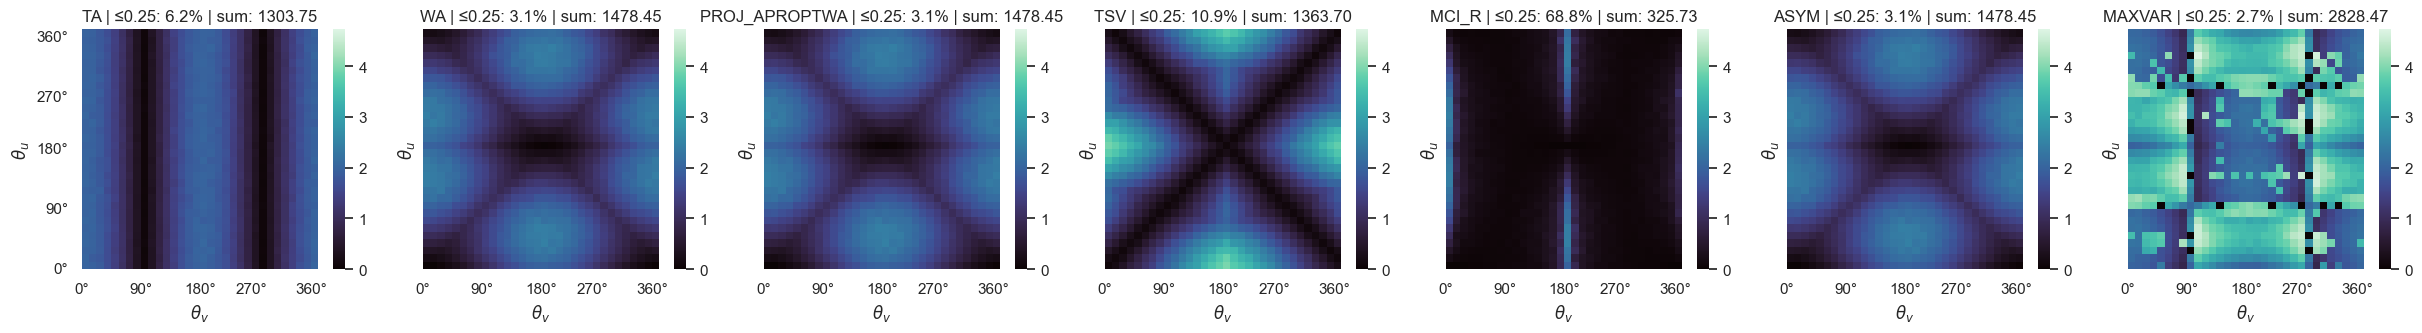

In [15]:
import matplotlib.pyplot as plt
import numpy as np

methods = ["ta", "wa", "proj_aproptwa", "tsv", "mci_r", "asym", "maxvar"]
thr = 0.25
n_steps = len(theta_range)

tick_degs = np.arange(0, 361, 90)
ticks = np.round(tick_degs / 360 * (n_steps - 1)).astype(int)
labels = [f"{d}°" for d in tick_degs]

# compute global color scale (same for all methods)
Zs = [
    df[(df.name == m) & (df.idx == 1)].error.values.reshape(n_steps, n_steps).T
    for m in methods
]
vmin = min(Z.min() for Z in Zs)
vmax = max(Z.max() for Z in Zs)

fig, axes = plt.subplots(
    1, len(methods),
    figsize=(3.5 * len(methods), 3.5),
    sharex=True, sharey=True
)

for ax, m, Z in zip(axes, methods, Zs):
    ok = Z < thr
    sns.heatmap(
        Z,
        cmap="mako",
        vmin=vmin, vmax=vmax,   # <-- shared scale
        cbar=True,
        ax=ax
    )

    pct = ok.mean() * 100
    ax.set(
        title=f"{m.upper()} | ≤{thr:.2f}: {pct:.1f}% | sum: {Z.sum():.2f}",
        xlabel=r"$\theta_v$", ylabel=r"$\theta_u$"
    )
    ax.invert_yaxis()
    ax.set(
        xticks=ticks, yticks=ticks,
        xticklabels=labels, yticklabels=labels
    )

plt.tight_layout()
plt.savefig(f"results/interference_heatmap_2d_s1{s1}_s2{s2}.pdf", dpi=600, bbox_inches="tight")
plt.show()


In [16]:
# WARNING: This takes a while to run
# Creates a dataframe for each (s1,s2) pair
from itertools import product
from tqdm import tqdm
import pandas as pd
import numpy as np

# s = np.arange(0.0, 2.0 + 1e-9, 0.2)
# s = [0.1, 0.25, 0.5, 1.0, 2.0]
# s = [(1.0, 0.1), (1.0, 0.5), (1.0, 1.0), (2.0, 2.0)]
ss = [(1.0, 0.001), (1.0, 0.2), (1.0, 0.4), (1.0, 0.6), (1.0, 0.8), (1.0, 1.0)]
data_type = 'disentangled'
dfs = []
# for s2, s1 in tqdm(product(s, s), total=len(s)**2, desc="make_interference_data"):
for s2, s1 in tqdm(ss, desc="make_interference_data"):
    d = make_interference_data(s1, s2, data_type=data_type).copy()   # expects cols: name, idx, error, (theta_u/theta_v or flattened)
    d["s1"] = s1
    d["s2"] = s2
    dfs.append(d)

df_big = pd.concat(dfs, ignore_index=True)

make_interference_data:   0%|          | 0/6 [00:00<?, ?it/s]/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_16498/276524046.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)


alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.S

make_interference_data:  17%|█▋        | 1/6 [00:01<00:08,  1.74s/it]

alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.S

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_16498/276524046.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)


...

alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.S

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_16498/276524046.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)


alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.S

make_interference_data: 100%|██████████| 6/6 [00:10<00:00,  1.77s/it]

alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.Size([2])
ws torch.Size([2, 2, 2])
alpha torch.S

In [86]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# methods = ["ta", "wa", "tsv", "isoc", "proj", "mci_r"]
# n = len(theta_range)

# # aggregate over idx
# d = (
#     df_big
#     .groupby(["name", "theta_v", "theta_u", "s1", "s2"], as_index=False)
#     .error.sum()
# )
# d = d[d.name.isin(methods)].copy()
# d["s1s2"] = list(zip(d.s1, d.s2))

# # vmin/vmax per s1s2 (shared across methods within that column)
# col_limits = d.groupby("s1s2")["error"].agg(["min", "max"]).to_dict("index")

# g = sns.FacetGrid(
#     d,
#     row="name",
#     col="s1s2",
#     row_order=methods,
#     sharex=True,
#     sharey=True,
#     height=2.0,
#     aspect=1
# )

# def hist_with_sum(data, **kws):
#     ax = plt.gca()
#     s1s2 = data["s1s2"].iloc[0]
#     vmin = col_limits[s1s2]["min"]
#     vmax = col_limits[s1s2]["max"]

#     show_cbar = ax is g.axes[0, list(g.col_names).index(s1s2)]  # top row per column

#     sns.histplot(
#         data,
#         x="theta_v", y="theta_u",
#         weights="error",
#         bins=(n, n),
#         # binrange=((0, 360), (0, 360)),
#         pthresh=0,
#         cmap="mako",
#         vmin=vmin, vmax=vmax,
#         cbar=show_cbar,
#         ax=ax
#     )
#     ax.invert_yaxis()

#     s = data["error"].sum()
#     ax.text(
#         0.98, 0.02, f"Σ={s:.2e}",
#         transform=ax.transAxes,
#         ha="right", va="bottom",
#         fontsize=10,
#         bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
#     )
#     ax.invert_yaxis()
#     # FORCE the limits to remove the 5% margin whitespace
#     ax.set_xlim(0, 360)
#     ax.set_ylim(360, 0) # Already inverted via set_ylim if you prefer

# g.map_dataframe(hist_with_sum)

# g.set_axis_labels(r"$\theta_v$", r"$\theta_u$")
# g.set_titles(col_template="s1={col_name[0]}, s2={col_name[1]}", row_template="{row_name}")

# # row labels (big, visible)
# for ax, name in zip(g.axes[:, 0], g.row_names):
#     ax.set_ylabel(
#         name.upper(),
#         rotation=0,
#         ha="right",
#         va="center",
#         labelpad=40,
#         fontsize=12,
#         fontweight="bold"
#     )

# # ---- per-column minima (among methods) ----
# facet_sums = d.groupby(["s1s2", "name"])["error"].sum()          # index: (s1s2, name)
# min_method_per_col = facet_sums.groupby(level=0).idxmin()       # one (s1s2,name) per column
# min_method_per_col = {s1s2: name for (s1s2, name) in min_method_per_col.values}

# # mark the winners and losers
# for r, name in enumerate(g.row_names):
#     for c, s1s2 in enumerate(g.col_names):
#         ax = g.axes[r, c]

#         # Winner marking
#         if min_method_per_col[s1s2] == name:
#             for sp in ax.spines.values():
#                 # sp.set_edgecolor("red")
#                 sp.set_linewidth(2.5)
#             ax.scatter([0.95], [0.95], transform=ax.transAxes, marker="*", s=200, c="gold")

#         # Loser marking
#         # Find the max error method for this s1s2 column
#         col_errors = facet_sums.loc[s1s2]
#         if name in col_errors.index:
#             max_method = col_errors.idxmax()
#             if name == max_method and len(col_errors) > 1:  # only mark if not a tie/only one
#                 for sp in ax.spines.values():
#                     # sp.set_edgecolor("blue")
#                     sp.set_linestyle((0, (3, 3)))  # dashed border for loser
#                 ax.scatter([0.05], [0.05], transform=ax.transAxes, marker="x", s=150, c="red", linewidths=3)

# plt.tight_layout()
# plt.savefig(f"results/interference_heatmap_2d_grid_dt{data_type}.pdf", dpi=600, bbox_inches="tight")
# plt.show()


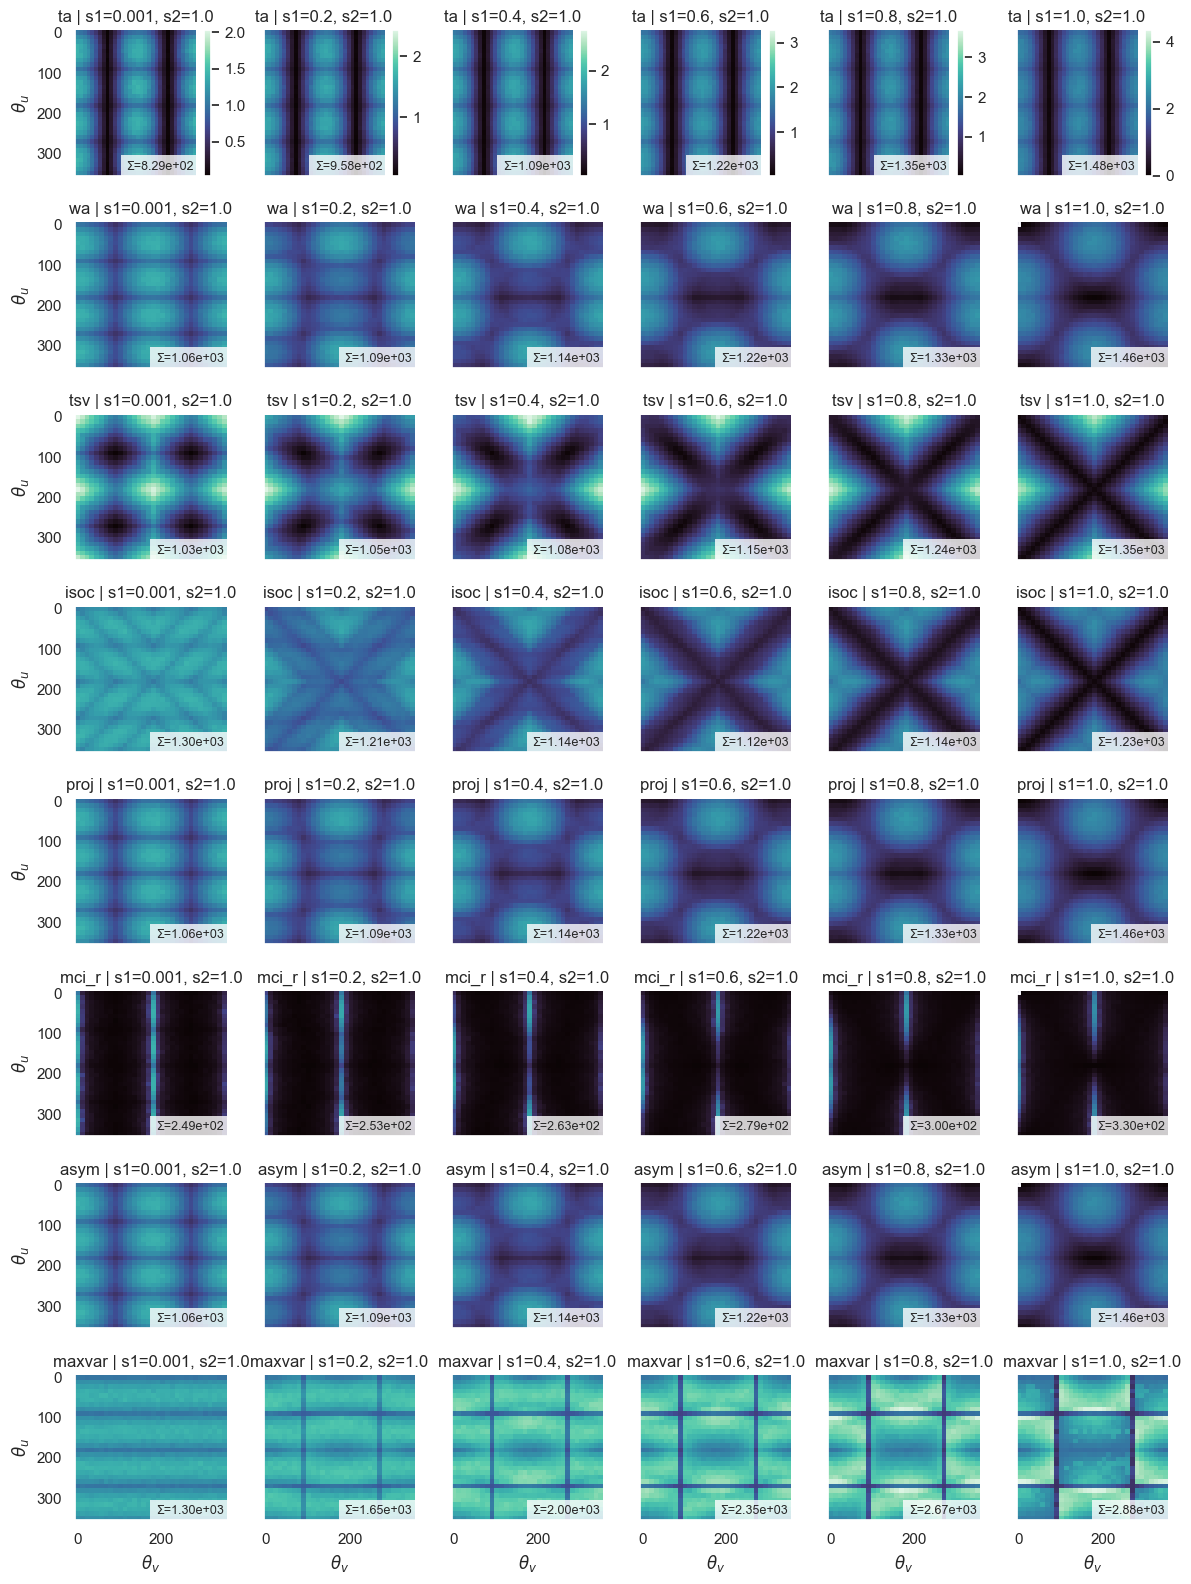

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

methods = ["ta", "wa", "tsv", "isoc", "proj", "mci_r", "asym", "maxvar"]

# --- aggregate ---
d = (
    df_big
    .groupby(["name", "theta_v", "theta_u", "s1", "s2"], as_index=False)["error"]
    .sum()
)
d = d[d["name"].isin(methods)].copy()
d["s1s2"] = list(zip(d["s1"], d["s2"]))

# --- snap to nearest theta grid (critical) ---
tv = np.sort(d["theta_v"].unique())
tu = np.sort(d["theta_u"].unique())
step_v = float(np.median(np.diff(tv)))
step_u = float(np.median(np.diff(tu)))

def snap(x, grid):
    x = np.asarray(x, float)
    return grid[np.argmin(np.abs(grid[None, :] - x[:, None]), axis=1)]

d["theta_v"] = snap(d["theta_v"].to_numpy(), tv)
d["theta_u"] = snap(d["theta_u"].to_numpy(), tu)

# --- bin edges aligned to grid centers (no shifting) ---
edges_v = np.r_[tv[0] - step_v/2, tv + step_v/2]
edges_u = np.r_[tu[0] - step_u/2, tu + step_u/2]

# shared vmin/vmax per s1s2 column
col_limits = d.groupby("s1s2")["error"].agg(["min", "max"]).to_dict("index")

g = sns.FacetGrid(
    d, row="name", col="s1s2",
    row_order=methods,
    sharex=True, sharey=True,
    height=2.0, aspect=1
)

def heat(data, **kws):
    ax = plt.gca()
    s1s2 = data["s1s2"].iloc[0]
    vmin, vmax = col_limits[s1s2]["min"], col_limits[s1s2]["max"]
    show_cbar = (ax.get_subplotspec().rowspan.start == 0)  # top row only

    sns.histplot(
        data=data,
        x="theta_v", y="theta_u",
        weights="error",
        bins=(edges_v, edges_u),     # <-- aligned edges
        cmap="mako",
        vmin=vmin, vmax=vmax,
        cbar=show_cbar,
        ax=ax
    )

    ax.set(xlim=(edges_v[0], edges_v[-1]), ylim=(edges_u[-1], edges_u[0]))  # flip y
    ax.text(0.98, 0.02, f"Σ={data['error'].sum():.2e}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

g.map_dataframe(heat)
g.set_axis_labels(r"$\theta_v$", r"$\theta_u$")
g.set_titles(col_template="s1={col_name[0]}, s2={col_name[1]}", row_template="{row_name}")
plt.savefig(f"results/interference_heatmap_2d_grid_dt{data_type}.pdf", dpi=600, bbox_inches="tight")

plt.tight_layout()
plt.show()


In [70]:
methods = ["ta", "wa", "tsv", "isoc", "mci_r", "proj"]

rank_tbl = (
    df_big
    .groupby(["name", "theta_v", "theta_u", "s1", "s2"])["error"].sum()
    .reset_index()
    .query("name in @methods")
    .assign(s1s2=lambda x: list(zip(x.s1, x.s2)))
    .groupby(["s1s2", "name"])["error"].sum()
    .groupby(level=0).rank(method="min")   # ranks within each s1s2
    .unstack()                             # cols = name, rows = s1s2
    .T                                     # rows = name, cols = s1s2  <-- key
    .reindex(methods)
)

summary = rank_tbl.assign(avg_rank=rank_tbl.mean(1)).sort_values("avg_rank")

# print(rank_tbl)
# print(summary)
# print(rank_tbl.to_latex(float_format="%.1f"))
print(summary[["avg_rank"]].to_latex(float_format="%.2f"))


\begin{tabular}{lr}
\toprule
s1s2 & avg_rank \\
name &  \\
\midrule
mci_r & 1.00 \\
tsv & 3.00 \\
ta & 3.50 \\
isoc & 3.83 \\
wa & 4.00 \\
proj & 5.67 \\
\bottomrule
\end{tabular}



In [114]:
import numpy as np

theta_v_vals = (
    df_big["theta_v"]
    .dropna()
    .sort_values()
    .unique()
)

print(theta_v_vals)


[  0.           5.625       11.25        16.875       22.5
  28.12500191  33.75        39.375       45.          50.62499619
  56.25000381  61.87500381  67.5         73.125       78.75
  84.37499237  90.          95.62500763 101.24999237 106.875
 112.50000763 118.125      123.75000763 129.375      135.
 140.625      146.25       151.875      157.5        163.12498474
 168.74998474 174.375      180.         185.625      191.25001526
 196.87501526 202.49998474 208.125      213.75       219.375
 225.00001526 230.62498474 236.25       241.875      247.50001526
 253.12498474 258.75       264.375      270.         275.62503052
 281.25       286.875      292.5        298.12496948 303.75
 309.375      315.         320.625      326.24996948 331.875
 337.49996948 343.125      348.75       354.37503052]


In [126]:
import numpy as np
import pandas as pd

methods = ["ta", "wa", "tsv", "isoc", "mci_r"]
theta_grid = np.arange(0, 360, 5.0).astype(float)

def snap_to_grid(x, grid=theta_grid):
    x = np.asarray(x, float)
    return grid[np.argmin(np.abs(x[:, None] - grid[None, :]), axis=1)]

# aggregate once + snap theta_v
d = (
    df_big
    .groupby(["name", "theta_v", "theta_u", "s1", "s2"], as_index=False)["error"]
    .sum()
)
d = d[d["name"].isin(methods)].copy()
d["theta_v"] = snap_to_grid(d["theta_v"].to_numpy(), theta_grid)

# score per (theta, method): sum over theta_u,s1,s2 (already summed over idx above)
score = (
    d.groupby(["theta_v", "name"], as_index=False)["error"].sum()
    .pivot(index="name", columns="theta_v", values="error")
    .reindex(methods)
)

# top-3 method names + their errors per theta
places = ["1st", "2nd", "3rd", "4th", "5th"]
n_places = len(places)
top_names = pd.DataFrame(index=places, columns=score.columns)
top_errs  = pd.DataFrame(index=places, columns=score.columns)

for th in score.columns:
    s = score[th].sort_values(kind="mergesort")
    top_names[th] = s.index[:n_places].tolist()
    top_errs[th]  = s.values[:n_places]

# pretty column labels
top_names.columns = [f"{t:g}°" for t in top_names.columns]
top_errs.columns  = top_names.columns

print(f"TOP-{n_places} methods (sorted by error):")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    print(top_names)
print(f"\nTOP-{n_places} errors (aligned with table above):")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    print(top_errs)

# print("\nLaTeX (names):\n")
# print(top_names.to_latex(index=True))
# print("\nLaTeX (errors):\n")
# print(top_errs.to_latex(index=True, float_format="%.3g"))


TOP-5 methods (sorted by error):
        0°     5°    10°    15°    20°    30°    35°    40°    45°    50°  \
1st     wa  mci_r  mci_r  mci_r  mci_r  mci_r  mci_r  mci_r  mci_r  mci_r   
2nd  mci_r   isoc   isoc   isoc   isoc   isoc   isoc    tsv    tsv    tsv   
3rd   isoc     wa     wa     wa    tsv    tsv    tsv   isoc   isoc   isoc   
4th    tsv    tsv    tsv    tsv     wa     wa     wa     wa     wa     ta   
5th     ta     ta     ta     ta     ta     ta     ta     ta     ta     wa   

       55°    60°    65°    75°    80°    85°    90°    95°   100°   105°  \
1st  mci_r  mci_r  mci_r  mci_r  mci_r  mci_r     ta  mci_r  mci_r  mci_r   
2nd    tsv     ta     ta     ta     ta     ta  mci_r     ta     ta     ta   
3rd     ta    tsv    tsv    tsv    tsv    tsv    tsv    tsv    tsv    tsv   
4th   isoc   isoc     wa     wa     wa     wa     wa     wa     wa     wa   
5th     wa     wa   isoc   isoc   isoc   isoc   isoc   isoc   isoc   isoc   

      115°   120°   125°   130°   135°   

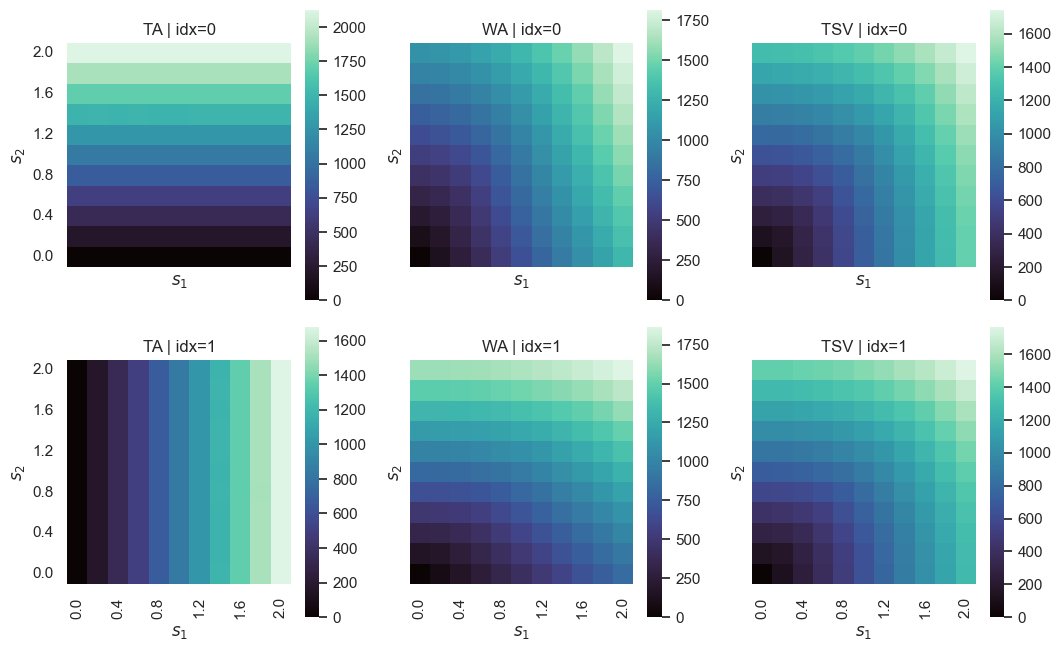

In [653]:
# Heatmaps for each index,method

methods = ["ta", "wa", "tsv"]
idxs = [0, 1]

s = np.sort(df_big["s1"].unique())
n = len(s)
ticks = np.arange(0, n, 2) + 0.5
labels = [f"{s[i]:.1f}" for i in range(0, n, 2)]

# aggregate once
df_sum = (
    df_big[df_big.idx.isin(idxs)]
    .groupby(["idx", "name", "s2", "s1"], sort=False)["error"]
    .sum()
    .reset_index(name="Zsum")
)

fig, axes = plt.subplots(
    len(idxs), len(methods),
    figsize=(3.6 * len(methods), 3.4 * len(idxs)),
    sharex=True, sharey=True
)

for r, idx in enumerate(idxs):
    for c, m in enumerate(methods):
        ax = axes[r, c]
        H = (
            df_sum[(df_sum.idx == idx) & (df_sum.name == m)]
            .pivot(index="s2", columns="s1", values="Zsum")
            .reindex(index=s, columns=s)
        )

        sns.heatmap(H, ax=ax, cmap="mako", square=True, cbar=True)

        ax.set_title(f"{m.upper()} | idx={idx}")
        ax.set_xlabel(r"$s_1$")
        ax.set_ylabel(r"$s_2$")
        ax.set(xticks=ticks, yticks=ticks, xticklabels=labels, yticklabels=labels)
        ax.invert_yaxis()

plt.tight_layout()
plt.show()


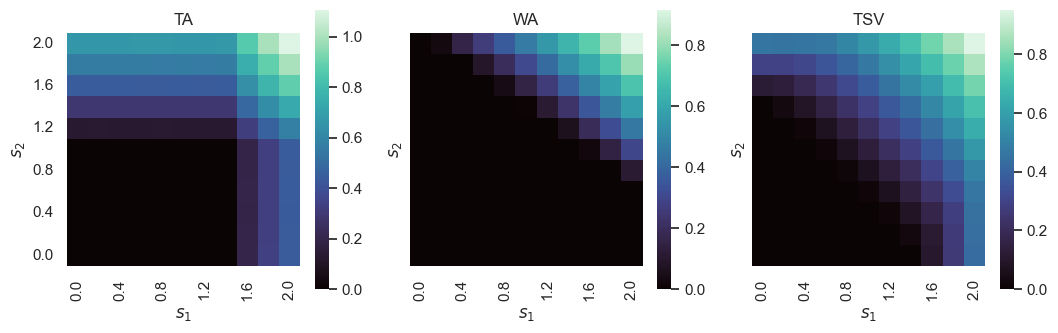

In [663]:
# Average over index, for each method

methods = ["ta", "wa", "tsv"]

s = np.sort(df_big["s1"].unique())
n = len(s)
ticks = np.arange(0, n, 2) + 0.5
labels = [f"{s[i]:.1f}" for i in range(0, n, 2)]

# 1) sum over theta-grid per idx
# df_sum = (
#     df_big
#     .groupby(["idx", "name", "s2", "s1"], sort=False)["error"]
#     .sum()
#     .reset_index(name="Zsum")
# )
thr = 1.5

df_sum = (
    df_big
    .assign(err_hi=lambda d: d.error.where(d.error > thr, 0.0))
    .groupby(["idx", "name", "s2", "s1"], sort=False)["err_hi"]
    .mean()
    .reset_index(name="Zsum")
)


# 2) average those sums across idx
df_avg = (
    df_sum
    .groupby(["name", "s2", "s1"], sort=False)["Zsum"]
    .mean()
    .reset_index(name="Zavg")
)

fig, axes = plt.subplots(
    1, len(methods),
    figsize=(3.6 * len(methods), 3.4),
    sharex=True, sharey=True
)

for ax, m in zip(axes, methods):
    H = (
        df_avg[df_avg.name == m]
        .pivot(index="s2", columns="s1", values="Zavg")
        .reindex(index=s, columns=s)
    )

    sns.heatmap(H, ax=ax, cmap="mako", square=True, cbar=True)

    ax.set(title=m.upper(), xlabel=r"$s_1$", ylabel=r"$s_2$")
    ax.set(xticks=ticks, yticks=ticks,
           xticklabels=labels, yticklabels=labels)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [139]:
# Compute Tr(E[ Wi @ xxT @ WjT])
theta_degs = 90
theta_rads = math.pi * theta_degs / 180
sigma_perturb, sigma_scale = 0.05, 0.1
d_task = 32
n_tasks = 8
x, v = create_datasets_and_task_vectors(n_tasks=n_tasks, d_task=d_task, sigma_perturb=sigma_perturb, sigma_scale=sigma_scale, n_samples=100)
u = torch.stack([torch.eye(d_task)[-1] for _ in range(n_tasks)], dim=0)
print(x.shape, v.shape, u.shape)

cov = torch.zeros(n_tasks, d_task, d_task)
# For each task, compute the covariance matrix
for k in range(n_tasks):
    xk = x[:, k]
    N = xk.shape[0]
    cov[k] = xk.T @ xk / (N - 1)

traces = torch.zeros(n_tasks, n_tasks, n_tasks)
for k in range(n_tasks):
    for i,j in itertools.product(range(n_tasks), range(n_tasks)):
        wi = torch.einsum('i,j->ij', u[i], v[i])
        wj = torch.einsum('i,j->ij', u[j], v[j])
        traces[k, i, j] = torch.trace(wi @ cov[k] @ wj.T)

print("Traces:", traces.shape)

torch.Size([100, 8, 32]) torch.Size([8, 32]) torch.Size([8, 32])
Traces: torch.Size([8, 8, 8])


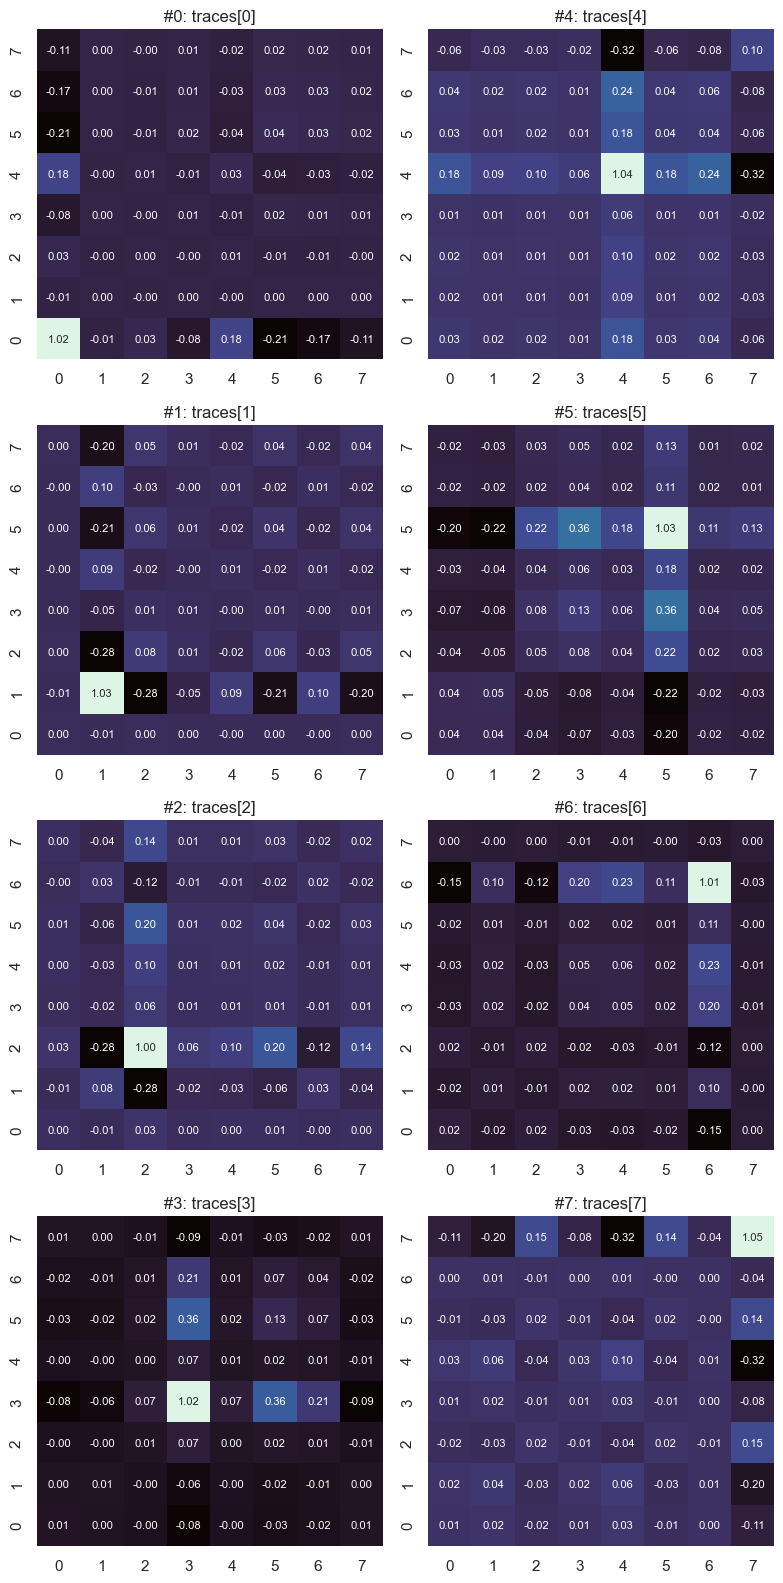

In [140]:
# Plot grid of heatmaps, looping over first dimension of traces
import seaborn as sns
import matplotlib.pyplot as plt

n_grid = traces.shape[0]
max_per_col = 4
ncols = (n_grid + max_per_col - 1) // max_per_col
nrows = min(max_per_col, n_grid)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

for idx in range(n_grid):
    row = idx % max_per_col
    col = idx // max_per_col
    ax = axes[row, col]
    sns.heatmap(traces[idx], cmap="mako", ax=ax, annot=True, fmt=".2f", cbar=False, annot_kws={"size": 8})
    ax.set_title(f"#{idx}: traces[{idx}]")
    ax.invert_yaxis()

# Hide empty subplots, if any
for col in range(ncols):
    for row in range(nrows):
        panel_idx = col * max_per_col + row
        if panel_idx >= n_grid:
            axes[row, col].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import random
import torch
import math
# Subspace distances

# # set seed
# random.seed(42)
# torch.manual_seed(42)

def subspace_dist(a, b):
    """Computes the subspace distance between two subspaces."""
    ua, _, _ = torch.linalg.svd(a, full_matrices=False)
    ub, _, _ = torch.linalg.svd(b, full_matrices=False)
    return torch.linalg.norm(ua @ ua.T - ub @ ub.T, ord='fro').item() **2  / 2


n_tasks, max_reps, n_dim = 33, 2, 32
reps = [max_reps for _ in range(n_tasks)] # number of reps for each task
us, vs = torch.eye(n_tasks, n_dim), torch.randn(n_tasks, n_dim)
us, vs = us/torch.linalg.norm(us, dim=1, keepdim=True), vs/torch.linalg.norm(vs, dim=1, keepdim=True)
sigmas = torch.randn(n_tasks)
us_reps = [torch.stack([us[i]]*reps[i], dim=0) for i in range(n_tasks)]
vs_reps = [torch.stack([vs[i]]*reps[i], dim=0) for i in range(n_tasks)]
sigmas_reps = [torch.stack([sigmas[i]]*reps[i], dim=0) for i in range(n_tasks)]

# flatten
us_reps = torch.cat(us_reps, dim=0)
vs_reps = torch.cat(vs_reps, dim=0)
sigmas_reps = torch.cat(sigmas_reps, dim=0)

print("Shape of us:", us.shape)
print("Shape of us_reps:", us_reps.shape)

# orthogonalize
eps = 1e-1
us_orth = compute_procrustes(us_reps.T + eps * torch.randn_like(us_reps.T)).T  # (n_tasks*max_reps, n_dim)
vs_orth = compute_procrustes(vs_reps.T + eps * torch.randn_like(vs_reps.T)).T

print("Shape of us_orth:", us_orth.shape)

# add sigmas
T, Tp = us.shape[0], us_reps.shape[0]
# S, Sp = torch.eye(T, T), torch.eye(Tp, Tp)
S, Sp = torch.diag(sigmas), torch.diag(sigmas_reps)

w_targ = us.T @ S @ vs
w_ta = us_reps.T @ Sp @ vs_reps
w_tsv = us_orth.T @ Sp @ vs_orth

for c_mat_name, w in zip(['targ', 'ta', 'tsv'], [w_targ, w_ta, w_tsv]):
    print(f"{c_mat_name}: {subspace_dist(w, w_targ)}")





Shape of us: torch.Size([33, 32])
Shape of us_reps: torch.Size([66, 32])
** On entry to SLASCL, parameter number  4 had an illegal value
** On entry to SLASCL, parameter number  4 had an illegal value
** On entry to SLASCL, parameter number  5 had an illegal value


_LinAlgError: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 14).

In [ ]:
n_tasks, reps, n_dim = 3, 8, 32
us = torch.eye(n_tasks, n_dim)
us_reps = [torch.stack([us[i]]*reps, dim=0) for i in range(n_tasks)]
us_reps = torch.cat(us_reps, dim=0)
us_orth = compute_procrustes(us_reps.T).T  # (n_tasks*max_reps, n_dim)

projs = []
for i in range(n_tasks):
    projs.append((us_reps[i].T @ us_orth[i]).item())

print(projs)
print(1/math.sqrt(reps))



[0.4472135901451111, 0.4472135305404663, 0.4472135901451111, 0.4472135901451111]
0.4472135954999579


In [ ]:
# compute_procrustes(us_reps.T).T 
P, _, Q = torch.linalg.svd(us_reps.T, full_matrices=False)

eps = 1e-8 * A.norm().clamp_min(1e-12)
A2 = A + eps * torch.randn_like(A)
U, S, Vh = torch.linalg.svd(A2.double().cpu(), full_matrices=False)

** On entry to SLASCL, parameter number  4 had an illegal value
** On entry to SLASCL, parameter number  4 had an illegal value
** On entry to SLASCL, parameter number  5 had an illegal value


_LinAlgError: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 14).

### ISO-C Sigma Sensitivity

TSV Error: 3.08 +/- 1.97
ISO Error: 3.45 +/- 0.97


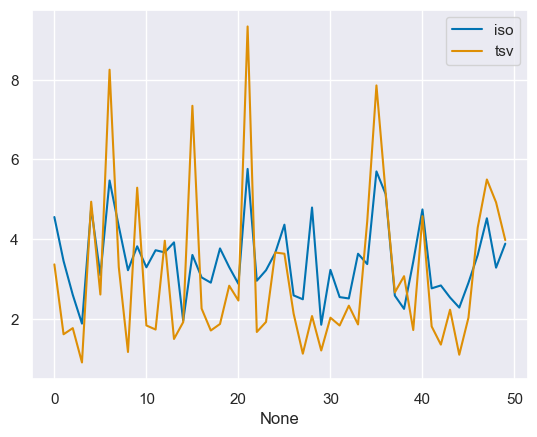

In [168]:
D = 32
n_reps = 10
n_ext = 10
sigmas_list = [[1.0, 1.0], [1.0, 0.5], [1.0, 0.25], [1.0, 0.1], [1.0, 0.05], [1.0, 0.01], [1.0, 0.005], [1.0, 0.001]]
sigmas_list = [torch.tensor(t) for t in sigmas_list]
diffs_iso = []
diffs_tsv = []
for i in range(50):
    u1, U2 = torch.randn(D), torch.randn(D, n_ext)
    v1, V2 = torch.randn(D), torch.randn(D, n_ext)

    # Normalize
    u1, U2 = u1 / u1.norm(), U2 / torch.linalg.norm(U2, dim=0, keepdim=True)
    v1, V2 = v1 / v1.norm(), V2 / torch.linalg.norm(V2, dim=0, keepdim=True)
    u_stk = torch.cat([u1.unsqueeze(1), U2], dim=1) # (D, T)
    v_stk = torch.cat([v1.unsqueeze(1), V2], dim=1) # (D, T)

    u_stk_reps = torch.cat([torch.stack([u1]*n_reps, dim=1), U2], dim=1)
    v_stk_reps = torch.cat([torch.stack([v1]*n_reps, dim=1), V2], dim=1)
    sigmas = torch.randn(1 + n_ext)
    # sigmas = torch.ones(1 + n_ext)
    sigmas_reps = torch.cat([torch.tensor([sigmas[0]]*n_reps), sigmas[1:]], dim=0)
    

    # Compute target
    w_targ = torch.einsum('ik,k,kj->ij', u_stk, sigmas, v_stk.T)

    # Compute tsv
    u_orth = compute_procrustes(u_stk_reps.T).T
    v_orth = compute_procrustes(v_stk_reps.T).T
    w_tsv = torch.einsum('ik,k,kj->ij', u_orth, sigmas_reps, v_orth.T)

    # Compute iso
    w_iso = torch.einsum('ik,kj->ij', u_stk, v_stk.T) * sigmas_reps.mean()

    # print(w_targ.shape, w_tsv.shape, w_iso.shape)
    diff_iso = torch.linalg.norm(w_iso - w_targ, ord='fro')
    diff_tsv = torch.linalg.norm(w_tsv - w_targ, ord='fro')
    # print(diff_iso, diff_tsv)
    diffs_iso.append(diff_iso.item())
    diffs_tsv.append(diff_tsv.item())


sns.lineplot(y=diffs_iso, label='iso', x=torch.arange(len(diffs_iso)))
sns.lineplot(y=diffs_tsv, label='tsv', x=torch.arange(len(diffs_tsv)))

# Print mean and std of diffs_iso and diffs_tsv
print(f"TSV Error: {torch.tensor(diffs_tsv).mean():.2f} +/- {torch.tensor(diffs_tsv).std():.2f}")
print(f"ISO Error: {torch.tensor(diffs_iso).mean():.2f} +/- {torch.tensor(diffs_iso).std():.2f}")



### Sensor fusion inspired method

In [ ]:
import torch
import numpy as np

# set seed
torch.manual_seed(42)
np.random.seed(42)

def estimate_ws(W_tilde):
    N, Do, Di = W_tilde.shape
    # Now we compute Pu and Pv
    u_tilde, _, vt_tilde = torch.linalg.svd(W_tilde, full_matrices=False)
    Ru, Rv = u_tilde.size(2) // N, vt_tilde.size(1) // N

    # (B, Do, Ru') => (B, Do, Ru) => (Do, B, Ru) => (Do, B*Ru)
    u_stk = u_tilde[:, :, :Ru].permute(1, 0, 2).reshape(Do, -1)
    # (B, Rv', Di) => (B, Rv, Di) => (B, Rv, Di) => (B*Rv, Di)
    vt_stk = vt_tilde[:, :Rv].reshape(-1, Di) 
    u_perp = compute_procrustes(u_stk).T  # (Do, N*Do)
    v_perp = compute_procrustes(vt_stk.T) # (Di, N*Di)

    Pu = u_perp @ u_perp.T
    Pv = v_perp @ v_perp.T

    # print("Pu shape:", Pu.shape)
    # print("Pv shape:", Pv.shape)

    # Now project
    W_hat = torch.einsum('ij,bjk,kl->bil', Pu, W_prime, Pv)
    # print("W_hat shape:", W_hat.shape)
    return W_hat

def merge_sf(W_tilde):
    # First estimate true W
    W_hat = estimate_ws(W_tilde)
    # Then merge
    return W_hat.mean(dim=0)


# EXAMPLE::

# Setup problem
Di, Do = 48, 32
N = 8
sigma = 0.01

## Create true W
W_prime = torch.randn(N, Do, Di)
Uk, Sk, Vtk = torch.linalg.svd(W_prime, full_matrices=False)
Vt = Vtk[0]  # (N, D) shared basis
U = Uk[0]

## Create noisy W
e = torch.randn(N) * sigma
W_tilde = e.reshape(-1, 1, 1) + torch.einsum('ik,bk,kj->bij', U, Sk, Vt)  # (N, Do, Di)

## Estimate W
W_hat = estimate_ws(W_tilde)
print("W_hat shape:", W_hat.shape)

## Merge
W_hat_merged = merge_sf(W_tilde)
print("W_hat_merged shape:", W_hat_merged.shape)



W_hat shape: torch.Size([8, 32, 48])
W_hat_merged shape: torch.Size([32, 48])


In [220]:
from torch.distributions import MultivariateNormal

def sample_from_gaussian(mean, cov, n=1, jitter=1e-6):
    D = mean.numel()
    cov = cov + jitter * torch.eye(D, device=cov.device, dtype=cov.dtype)
    m = MultivariateNormal(mean, covariance_matrix=cov)
    return m.sample((n,)).squeeze(0) if n == 1 else m.sample((n,))

def create_sensing_problem(N, Do, Di, sigma, n=100):
    ## Create true W
    W_prime = torch.randn(N, Do, Di)
    Uk, Sk, Vtk = torch.linalg.svd(W_prime, full_matrices=False)
    Vt = Vtk[0]  # (N, D) shared basis
    U = Uk[0]

    ## Create noisy W
    e = torch.randn(N) * sigma
    W_true = torch.einsum('ik,bk,kj->bij', U, Sk, Vt)
    W_tilde = e.reshape(-1, 1, 1) + W_true  # (N, Do, Di)

    ## Create dataset with covariance VLVt
    A = torch.randn(Vt.size(0), Vt.size(0))
    L, _ = torch.linalg.eigh(A)
    C = torch.einsum('ik,k,kl->il', Vt.T, L.abs(), Vt)

    ## sample from gaussian with unit mean and covariance C
    X = sample_from_gaussian(torch.zeros(Vt.size(1)), C, n)
    return X, W_tilde, W_true

In [226]:
X, W_tilde, W_true = create_sensing_problem(N, Do, Di, sigma)
# print("X shape:", X.shape)
# print("W_tilde shape:", W_tilde.shape)


# Compute interference for diff methods:
W_mean = W_tilde.mean(dim=0)
W_ta = W_tilde.sum(dim=0) / N
W_sf = merge_sf(W_tilde)

print("W_mean shape:", W_mean.shape)
print("W_ta shape:", W_ta.shape)
print("W_sf shape:", W_sf.shape)

# Compute interference for diff methods:
for m_name, m_mat in zip(['mean', 'ta', 'sf'], [W_mean, W_ta, W_sf]):
    print(f"Interference for {m_name}: {interference_mats(W_true, m_mat, X)}")


W_mean shape: torch.Size([32, 48])
W_ta shape: torch.Size([32, 48])
W_sf shape: torch.Size([32, 48])
Interference for mean: 1.3149696588516235
Interference for ta: 1.3149696588516235
Interference for sf: 36.53004837036133


## Real Data

### Helpers

In [2]:
# Running covariance computation

import numpy as np


class OnlineCovariance:
    """
    A class to calculate the mean and the covariance matrix
    of the incrementally added, n-dimensional data.
    """

    def __init__(self, order):
        """
        Parameters
        ----------
        order: int, The order (=="number of features") of the incrementally added
        dataset and of the resulting covariance matrix.
        """
        self._order = order
        self._shape = (order, order)
        self._identity = np.identity(order)
        self._ones = np.ones(order)
        self._count = 0
        self._mean = np.zeros(order)
        self._cov = np.zeros(self._shape)

    @property
    def count(self):
        """
        int, The number of observations that has been added
        to this instance of OnlineCovariance.
        """
        return self._count

    @property
    def mean(self):
        """
        double, The mean of the added data.
        """
        return self._mean

    @property
    def cov(self):
        """
        array_like, The covariance matrix of the added data.
        """
        return self._cov

    @property
    def corrcoef(self):
        """
        array_like, The normalized covariance matrix of the added data.
        Consists of the Pearson Correlation Coefficients of the data's features.
        """
        if self._count < 1:
            return None
        variances = np.diagonal(self._cov)
        denomiator = np.sqrt(variances[np.newaxis, :] * variances[:, np.newaxis])
        return self._cov / denomiator

    def add(self, observation):
        """
        Add the given observation to this object.

        Parameters
        ----------
        observation: array_like, The observation to add.
        """
        if self._order != len(observation):
            raise ValueError(f"Observation to add must be of size {self._order}")

        self._count += 1
        delta_at_nMin1 = np.array(observation - self._mean)
        self._mean += delta_at_nMin1 / self._count
        weighted_delta_at_n = np.array(observation - self._mean) / self._count
        shp = (self._order, self._order)
        D_at_n = np.broadcast_to(weighted_delta_at_n, self._shape).T
        D = (delta_at_nMin1 * self._identity).dot(D_at_n.T)
        self._cov = self._cov * (self._count - 1) / self._count + D

    def merge(self, other):
        """
        Merges the current object and the given other object into a new OnlineCovariance object.

        Parameters
        ----------
        other: OnlineCovariance, The other OnlineCovariance to merge this object with.

        Returns
        -------
        OnlineCovariance
        """
        if other._order != self._order:
            raise ValueError(
                f"""
                   Cannot merge two OnlineCovariances with different orders.
                   ({self._order} != {other._order})
                   """
            )

        merged_cov = OnlineCovariance(self._order)
        merged_cov._count = self.count + other.count
        count_corr = (other.count * self.count) / merged_cov._count
        merged_cov._mean = (
            self.mean / other.count + other.mean / self.count
        ) * count_corr
        flat_mean_diff = self._mean - other._mean
        shp = (self._order, self._order)
        mean_diffs = np.broadcast_to(flat_mean_diff, self._shape).T
        merged_cov._cov = (
            self._cov * self.count
            + other._cov * other._count
            + mean_diffs * mean_diffs.T * count_corr
        ) / merged_cov.count
        return merged_cov



In [3]:
# Test OnlineCovariance
# Same calculations with OnlineCovariance
D = 4
ocov = OnlineCovariance(D)
for _ in range(100):
    x = torch.randn(D)
    ocov.add(x.numpy())

print("Covariance matrix:\n", np.round(ocov.cov, 2))
print("Mean:\n", np.round(ocov.mean, 2))

Covariance matrix:
 [[ 0.82 -0.09  0.06  0.08]
 [-0.09  0.95  0.05 -0.09]
 [ 0.06  0.05  0.91  0.21]
 [ 0.08 -0.09  0.21  1.32]]
Mean:
 [-0.09 -0.06 -0.03  0.07]


### Save layer-wise covariance

In [4]:
# Load model for Cars
import torch
import certifi
import os
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ["OPENCLIP_CACHEDIR"] = os.environ["SCRATCH"] + "/openclip"

from src.datasets.registry import get_dataset
from src.datasets.common import get_dataloader_v2, maybe_dictionarize
from src.models.modeling import ImageClassifier, ImageEncoder
from src.models.heads import build_classification_head
from src.datasets.templates import get_templates


# dataset_name = "CIFAR10"
# batch_size = 32
# template = get_templates(dataset_name)
# data_location = "datasets"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_name = "ViT-B-16"

# # Build model
# image_encoder = ImageEncoder(model_name, keep_lang=True)

# classification_head = build_classification_head(image_encoder.model, dataset_name, template, data_location, device)
# model = ImageClassifier(image_encoder, classification_head)

# batch_size = 1
# dataset = get_dataset(
#     dataset_name,
#     model.val_preprocess,
#     location=data_location,
#     batch_size=batch_size,
# )
# dataloader = get_dataloader_v2(dataset, is_train=False, image_encoder=None, batch_size=batch_size, device=device)

/home/mila/m/marawan.gamal/scratch/tsv/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# dataset_name = "CIFAR10"
dataset_name = "Cars"
batch_size = 32
template = get_templates(dataset_name)
data_location = "datasets"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "ViT-B-16"

# Build model
image_encoder = ImageEncoder(model_name, keep_lang=True)
classification_head = build_classification_head(image_encoder.model, dataset_name, template, data_location, device)
model = ImageClassifier(image_encoder, classification_head)

dataset = get_dataset(
    dataset_name,
    model.val_preprocess,
    location=data_location,
    batch_size=batch_size,
)
dataloader = get_dataloader_v2(dataset, is_train=False, image_encoder=None, batch_size=batch_size, device=device)

/home/mila/m/marawan.gamal/scratch/tsv/.venv/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Devkit exists: datasets/stanford_cars/devkit
Devkit exists: datasets/stanford_cars/devkit
Devkit exists: datasets/stanford_cars/devkit
Devkit exists: datasets/stanford_cars/devkit
Building classification head.


100%|██████████| 196/196 [00:01<00:00, 114.87it/s]


zeroshot shape, Ptorch.Size([196, 512])
Devkit exists: datasets/stanford_cars/devkit
Devkit exists: datasets/stanford_cars/devkit
Devkit exists: datasets/stanford_cars/devkit
Devkit exists: datasets/stanford_cars/devkit


In [6]:
# Get finetuned params
from src.models.task_vectors import NonLinearTaskVector

def add_tv_to_model(model, tv):
    new_dict = {}
    skipped = []
    added = []
    pt_dict = model.state_dict()
    tv_dict = tv.vector
    for k in pt_dict.keys():
        if k in tv_dict:
            new_dict[k] = pt_dict[k].to(device) + tv_dict[k].to(device)
            added.append(k)
        else:
            skipped.append(k)
            new_dict[k] = pt_dict[k]
    return new_dict, added, skipped



MODELS_ROOT = os.path.expanduser("models/checkpoints")

# Calculate task vectors
pretrained_checkpoint = f"{MODELS_ROOT}/{model_name}/MNISTVal/nonlinear_zeroshot.pt"
finetuned_checkpoint = f"{MODELS_ROOT}/{model_name}/{dataset_name}Val/nonlinear_finetuned.pt"
tv = NonLinearTaskVector(model_name, pretrained_checkpoint, finetuned_checkpoint)

# Load tv into model
new_dict, added, skipped = add_tv_to_model(model.image_encoder, tv)
model.image_encoder.load_state_dict(new_dict)
print("Added layers:", added)
print("Skipped layers:", skipped)


Loading image encoder from models/checkpoints/ViT-B-16/MNISTVal/nonlinear_zeroshot.pt
Loading image encoder from models/checkpoints/ViT-B-16/CarsVal/nonlinear_finetuned.pt
Added layers: ['model.positional_embedding', 'model.text_projection', 'model.logit_scale', 'model.visual.class_embedding', 'model.visual.positional_embedding', 'model.visual.proj', 'model.visual.conv1.weight', 'model.visual.ln_pre.weight', 'model.visual.ln_pre.bias', 'model.visual.transformer.resblocks.0.ln_1.weight', 'model.visual.transformer.resblocks.0.ln_1.bias', 'model.visual.transformer.resblocks.0.attn.in_proj_weight', 'model.visual.transformer.resblocks.0.attn.in_proj_bias', 'model.visual.transformer.resblocks.0.attn.out_proj.weight', 'model.visual.transformer.resblocks.0.attn.out_proj.bias', 'model.visual.transformer.resblocks.0.ln_2.weight', 'model.visual.transformer.resblocks.0.ln_2.bias', 'model.visual.transformer.resblocks.0.mlp.c_fc.weight', 'model.visual.transformer.resblocks.0.mlp.c_fc.bias', 'model.v

In [5]:
dataloader = get_dataloader_v2(dataset, is_train=False, image_encoder=None, batch_size=1, device=device)

In [7]:
# Need to save mats (T, Do, Di) and acts (T, N, Do)
# Pass single batch and measure mean and std of all activations
data = maybe_dictionarize(next(iter(dataloader)))
x = data['images']
model.to(device)
x = x.to(device)
out = model(x)
print("Output shape:", out.shape)
print("Device:", out.device)
# >>> out.shape
# torch.Size([32, 1000])

Output shape: torch.Size([32, 196])
Device: cuda:0


In [23]:
for name, param in model.named_parameters():
    print(name)

model.image_encoder.model.visual.transformer.resblocks[1].attn

image_encoder.model.positional_embedding
image_encoder.model.text_projection
image_encoder.model.logit_scale
image_encoder.model.visual.class_embedding
image_encoder.model.visual.positional_embedding
image_encoder.model.visual.proj
image_encoder.model.visual.conv1.weight
image_encoder.model.visual.ln_pre.weight
image_encoder.model.visual.ln_pre.bias
image_encoder.model.visual.transformer.resblocks.0.ln_1.weight
image_encoder.model.visual.transformer.resblocks.0.ln_1.bias
image_encoder.model.visual.transformer.resblocks.0.attn.in_proj_weight
image_encoder.model.visual.transformer.resblocks.0.attn.in_proj_bias
image_encoder.model.visual.transformer.resblocks.0.attn.out_proj.weight
image_encoder.model.visual.transformer.resblocks.0.attn.out_proj.bias
image_encoder.model.visual.transformer.resblocks.0.ln_2.weight
image_encoder.model.visual.transformer.resblocks.0.ln_2.bias
image_encoder.model.visual.transformer.resblocks.0.mlp.c_fc.weight
image_encoder.model.visual.transformer.resblocks.0.

MultiheadAttention(
  (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
)

In [ ]:
import torch
import itertools

# Compute running covariance of activations
stats = {}  # layer_name -> hook_result
handles = []  # references to hooks
MAX_HOOKS = 50
MAX_BATCHES = 20

def compute_stats(inp, out):
    # Compute stat given input, output of the layer
    return x.mean().item(), x.std(unbiased=False).item(), tuple(x.shape)

def hook(name):
    # Hook gets (module, input, output)
    def h(mod, _inp, out):
        # print("out.shape", out.shape)
        inp = _inp[0]
        if torch.is_tensor(inp):
            print("inp.shape", inp.shape)
            B, T, D = inp.shape
            if name not in stats:
                ocov = OnlineCovariance(D)
                stats[name] = ocov
            ocov = stats[name]
            for i in range(B):
                j = torch.randint(0, T, (1,)).item()
                v = inp[i, j].cpu().detach().numpy()
                # normalize v
                # v = v / np.linalg.norm(v)
                ocov.add(v)
            stats[name] = ocov
    return h

num_registered = 0
for i, (c_mat_name, m) in enumerate(model.named_modules()):
    if isinstance(m, torch.nn.Linear) or isinstance(m, torch.nn.MultiheadAttention):
        print("Registering hook for", c_mat_name)
        h = m.register_forward_hook(hook(c_mat_name))
        handles.append(h)
        if num_registered > MAX_HOOKS:
            break
        num_registered += 1

model.to(device)
with torch.no_grad():
    for i, batch in enumerate(dataloader):
        print("Processing batch", i)
        x = maybe_dictionarize(batch)["images"]
        model(x.to(device))
        if i > MAX_BATCHES:
            break

Registering hook for image_encoder.model.visual.transformer.resblocks.0.attn
Registering hook for image_encoder.model.visual.transformer.resblocks.0.attn.out_proj
Registering hook for image_encoder.model.visual.transformer.resblocks.0.mlp.c_fc
Registering hook for image_encoder.model.visual.transformer.resblocks.0.mlp.c_proj
Registering hook for image_encoder.model.visual.transformer.resblocks.1.attn
Registering hook for image_encoder.model.visual.transformer.resblocks.1.attn.out_proj
Registering hook for image_encoder.model.visual.transformer.resblocks.1.mlp.c_fc
Registering hook for image_encoder.model.visual.transformer.resblocks.1.mlp.c_proj
Registering hook for image_encoder.model.visual.transformer.resblocks.2.attn
Registering hook for image_encoder.model.visual.transformer.resblocks.2.attn.out_proj
Registering hook for image_encoder.model.visual.transformer.resblocks.2.mlp.c_fc
Registering hook for image_encoder.model.visual.transformer.resblocks.2.mlp.c_proj
Registering hook fo

In [ ]:
# Unregister hooks from model
for h in handles:
    h.remove()

In [ ]:
# covs_Cars:
# {'model.resblock.0.c_proj.weight: Covariance Tensor, ....}
# mats:
# {"cars": {'model.resblock.0.c_proj.weight: Layer Tensor, ....}, "mnist": {...}}

import pickle

results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

covs = {}
means = {}
for s in stats:
    c = stats[s].cov
    m = stats[s].mean
    print(s, c.shape)
    covs[s] = c

to_save = {
    "model": model_name,
    "dataset": dataset_name,
    "covs": covs,
    "means": means,
}

with open(os.path.join(results_dir, f"covs_{dataset_name}.pkl"), "wb") as f:
    pickle.dump(to_save, f)


### Save layer-wise mats

In [ ]:
import os
import json
from typing import List
import numpy as np
import torch

os.environ["OPENCLIP_CACHEDIR"] = os.environ["SCRATCH"] + "/openclip"


import matplotlib.pyplot as plt
from src.models.task_vectors import NonLinearTaskVector


MODELS_ROOT = os.path.expanduser("models/checkpoints")
# datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
model = "ViT-B-16"
device = "cuda:0"

# Calculate task vectors
task_vectors = []
pretrained_checkpoint = f"{MODELS_ROOT}/{model}/MNISTVal/nonlinear_zeroshot.pt"
for dataset in datasets:
    finetuned_checkpoint = f"{MODELS_ROOT}/{model}/{dataset}Val/nonlinear_finetuned.pt"
    task_vectors.append(
        NonLinearTaskVector(model, pretrained_checkpoint, finetuned_checkpoint)
    )


    # if len(task_vectors[0].vector[layer_name].shape) == 2 and "text_projection" not in layer_name:
    #     if task_vectors[0].vector[layer_name].min() == task_vectors[0].vector[layer_name].max() == 0:
    #         continue

# mats = torch.stack(mats)

In [ ]:
# Pull out single matrix
mats = {}
for layer_name in task_vectors[0].vector:
    for tv in task_vectors:
        if layer_name not in mats:
            mats[layer_name] = []
        mats[layer_name].append(tv.vector[layer_name])

# Now stack
for layer_name in mats:
    mats[layer_name] = torch.stack(mats[layer_name])


In [ ]:
# keys = list(set(k.split(".npy")[0].replace("cov_", "") for k in os.listdir(covs_dir)))
# keys = sorted(keys)
# keys
# # Save as a dict using pickle

In [ ]:
# # Build a dict of mats
# mats = {}
# for layer_name in keys:
#      for tv in task_vectors:
#           k = layer_name + ".weight"
#           print("adding", k)
#           # mats[](tv.vector[k])
#           if not k in mats:
#                mats[k] = []
#           mats[k].append(tv.vector[k])

# for k in mats:
#      mats[k] = torch.stack(mats[k])

In [ ]:
# Save as a dict using pickle
import pickle
import os.path as osp
mats_dir = "results"
os.makedirs(mats_dir, exist_ok=True)
save_dict = {
    "datasets": datasets,
    "weights": {k: v.numpy() for k, v in mats.items()}
}
with open(osp.join(mats_dir, f"mats.pkl"), "wb") as f:
    pickle.dump(save_dict, f)

In [ ]:
# Load as a dict
import pickle
import os.path as osp
mats_dir = "results/mats"
with open(osp.join(mats_dir, f"mats.pkl"), "rb") as f:
    mats_dict = pickle.load(f)
mats_dict['weights'].keys()


### Analyze covariance matrices

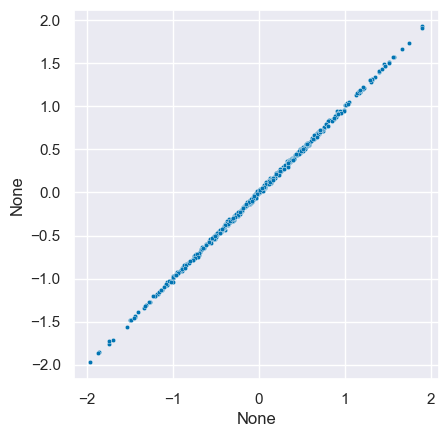

tensor([[0.4895, 0.4894],
        [0.4894, 0.4895]])


In [2]:
import torch, seaborn as sns, matplotlib.pyplot as plt

n = 500          # number of samples
signal_std = 1.0 # variance along (1,1)
noise_std  = 0.01 # variance orthogonal to (1,1)

v = torch.tensor([1., 1.]) / 2**0.5
v_perp = torch.tensor([1., -1.]) / 2**0.5

t = signal_std * torch.randn(n, 1)
e = noise_std  * torch.randn(n, 1)

X = t @ v[None, :] + e @ v_perp[None, :]

sns.scatterplot(x=X[:,0], y=X[:,1], s=10)
plt.gca().set_aspect("equal")
plt.show()

# Compute covariance matrix
C = X.T @ X / n
print(C)


In [3]:
import pickle
import os
import os.path as osp
import torch
results_dir = "results"


# 1. Load layer covariances for each task
# task_list = ['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'MNIST', 'SVHN']
task_list = ['Cars']
covs_filenames = ["covs_" + t +".pkl" for t in task_list]
for filename in covs_filenames:
    with open(osp.join(results_dir, filename), "rb") as f:
        covs_dict_i = pickle.load(f)
        covs = covs_dict_i['covs']
        dataset_name = covs_dict_i['dataset']

for c_layer, c_mat in covs.items():
    print(c_layer, c_mat.shape)
    # >>> image_encoder.model.visual.transformer.resblocks.0.mlp.c_fc (768, 768)


image_encoder.model.visual.transformer.resblocks.0.mlp.c_fc (768, 768)
image_encoder.model.visual.transformer.resblocks.0.mlp.c_proj (3072, 3072)
image_encoder.model.visual.transformer.resblocks.1.mlp.c_fc (768, 768)
image_encoder.model.visual.transformer.resblocks.1.mlp.c_proj (3072, 3072)
image_encoder.model.visual.transformer.resblocks.2.mlp.c_fc (768, 768)
image_encoder.model.visual.transformer.resblocks.2.mlp.c_proj (3072, 3072)
image_encoder.model.visual.transformer.resblocks.3.mlp.c_fc (768, 768)
image_encoder.model.visual.transformer.resblocks.3.mlp.c_proj (3072, 3072)
image_encoder.model.visual.transformer.resblocks.4.mlp.c_fc (768, 768)
image_encoder.model.visual.transformer.resblocks.4.mlp.c_proj (3072, 3072)
image_encoder.model.visual.transformer.resblocks.5.mlp.c_fc (768, 768)
image_encoder.model.visual.transformer.resblocks.5.mlp.c_proj (3072, 3072)
image_encoder.model.visual.transformer.resblocks.6.mlp.c_fc (768, 768)
image_encoder.model.visual.transformer.resblocks.6.ml

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

start_idx = 0
stop_idx = 500 + start_idx

with PdfPages(f"covs_heatmaps_start{start_idx}_stop{stop_idx}.pdf") as pdf:
    for i, (c_mat_name, c_mat) in enumerate(covs.items()):
        plt.figure(figsize=(16, 16))
        ax = sns.heatmap(
            np.abs(c_mat[start_idx:stop_idx, start_idx:stop_idx]),
            cmap="rocket",
            annot=False,
            linewidths=0,    # <-- no grid lines
        )
        ax.set_xticks([])  # <-- no ticks
        ax.set_yticks([])

        plt.title(c_mat_name.split(".")[-2:] + [f" Start {start_idx} Stop {stop_idx}"])
        pdf.savefig()
        plt.close()


In [40]:
# Option A (recommended): timm
# pip install timm torch

import timm
import torch

# ViT-B/16, ImageNet-1k head by default
model = timm.create_model("vit_base_patch16_224", pretrained=False)
print(model)

# quick sanity: parameter count
n_params = sum(p.numel() for p in model.parameters())
print(f"\nParams: {n_params/1e6:.2f}M")


/Users/marawangamal/Documents/github/task_singular_vectors/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
# loop through all layers, if linear print shape
for layer in model.modules():
    if isinstance(layer, torch.nn.Linear):
        print(layer.weight.shape)


### Analyze interference

In [20]:
import pickle
import os
import os.path as osp
import torch
results_dir = "results"

# 1. Load layer covariances for each task
# task_list = ['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'MNIST', 'SVHN']
# task_list = ['Cars']
# covs_filenames = ["covs_" + t +".pkl" for t in task_list]
# for filename in covs_filenames:
#     with open(osp.join(results_dir, filename), "rb") as f:
#         covs_dict_i = pickle.load(f)
#         covs = covs_dict_i['covs']
#         dataset_name = covs_dict_i['dataset']


# with open(osp.join(results_dir, 'mats.pkl'), "rb") as f:
#     mats_dict = pickle.load(f)
#     mats = mats_dict['weights']

print("Datasets:", mats_dict['datasets'])
for i, (c_mat_name, c_mat) in enumerate(covs.items()):
    w_mat_name = c_mat_name.replace("image_encoder.", "") + ".weight"
    w_mat = mats[w_mat_name]
    print(f"{c_mat_name}:: Cov {c_mat.shape}, Mat {w_mat.shape}")
    # >>> image_encoder.model.visual.transformer.resblocks.0.mlp.c_fc (768, 768)

['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'MNIST', 'SVHN']
image_encoder.model.visual.transformer.resblocks.0.mlp.c_fc:: Cov (768, 768), Mat (6, 3072, 768)
image_encoder.model.visual.transformer.resblocks.0.mlp.c_proj:: Cov (3072, 3072), Mat (6, 768, 3072)
image_encoder.model.visual.transformer.resblocks.1.mlp.c_fc:: Cov (768, 768), Mat (6, 3072, 768)
image_encoder.model.visual.transformer.resblocks.1.mlp.c_proj:: Cov (3072, 3072), Mat (6, 768, 3072)
image_encoder.model.visual.transformer.resblocks.2.mlp.c_fc:: Cov (768, 768), Mat (6, 3072, 768)
image_encoder.model.visual.transformer.resblocks.2.mlp.c_proj:: Cov (3072, 3072), Mat (6, 768, 3072)
image_encoder.model.visual.transformer.resblocks.3.mlp.c_fc:: Cov (768, 768), Mat (6, 3072, 768)
image_encoder.model.visual.transformer.resblocks.3.mlp.c_proj:: Cov (3072, 3072), Mat (6, 768, 3072)
image_encoder.model.visual.transformer.resblocks.4.mlp.c_fc:: Cov (768, 768), Mat (6, 3072, 768)
image_encoder.model.visual.transformer.resblocks.4.mlp.c_p

In [34]:
import numpy as np
from tqdm import tqdm
N_SAMPLES = 200

# for i, (c_mat_name, c_mat) in enumerate(covs.items()):
#     # Generate data from gaussuan with covariance c_mat
#     data = np.random.multivariate_normal(np.zeros(c_mat.shape[0]), c_mat, size=N_SAMPLES)
#     plt.scatter(data[:,0], data[:,1])
#     plt.show()
#     break

interferences = []
print("Datasets:", mats_dict['datasets'])
for c_mat_name, c_mat in tqdm(covs.items()):
    w_mat_name = c_mat_name.replace("image_encoder.", "") + ".weight"
    w_mat = mats[w_mat_name]
    data = np.random.multivariate_normal(np.zeros(c_mat.shape[0]), c_mat, size=N_SAMPLES)

    # dtype conversion
    w1 = torch.from_numpy(w_mat[0]).to(torch.float32)
    w2 = torch.from_numpy(w_mat[1]).to(torch.float32)
    d = torch.from_numpy(data).to(torch.float32)

    # merge
    w_ta = w1+w2
    w_wa = 1/2 * (w1+w2)
    w_tsv = merge_tsv(torch.from_numpy(w_mat).to(torch.float32)[:2])
    l_interf_ta = interference_mats(w_ta, w1, d)
    l_interf_wa = interference_mats(w_wa, w1, d)
    l_interf_tsv = interference_mats(w_tsv, w1, d)
    interferences.append({'method': 'ta', 'interference': l_interf_ta})
    interferences.append({'method': 'tsv', 'interference': l_interf_tsv})
    interferences.append({'method': 'wa', 'interference': l_interf_wa})




Datasets: ['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'MNIST', 'SVHN']


100%|██████████| 14/14 [00:57<00:00,  4.10s/it]


<Axes: xlabel='None', ylabel='interference'>

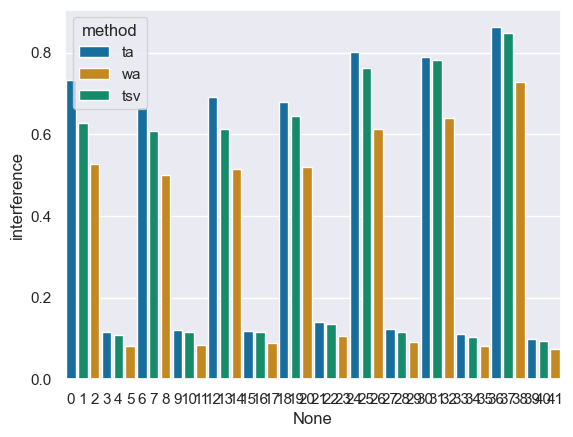

In [39]:
import seaborn as sns
import pandas as pd
# make df from interferences
df_interferences = pd.DataFrame(interferences)
method_order = ['ta', 'wa', 'tsv']
sns.barplot(x=df_interferences.index, y='interference', hue='method', data=df_interferences, hue_order=method_order)


### Analyze task vector orthogonality

dict_keys(['model.positional_embedding', 'model.text_projection', 'model.logit_scale', 'model.visual.class_embedding', 'model.visual.positional_embedding', 'model.visual.proj', 'model.visual.conv1', 'model.visual.ln_pre', 'model.visual.ln_pre.bias', 'model.visual.transformer.resblocks.0.ln_1', 'model.visual.transformer.resblocks.0.ln_1.bias', 'model.visual.transformer.resblocks.0.attn.in_proj_weight', 'model.visual.transformer.resblocks.0.attn.in_proj_bias', 'model.visual.transformer.resblocks.0.attn.out_proj', 'model.visual.transformer.resblocks.0.attn.out_proj.bias', 'model.visual.transformer.resblocks.0.ln_2', 'model.visual.transformer.resblocks.0.ln_2.bias', 'model.visual.transformer.resblocks.0.mlp.c_fc', 'model.visual.transformer.resblocks.0.mlp.c_fc.bias', 'model.visual.transformer.resblocks.0.mlp.c_proj', 'model.visual.transformer.resblocks.0.mlp.c_proj.bias', 'model.visual.transformer.resblocks.1.ln_1', 'model.visual.transformer.resblocks.1.ln_1.bias', 'model.visual.transforme

<Axes: >

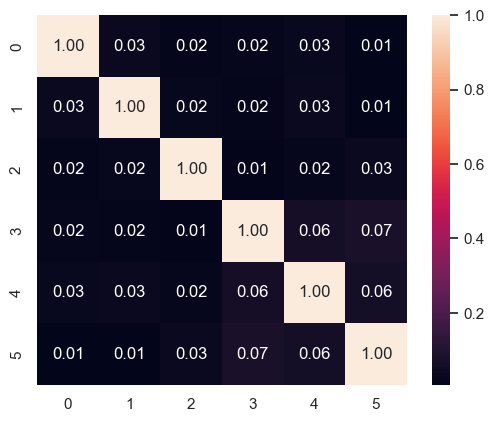

In [34]:
import pickle
import os.path as osp
results_dir = "results"

with open(osp.join(results_dir, f"mats.pkl"), "rb") as f:
    mats_dict = pickle.load(f)

mats = mats_dict['weights']
mats = {k.replace("image_encoder.", "").replace(".weight", ""): v for k, v in mats.items()}

print(mats.keys())
k = 'model.visual.transformer.resblocks.0.mlp.c_fc'
m = torch.from_numpy(mats[k])
m_tilde = m / torch.linalg.norm(m, dim=-1, keepdim=True)
z = torch.einsum('toi,loi->otl', m_tilde, m_tilde)
sns.heatmap(z.mean(dim=0).numpy(), cmap="rocket", square=True, annot=True, fmt=".2f")

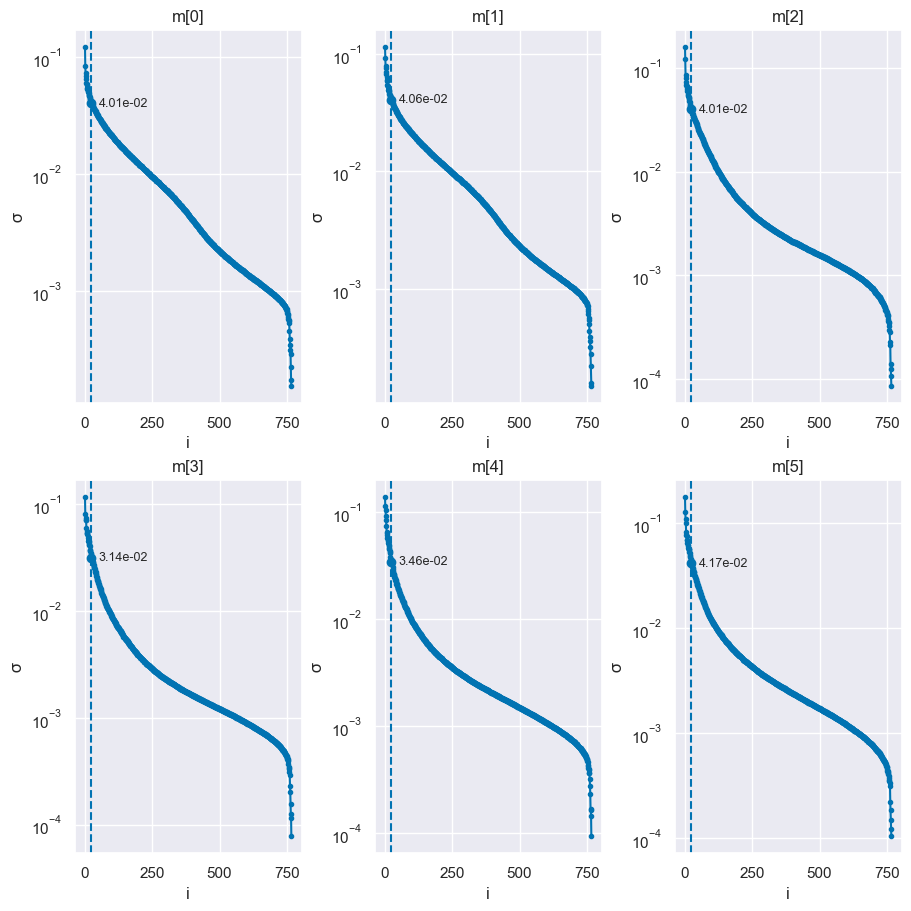

In [47]:
import numpy as np, matplotlib.pyplot as plt

T = 32

fig, axs = plt.subplots(2, 3, figsize=(9, 9), constrained_layout=True)
axs = axs.ravel()

for i, (ax, M) in enumerate(zip(axs, m)):
    s = np.sort(np.linalg.svd(M, compute_uv=False))[::-1]
    ax.semilogy(s, ".-")

    D = len(s)
    k = D // T
    y = s[k]

    ax.axvline(k, linestyle="--")
    ax.scatter([k], [y])
    ax.annotate(
        f"{y:.2e}",
        (k, y),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=9
    )

    ax.set(title=f"m[{i}]", xlabel="i", ylabel="σ")

for ax in axs[len(m):]:
    ax.axis("off")

plt.show()


In [ ]:
import pickle
import os.path as osp
results_dir = "results"

with open(osp.join(results_dir, f"mats.pkl"), "rb") as f:
    mats_dict = pickle.load(f)

mats = mats_dict['weights']
mats = {k.replace("image_encoder.", "").replace(".weight", ""): v for k, v in mats.items()}

print(mats.keys())
k = 'model.visual.transformer.resblocks.0.mlp.c_fc'
m = torch.from_numpy(mats[k])
m.shape
# m_tilde = m / torch.linalg.norm(m, dim=-1, keepdim=True)
# z = torch.einsum('toi,loi->otl', m_tilde, m_tilde)
# sns.heatmap(z.mean(dim=0).numpy(), cmap="rocket", square=True, annot=True, fmt=".2f")

### Analyze task data orthogonality

In [1]:
import pickle
import os
import os.path as osp
import torch
results_dir = "results"


# 1. Load layer covariances for each task
task_list = ['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'MNIST', 'SVHN']
dataset_covs = {}
for filename in [f for f in os.listdir(results_dir) if "covs" in f]:
    with open(osp.join(results_dir, filename), "rb") as f:
        covs_dict_i = pickle.load(f)
        dataset_name = filename.split('covs_')[1].split(".pkl")[0]
        dataset_covs[dataset_name] = covs_dict_i['covs']
# order covariances
dataset_covs = {
    k: dataset_covs[k]
    for k in task_list
    if k in dataset_covs
}
print("datasets_covs:", dataset_covs.keys())

# 2. Load layer transforms for each task (already stacked)
with open(osp.join(results_dir, f"mats.pkl"), "rb") as f:
    mats_dict = pickle.load(f)
mats = mats_dict['weights']
mats_task_names = mats_dict['datasets']

# Order mats
# indices that reorder current -> desired
mats_task_order = [mats_task_names.index(t) for t in task_list if t in mats_task_names]
print("mask_task_order:", mats_task_order)
# reorder each matrix
for k in mats:
    mats[k] = mats[k][mats_task_order]

# Fix keys names
# remove image_encoder. and .weight from keys
mats = {k.replace("image_encoder.", "").replace(".weight", ""): v for k, v in mats.items()}
for dataset_name in dataset_covs:
    covs = dataset_covs[dataset_name]
    dataset_covs[dataset_name] = {k.replace("image_encoder.", "").replace(".weight", ""): v for k, v in covs.items()}
print("Covs:", covs.keys())
print("Mats:", mats.keys())

datasets_covs: dict_keys(['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'SVHN'])
mask_task_order: [0, 1, 2, 3, 4, 5]
Covs: dict_keys(['image_encoder.model.visual.transformer.resblocks.0.mlp.c_fc', 'image_encoder.model.visual.transformer.resblocks.0.mlp.c_proj', 'image_encoder.model.visual.transformer.resblocks.1.mlp.c_fc', 'image_encoder.model.visual.transformer.resblocks.1.mlp.c_proj', 'image_encoder.model.visual.transformer.resblocks.2.mlp.c_fc', 'image_encoder.model.visual.transformer.resblocks.2.mlp.c_proj', 'image_encoder.model.visual.transformer.resblocks.3.mlp.c_fc', 'image_encoder.model.visual.transformer.resblocks.3.mlp.c_proj', 'image_encoder.model.visual.transformer.resblocks.4.mlp.c_fc', 'image_encoder.model.visual.transformer.resblocks.4.mlp.c_proj', 'image_encoder.model.visual.transformer.resblocks.5.mlp.c_fc', 'image_encoder.model.visual.transformer.resblocks.5.mlp.c_proj', 'image_encoder.model.visual.transformer.resblocks.6.mlp.c_fc', 'image_encoder.model.visual.transformer.resblo

In [2]:
print(len(dataset_covs['Cars']))
k0 = next(iter(dataset_covs['Cars'].keys()))
print(dataset_covs['Cars'][k0].shape)
added_layers = ['model.positional_embedding', 'model.text_projection', 'model.logit_scale', 'model.visual.class_embedding', 'model.visual.positional_embedding', 'model.visual.proj', 'model.visual.conv1.weight', 'model.visual.ln_pre.weight', 'model.visual.ln_pre.bias', 'model.visual.transformer.resblocks.0.ln_1.weight', 'model.visual.transformer.resblocks.0.ln_1.bias', 'model.visual.transformer.resblocks.0.attn.in_proj_weight', 'model.visual.transformer.resblocks.0.attn.in_proj_bias', 'model.visual.transformer.resblocks.0.attn.out_proj.weight', 'model.visual.transformer.resblocks.0.attn.out_proj.bias', 'model.visual.transformer.resblocks.0.ln_2.weight', 'model.visual.transformer.resblocks.0.ln_2.bias', 'model.visual.transformer.resblocks.0.mlp.c_fc.weight', 'model.visual.transformer.resblocks.0.mlp.c_fc.bias', 'model.visual.transformer.resblocks.0.mlp.c_proj.weight', 'model.visual.transformer.resblocks.0.mlp.c_proj.bias', 'model.visual.transformer.resblocks.1.ln_1.weight', 'model.visual.transformer.resblocks.1.ln_1.bias', 'model.visual.transformer.resblocks.1.attn.in_proj_weight', 'model.visual.transformer.resblocks.1.attn.in_proj_bias', 'model.visual.transformer.resblocks.1.attn.out_proj.weight', 'model.visual.transformer.resblocks.1.attn.out_proj.bias', 'model.visual.transformer.resblocks.1.ln_2.weight', 'model.visual.transformer.resblocks.1.ln_2.bias', 'model.visual.transformer.resblocks.1.mlp.c_fc.weight', 'model.visual.transformer.resblocks.1.mlp.c_fc.bias', 'model.visual.transformer.resblocks.1.mlp.c_proj.weight', 'model.visual.transformer.resblocks.1.mlp.c_proj.bias', 'model.visual.transformer.resblocks.2.ln_1.weight', 'model.visual.transformer.resblocks.2.ln_1.bias', 'model.visual.transformer.resblocks.2.attn.in_proj_weight', 'model.visual.transformer.resblocks.2.attn.in_proj_bias', 'model.visual.transformer.resblocks.2.attn.out_proj.weight', 'model.visual.transformer.resblocks.2.attn.out_proj.bias', 'model.visual.transformer.resblocks.2.ln_2.weight', 'model.visual.transformer.resblocks.2.ln_2.bias', 'model.visual.transformer.resblocks.2.mlp.c_fc.weight', 'model.visual.transformer.resblocks.2.mlp.c_fc.bias', 'model.visual.transformer.resblocks.2.mlp.c_proj.weight', 'model.visual.transformer.resblocks.2.mlp.c_proj.bias', 'model.visual.transformer.resblocks.3.ln_1.weight', 'model.visual.transformer.resblocks.3.ln_1.bias', 'model.visual.transformer.resblocks.3.attn.in_proj_weight', 'model.visual.transformer.resblocks.3.attn.in_proj_bias', 'model.visual.transformer.resblocks.3.attn.out_proj.weight', 'model.visual.transformer.resblocks.3.attn.out_proj.bias', 'model.visual.transformer.resblocks.3.ln_2.weight', 'model.visual.transformer.resblocks.3.ln_2.bias', 'model.visual.transformer.resblocks.3.mlp.c_fc.weight', 'model.visual.transformer.resblocks.3.mlp.c_fc.bias', 'model.visual.transformer.resblocks.3.mlp.c_proj.weight', 'model.visual.transformer.resblocks.3.mlp.c_proj.bias', 'model.visual.transformer.resblocks.4.ln_1.weight', 'model.visual.transformer.resblocks.4.ln_1.bias', 'model.visual.transformer.resblocks.4.attn.in_proj_weight', 'model.visual.transformer.resblocks.4.attn.in_proj_bias', 'model.visual.transformer.resblocks.4.attn.out_proj.weight', 'model.visual.transformer.resblocks.4.attn.out_proj.bias', 'model.visual.transformer.resblocks.4.ln_2.weight', 'model.visual.transformer.resblocks.4.ln_2.bias', 'model.visual.transformer.resblocks.4.mlp.c_fc.weight', 'model.visual.transformer.resblocks.4.mlp.c_fc.bias', 'model.visual.transformer.resblocks.4.mlp.c_proj.weight', 'model.visual.transformer.resblocks.4.mlp.c_proj.bias', 'model.visual.transformer.resblocks.5.ln_1.weight', 'model.visual.transformer.resblocks.5.ln_1.bias', 'model.visual.transformer.resblocks.5.attn.in_proj_weight', 'model.visual.transformer.resblocks.5.attn.in_proj_bias', 'model.visual.transformer.resblocks.5.attn.out_proj.weight', 'model.visual.transformer.resblocks.5.attn.out_proj.bias', 'model.visual.transformer.resblocks.5.ln_2.weight', 'model.visual.transformer.resblocks.5.ln_2.bias', 'model.visual.transformer.resblocks.5.mlp.c_fc.weight', 'model.visual.transformer.resblocks.5.mlp.c_fc.bias', 'model.visual.transformer.resblocks.5.mlp.c_proj.weight', 'model.visual.transformer.resblocks.5.mlp.c_proj.bias', 'model.visual.transformer.resblocks.6.ln_1.weight', 'model.visual.transformer.resblocks.6.ln_1.bias', 'model.visual.transformer.resblocks.6.attn.in_proj_weight', 'model.visual.transformer.resblocks.6.attn.in_proj_bias', 'model.visual.transformer.resblocks.6.attn.out_proj.weight', 'model.visual.transformer.resblocks.6.attn.out_proj.bias', 'model.visual.transformer.resblocks.6.ln_2.weight', 'model.visual.transformer.resblocks.6.ln_2.bias', 'model.visual.transformer.resblocks.6.mlp.c_fc.weight', 'model.visual.transformer.resblocks.6.mlp.c_fc.bias', 'model.visual.transformer.resblocks.6.mlp.c_proj.weight', 'model.visual.transformer.resblocks.6.mlp.c_proj.bias', 'model.visual.transformer.resblocks.7.ln_1.weight', 'model.visual.transformer.resblocks.7.ln_1.bias', 'model.visual.transformer.resblocks.7.attn.in_proj_weight', 'model.visual.transformer.resblocks.7.attn.in_proj_bias', 'model.visual.transformer.resblocks.7.attn.out_proj.weight', 'model.visual.transformer.resblocks.7.attn.out_proj.bias', 'model.visual.transformer.resblocks.7.ln_2.weight', 'model.visual.transformer.resblocks.7.ln_2.bias', 'model.visual.transformer.resblocks.7.mlp.c_fc.weight', 'model.visual.transformer.resblocks.7.mlp.c_fc.bias', 'model.visual.transformer.resblocks.7.mlp.c_proj.weight', 'model.visual.transformer.resblocks.7.mlp.c_proj.bias', 'model.visual.transformer.resblocks.8.ln_1.weight', 'model.visual.transformer.resblocks.8.ln_1.bias', 'model.visual.transformer.resblocks.8.attn.in_proj_weight', 'model.visual.transformer.resblocks.8.attn.in_proj_bias', 'model.visual.transformer.resblocks.8.attn.out_proj.weight', 'model.visual.transformer.resblocks.8.attn.out_proj.bias', 'model.visual.transformer.resblocks.8.ln_2.weight', 'model.visual.transformer.resblocks.8.ln_2.bias', 'model.visual.transformer.resblocks.8.mlp.c_fc.weight', 'model.visual.transformer.resblocks.8.mlp.c_fc.bias', 'model.visual.transformer.resblocks.8.mlp.c_proj.weight', 'model.visual.transformer.resblocks.8.mlp.c_proj.bias', 'model.visual.transformer.resblocks.9.ln_1.weight', 'model.visual.transformer.resblocks.9.ln_1.bias', 'model.visual.transformer.resblocks.9.attn.in_proj_weight', 'model.visual.transformer.resblocks.9.attn.in_proj_bias', 'model.visual.transformer.resblocks.9.attn.out_proj.weight', 'model.visual.transformer.resblocks.9.attn.out_proj.bias', 'model.visual.transformer.resblocks.9.ln_2.weight', 'model.visual.transformer.resblocks.9.ln_2.bias', 'model.visual.transformer.resblocks.9.mlp.c_fc.weight', 'model.visual.transformer.resblocks.9.mlp.c_fc.bias', 'model.visual.transformer.resblocks.9.mlp.c_proj.weight', 'model.visual.transformer.resblocks.9.mlp.c_proj.bias', 'model.visual.transformer.resblocks.10.ln_1.weight', 'model.visual.transformer.resblocks.10.ln_1.bias', 'model.visual.transformer.resblocks.10.attn.in_proj_weight', 'model.visual.transformer.resblocks.10.attn.in_proj_bias', 'model.visual.transformer.resblocks.10.attn.out_proj.weight', 'model.visual.transformer.resblocks.10.attn.out_proj.bias', 'model.visual.transformer.resblocks.10.ln_2.weight', 'model.visual.transformer.resblocks.10.ln_2.bias', 'model.visual.transformer.resblocks.10.mlp.c_fc.weight', 'model.visual.transformer.resblocks.10.mlp.c_fc.bias', 'model.visual.transformer.resblocks.10.mlp.c_proj.weight', 'model.visual.transformer.resblocks.10.mlp.c_proj.bias', 'model.visual.transformer.resblocks.11.ln_1.weight', 'model.visual.transformer.resblocks.11.ln_1.bias', 'model.visual.transformer.resblocks.11.attn.in_proj_weight', 'model.visual.transformer.resblocks.11.attn.in_proj_bias', 'model.visual.transformer.resblocks.11.attn.out_proj.weight', 'model.visual.transformer.resblocks.11.attn.out_proj.bias', 'model.visual.transformer.resblocks.11.ln_2.weight', 'model.visual.transformer.resblocks.11.ln_2.bias', 'model.visual.transformer.resblocks.11.mlp.c_fc.weight', 'model.visual.transformer.resblocks.11.mlp.c_fc.bias', 'model.visual.transformer.resblocks.11.mlp.c_proj.weight', 'model.visual.transformer.resblocks.11.mlp.c_proj.bias', 'model.visual.ln_post.weight', 'model.visual.ln_post.bias', 'model.token_embedding.weight', 'model.ln_final.weight', 'model.ln_final.bias']
skipped_layers = ['model.transformer.resblocks.0.ln_1.weight', 'model.transformer.resblocks.0.ln_1.bias', 'model.transformer.resblocks.0.attn.in_proj_weight', 'model.transformer.resblocks.0.attn.in_proj_bias', 'model.transformer.resblocks.0.attn.out_proj.weight', 'model.transformer.resblocks.0.attn.out_proj.bias', 'model.transformer.resblocks.0.ln_2.weight', 'model.transformer.resblocks.0.ln_2.bias', 'model.transformer.resblocks.0.mlp.c_fc.weight', 'model.transformer.resblocks.0.mlp.c_fc.bias', 'model.transformer.resblocks.0.mlp.c_proj.weight', 'model.transformer.resblocks.0.mlp.c_proj.bias', 'model.transformer.resblocks.1.ln_1.weight', 'model.transformer.resblocks.1.ln_1.bias', 'model.transformer.resblocks.1.attn.in_proj_weight', 'model.transformer.resblocks.1.attn.in_proj_bias', 'model.transformer.resblocks.1.attn.out_proj.weight', 'model.transformer.resblocks.1.attn.out_proj.bias', 'model.transformer.resblocks.1.ln_2.weight', 'model.transformer.resblocks.1.ln_2.bias', 'model.transformer.resblocks.1.mlp.c_fc.weight', 'model.transformer.resblocks.1.mlp.c_fc.bias', 'model.transformer.resblocks.1.mlp.c_proj.weight', 'model.transformer.resblocks.1.mlp.c_proj.bias', 'model.transformer.resblocks.2.ln_1.weight', 'model.transformer.resblocks.2.ln_1.bias', 'model.transformer.resblocks.2.attn.in_proj_weight', 'model.transformer.resblocks.2.attn.in_proj_bias', 'model.transformer.resblocks.2.attn.out_proj.weight', 'model.transformer.resblocks.2.attn.out_proj.bias', 'model.transformer.resblocks.2.ln_2.weight', 'model.transformer.resblocks.2.ln_2.bias', 'model.transformer.resblocks.2.mlp.c_fc.weight', 'model.transformer.resblocks.2.mlp.c_fc.bias', 'model.transformer.resblocks.2.mlp.c_proj.weight', 'model.transformer.resblocks.2.mlp.c_proj.bias', 'model.transformer.resblocks.3.ln_1.weight', 'model.transformer.resblocks.3.ln_1.bias', 'model.transformer.resblocks.3.attn.in_proj_weight', 'model.transformer.resblocks.3.attn.in_proj_bias', 'model.transformer.resblocks.3.attn.out_proj.weight', 'model.transformer.resblocks.3.attn.out_proj.bias', 'model.transformer.resblocks.3.ln_2.weight', 'model.transformer.resblocks.3.ln_2.bias', 'model.transformer.resblocks.3.mlp.c_fc.weight', 'model.transformer.resblocks.3.mlp.c_fc.bias', 'model.transformer.resblocks.3.mlp.c_proj.weight', 'model.transformer.resblocks.3.mlp.c_proj.bias', 'model.transformer.resblocks.4.ln_1.weight', 'model.transformer.resblocks.4.ln_1.bias', 'model.transformer.resblocks.4.attn.in_proj_weight', 'model.transformer.resblocks.4.attn.in_proj_bias', 'model.transformer.resblocks.4.attn.out_proj.weight', 'model.transformer.resblocks.4.attn.out_proj.bias', 'model.transformer.resblocks.4.ln_2.weight', 'model.transformer.resblocks.4.ln_2.bias', 'model.transformer.resblocks.4.mlp.c_fc.weight', 'model.transformer.resblocks.4.mlp.c_fc.bias', 'model.transformer.resblocks.4.mlp.c_proj.weight', 'model.transformer.resblocks.4.mlp.c_proj.bias', 'model.transformer.resblocks.5.ln_1.weight', 'model.transformer.resblocks.5.ln_1.bias', 'model.transformer.resblocks.5.attn.in_proj_weight', 'model.transformer.resblocks.5.attn.in_proj_bias', 'model.transformer.resblocks.5.attn.out_proj.weight', 'model.transformer.resblocks.5.attn.out_proj.bias', 'model.transformer.resblocks.5.ln_2.weight', 'model.transformer.resblocks.5.ln_2.bias', 'model.transformer.resblocks.5.mlp.c_fc.weight', 'model.transformer.resblocks.5.mlp.c_fc.bias', 'model.transformer.resblocks.5.mlp.c_proj.weight', 'model.transformer.resblocks.5.mlp.c_proj.bias', 'model.transformer.resblocks.6.ln_1.weight', 'model.transformer.resblocks.6.ln_1.bias', 'model.transformer.resblocks.6.attn.in_proj_weight', 'model.transformer.resblocks.6.attn.in_proj_bias', 'model.transformer.resblocks.6.attn.out_proj.weight', 'model.transformer.resblocks.6.attn.out_proj.bias', 'model.transformer.resblocks.6.ln_2.weight', 'model.transformer.resblocks.6.ln_2.bias', 'model.transformer.resblocks.6.mlp.c_fc.weight', 'model.transformer.resblocks.6.mlp.c_fc.bias', 'model.transformer.resblocks.6.mlp.c_proj.weight', 'model.transformer.resblocks.6.mlp.c_proj.bias', 'model.transformer.resblocks.7.ln_1.weight', 'model.transformer.resblocks.7.ln_1.bias', 'model.transformer.resblocks.7.attn.in_proj_weight', 'model.transformer.resblocks.7.attn.in_proj_bias', 'model.transformer.resblocks.7.attn.out_proj.weight', 'model.transformer.resblocks.7.attn.out_proj.bias', 'model.transformer.resblocks.7.ln_2.weight', 'model.transformer.resblocks.7.ln_2.bias', 'model.transformer.resblocks.7.mlp.c_fc.weight', 'model.transformer.resblocks.7.mlp.c_fc.bias', 'model.transformer.resblocks.7.mlp.c_proj.weight', 'model.transformer.resblocks.7.mlp.c_proj.bias', 'model.transformer.resblocks.8.ln_1.weight', 'model.transformer.resblocks.8.ln_1.bias', 'model.transformer.resblocks.8.attn.in_proj_weight', 'model.transformer.resblocks.8.attn.in_proj_bias', 'model.transformer.resblocks.8.attn.out_proj.weight', 'model.transformer.resblocks.8.attn.out_proj.bias', 'model.transformer.resblocks.8.ln_2.weight', 'model.transformer.resblocks.8.ln_2.bias', 'model.transformer.resblocks.8.mlp.c_fc.weight', 'model.transformer.resblocks.8.mlp.c_fc.bias', 'model.transformer.resblocks.8.mlp.c_proj.weight', 'model.transformer.resblocks.8.mlp.c_proj.bias', 'model.transformer.resblocks.9.ln_1.weight', 'model.transformer.resblocks.9.ln_1.bias', 'model.transformer.resblocks.9.attn.in_proj_weight', 'model.transformer.resblocks.9.attn.in_proj_bias', 'model.transformer.resblocks.9.attn.out_proj.weight', 'model.transformer.resblocks.9.attn.out_proj.bias', 'model.transformer.resblocks.9.ln_2.weight', 'model.transformer.resblocks.9.ln_2.bias', 'model.transformer.resblocks.9.mlp.c_fc.weight', 'model.transformer.resblocks.9.mlp.c_fc.bias', 'model.transformer.resblocks.9.mlp.c_proj.weight', 'model.transformer.resblocks.9.mlp.c_proj.bias', 'model.transformer.resblocks.10.ln_1.weight', 'model.transformer.resblocks.10.ln_1.bias', 'model.transformer.resblocks.10.attn.in_proj_weight', 'model.transformer.resblocks.10.attn.in_proj_bias', 'model.transformer.resblocks.10.attn.out_proj.weight', 'model.transformer.resblocks.10.attn.out_proj.bias', 'model.transformer.resblocks.10.ln_2.weight', 'model.transformer.resblocks.10.ln_2.bias', 'model.transformer.resblocks.10.mlp.c_fc.weight', 'model.transformer.resblocks.10.mlp.c_fc.bias', 'model.transformer.resblocks.10.mlp.c_proj.weight', 'model.transformer.resblocks.10.mlp.c_proj.bias', 'model.transformer.resblocks.11.ln_1.weight', 'model.transformer.resblocks.11.ln_1.bias', 'model.transformer.resblocks.11.attn.in_proj_weight', 'model.transformer.resblocks.11.attn.in_proj_bias', 'model.transformer.resblocks.11.attn.out_proj.weight', 'model.transformer.resblocks.11.attn.out_proj.bias', 'model.transformer.resblocks.11.ln_2.weight', 'model.transformer.resblocks.11.ln_2.bias', 'model.transformer.resblocks.11.mlp.c_fc.weight', 'model.transformer.resblocks.11.mlp.c_fc.bias', 'model.transformer.resblocks.11.mlp.c_proj.weight', 'model.transformer.resblocks.11.mlp.c_proj.bias']


14
(768, 768)


In [14]:
import itertools
N_TASKS_COV = len(dataset_covs)
N_TASKS_MAT = len(mats[list(mats.keys())[0]])
N_LAYERS = len(dataset_covs[list(dataset_covs.keys())[0]])
print(N_TASKS_COV, N_TASKS_MAT, N_LAYERS)
traces = torch.zeros(N_TASKS_COV, N_LAYERS, N_TASKS_MAT, N_TASKS_MAT)
for t, d in enumerate(dataset_covs):
    covs = dataset_covs[d]
    for l, layer_name in enumerate(covs.keys()):
        if layer_name + ".weight" in skipped_layers:
            print(f"Skipping layer {layer_name}")
            continue
        c = torch.from_numpy(covs[layer_name]).to(torch.float32)
        m = torch.from_numpy(mats[layer_name]).to(torch.float32)
        for i, j in itertools.product(range(m.shape[0]), range(m.shape[0])):
            mi, mj = m[i], m[j]
            traces[t, l, i, j] = torch.trace(mi @ c @ mj.T)


6 6 14


In [15]:
# Save trace file
torch.save(traces, 'results/traces.pt')

torch.Size([6, 14, 6, 6])


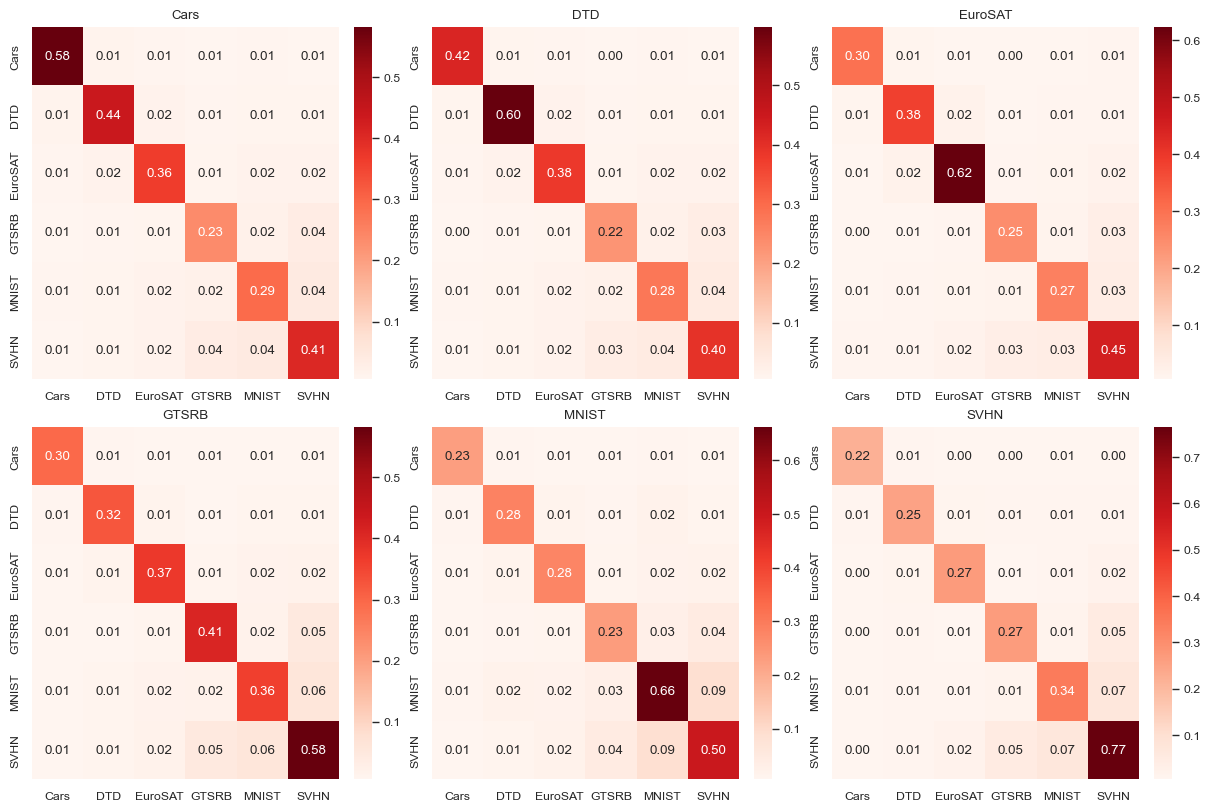

In [ ]:
# DBEUG: skip first 5 layers
traces = torch.load('results/traces.pt')
# traces = traces[:, 0:5]
print(traces.shape)

nk, nl, ni, nj = traces.shape
traces_mags = torch.linalg.norm(traces.reshape(nk, nl, -1), dim=-1)
traces_normed = traces / traces_mags.reshape(nk, nl, 1, 1)

import math
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'MNIST', 'SVHN']
T = len(labels)

ncols = min(3, T)
nrows = math.ceil(T / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), constrained_layout=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= T:
        ax.remove()
        continue

    sns.heatmap(
        traces_normed.mean(dim=1)[i].numpy(),
        cmap="Reds",
        annot=True,
        fmt=".2f",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_title(labels[i])
    # ax.invert_yaxis()

plt.show()



torch.Size([6, 14, 6, 6])
Num. Rows: 4
Num. Cols: 4


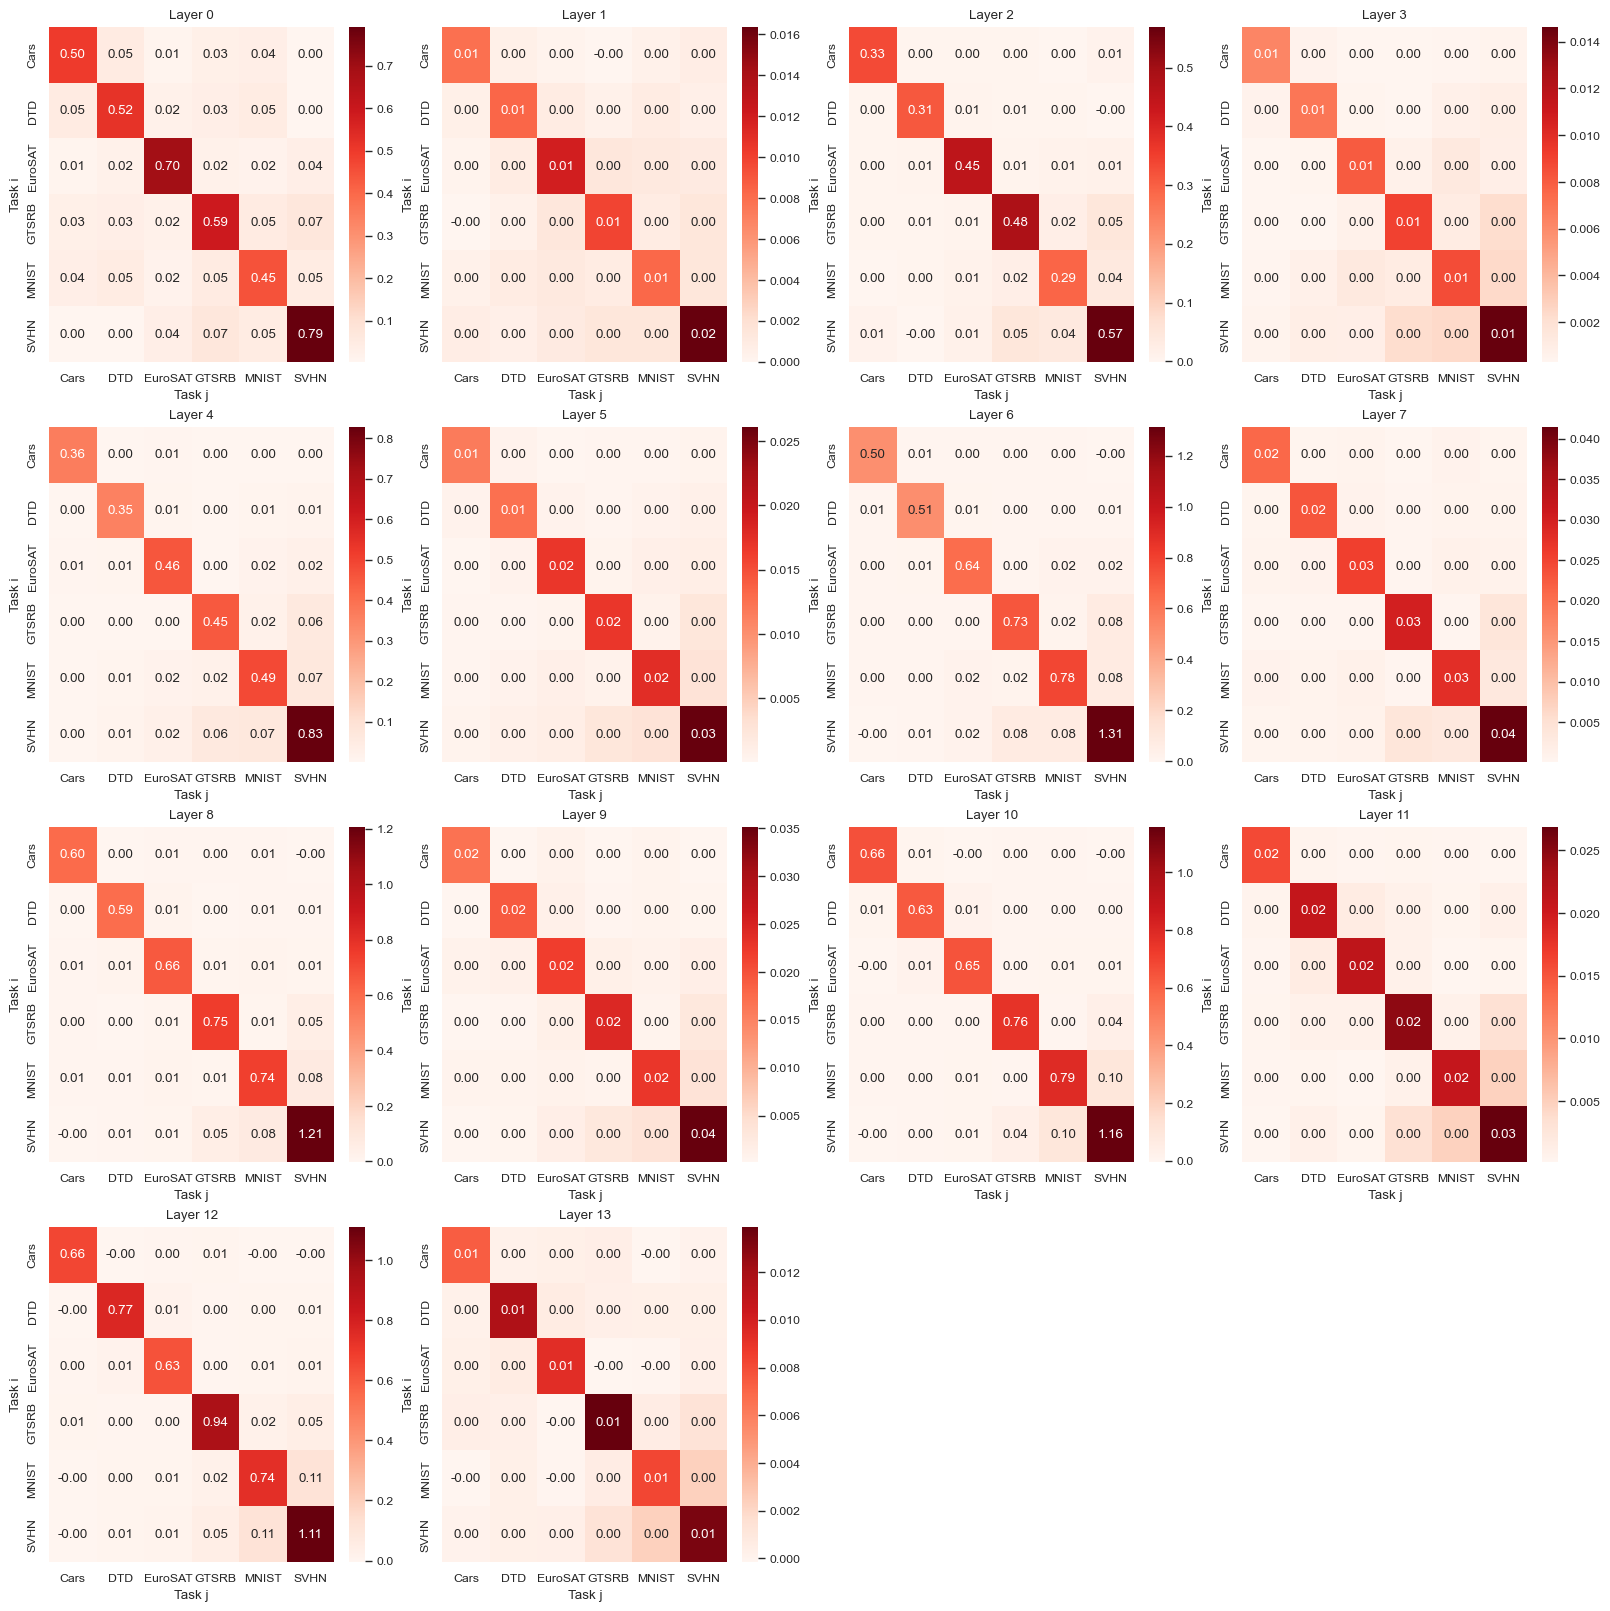

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np

# DBEUG: skip first 5 layers
traces = torch.load('results/traces.pt')
print(traces.shape)
nk, nl, ni, nj = traces.shape

sns.set_theme()
sns.set_context("paper")
sns.set_palette("colorblind")

# Get public dataset (task) names from mats_dict['datasets'], assuming order matches
labels = ['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'MNIST', 'SVHN']

# Allow column wrap
max_cols = 4  # Max number of columns per row
n_cols = min(nl, max_cols)
n_rows = math.ceil(nl / n_cols)
print("Num. Rows:", n_rows)
print("Num. Cols:", n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), constrained_layout=True)

# Ensure axs is 2d array for easier indexing
axs = np.atleast_2d(axs)
axs = np.array(axs).reshape(n_rows, n_cols)

for l in range(nl):
    row = l // n_cols
    col = l % n_cols
    ax = axs[row, col]
    sns.heatmap(
        traces[3, l].numpy(), 
        cmap="Reds", 
        ax=ax, 
        # square=True, 
        # cbar=(l == N_LAYERS - 1), 
        annot=True, 
        fmt=".2f",
        xticklabels=labels,
        yticklabels=labels
    )
    ax.set_title(f'Layer {l}')
    ax.set_xlabel('Task j')
    ax.set_ylabel('Task i')

# Hide unused subplots if any
for l in range(nl, n_rows * n_cols):
    row = l // n_cols
    col = l % n_cols
    fig.delaxes(axs[row, col])

plt.show()

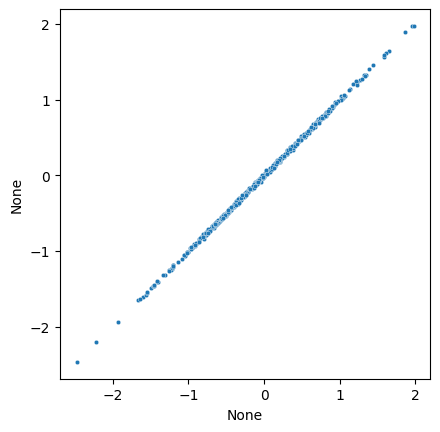

tensor([[0.4873, 0.4878],
        [0.4878, 0.4886]])


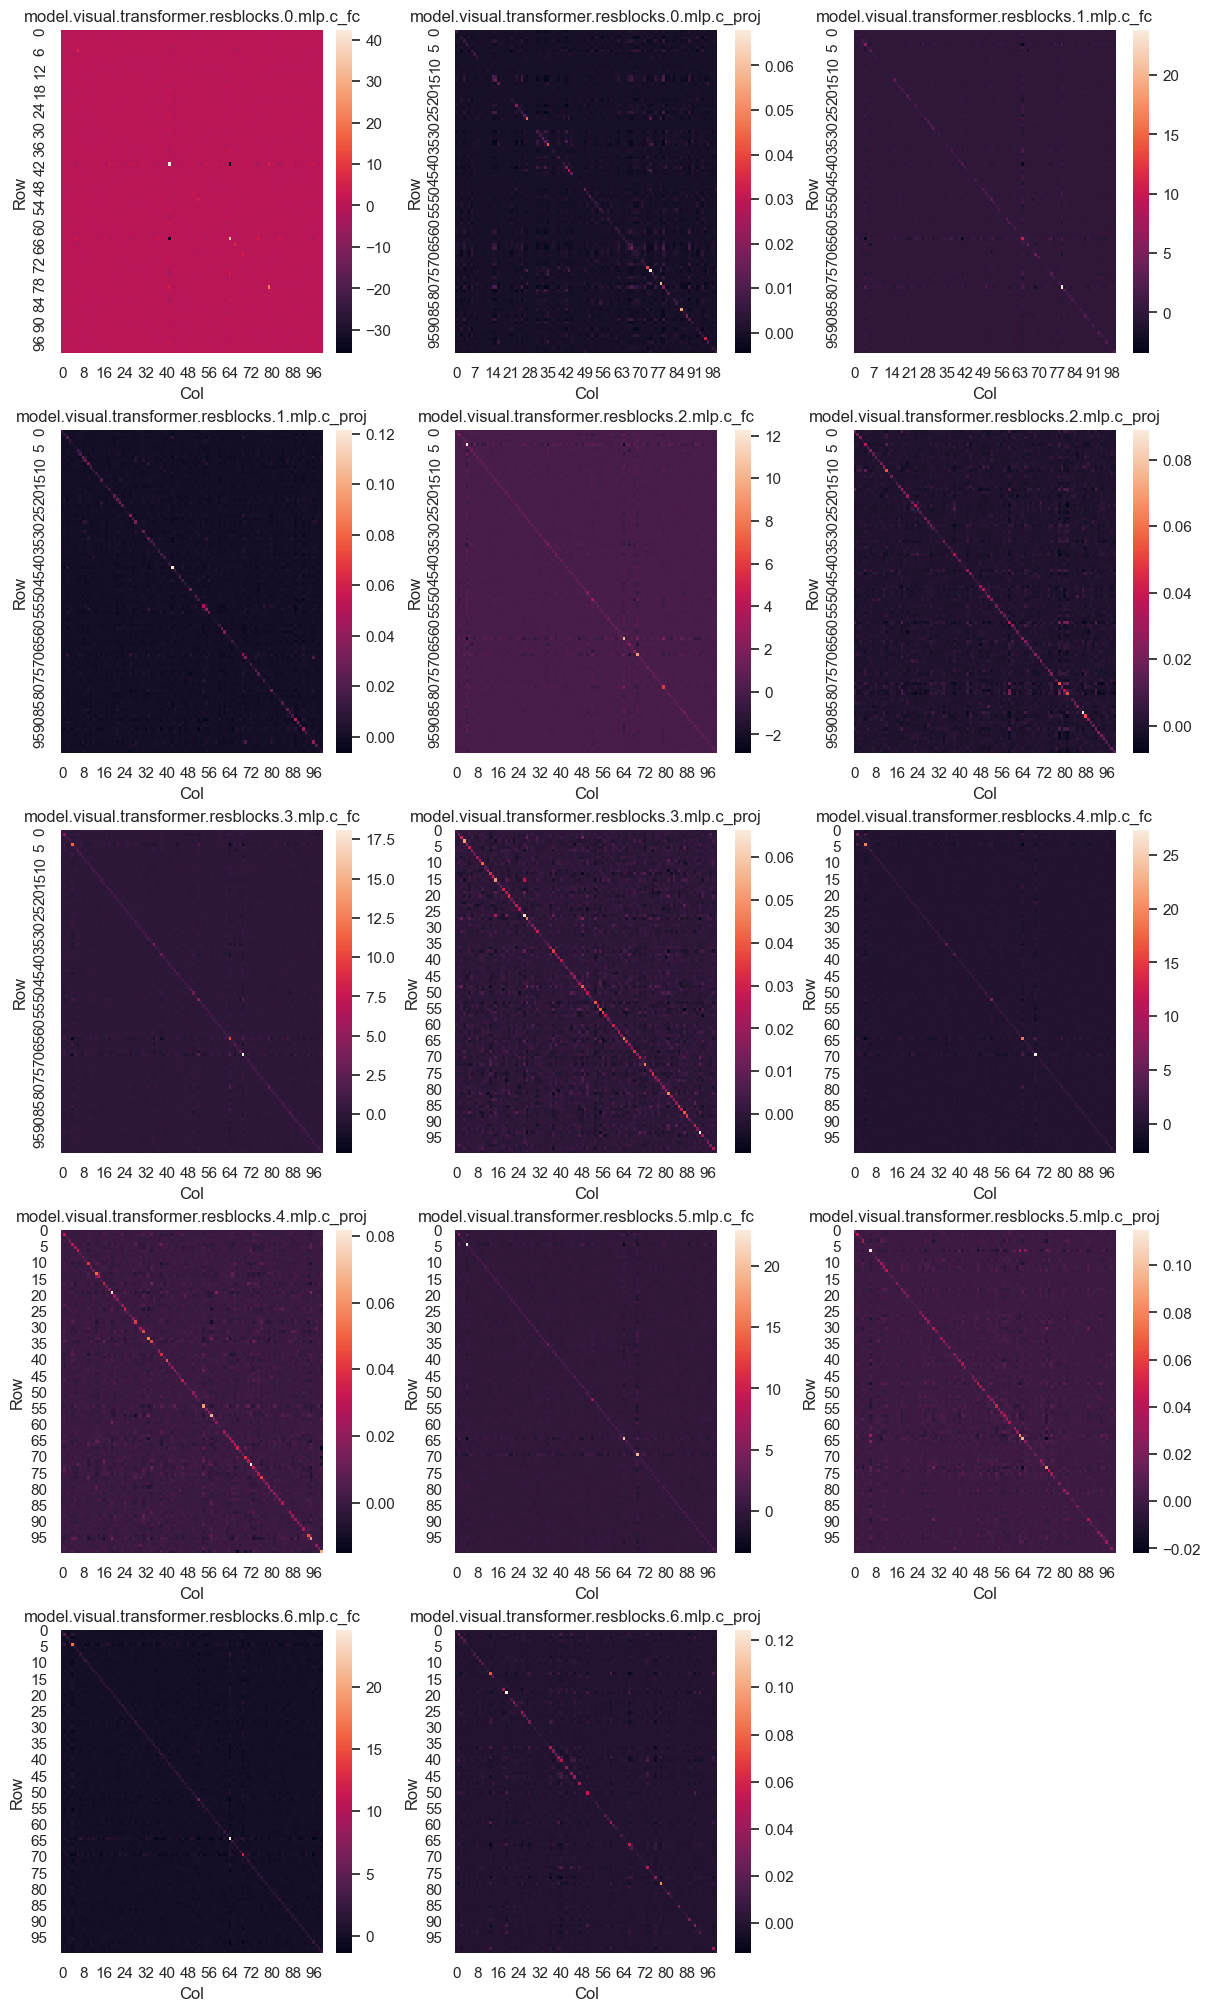

In [152]:
# Assume c is a 2D numpy array or torch tensor you want to plot as a heatmap
from matplotlib.colors import LogNorm
vmin, vmax = c.min(), c.max()

N_LAYERS = len(covs)
n_cols = min(N_LAYERS, 3)
n_rows = math.ceil(N_LAYERS / n_cols)
n_pts = 100 
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), constrained_layout=True)

axs = np.array(axs).reshape(-1)
for ax, layer_name in zip(axs, covs.keys()):
    c = torch.from_numpy(covs[layer_name]).float()[:n_pts, :n_pts]
    sns.heatmap(c, ax=ax)
    ax.set_title(layer_name)
    ax.set_xlabel("Col")
    ax.set_ylabel("Row")

for ax in axs[len(covs):]:
    ax.remove()
plt.show()



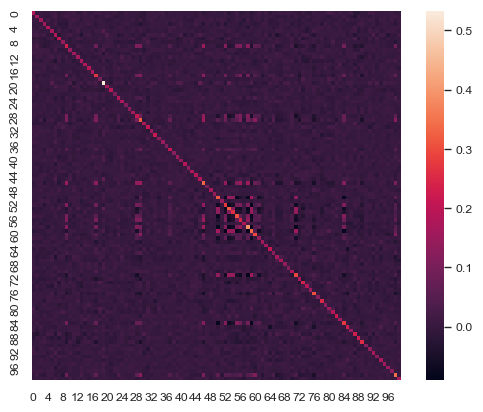

In [82]:
# Assume c is a 2D numpy array or torch tensor you want to plot as a heatmap
from matplotlib.colors import LogNorm
n_pts = 100 
cs = []
for layer_name in covs.keys():
    c = torch.from_numpy(covs[layer_name]).float()[:n_pts, :n_pts]
    cs.append(c)

c_avg = torch.stack(cs).mean(dim=0)
sns.heatmap(c_avg, cmap="rocket", square=True)
plt.show()


## MISC

MISC

In [ ]:

# *** Helpers OLD
def interference_old(a1, a2, n_points=10_000, batch_size=100):
    """Computes interference E_x[||a1x - a2x||], where x ~ N(0, I).

    Args:
        a1 (torch.Tensor): (Do, Di)
        a2 (torch.Tensor): (Do, Di)
        n_points (int, optional): Number of points to sample. Defaults to 10_000.
        batch_size (int, optional): Batch size for sampling. Defaults to 100.

    Returns:
        float: Interference.
    """
    total = 0.0
    device = a1.device
    Do, Di = a1.shape
    n_batches = n_points // batch_size
    for _ in range(n_batches):
        x = torch.randn(batch_size, Di, device=device)
        diff = a1 @ x.T - a2 @ x.T  # shape (Do, batch_size)
        norm = torch.linalg.norm(diff, dim=0)  # shape (batch_size,)
        total += norm.sum().item()
    return total / (n_batches * batch_size)

def merge_tsv(tensors, *args, **kwargs):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l



import matplotlib.pyplot as plt

v = torch.randn(2, 1)
v = v / torch.linalg.norm(v)
V = torch.cat([v, v], dim=1)  # (2, 2)
Vortho = compute_procrustes(V)
v_recons = 1/2 * Vortho.sum(dim=1, keepdim=True)  # (2, 1)

plt.figure(figsize=(6, 6))
plt.quiver([0, 0], [0, 0], V[0], V[1], angles='xy', scale_units='xy', scale=1, color=['b', 'b'], label='Original V')
plt.quiver([0, 0], [0, 0], Vortho[0], Vortho[1], angles='xy', scale_units='xy', scale=1, color=['r', 'r'], label='Ortho V')
plt.quiver([0], [0], v_recons[0], v_recons[1], angles='xy', scale_units='xy', scale=1, color=['g'], label='Reconstructed v')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid()
plt.title('V before (blue), after (red) Procrustes, and v_recons (green)')
plt.legend(['Original V', 'Ortho V', 'Reconstructed v'])
plt.show()

# print lengths of v and v_recons
print(f"Length of v: {torch.linalg.norm(v).item():.4f}")
print(f"Length of v_recons: {torch.linalg.norm(v_recons).item():.4f}")


### TSV is close to Corrected WA

In [311]:
import torch
import math
import pandas as pd


D, Ta, Tb, Ka, Kb = 512, 2, 2, 8, 4
T = (Ka*Ta + Kb*Tb)
ua = torch.randn(D, Ta)
ub = torch.randn(D, Tb)
sa = torch.randn(Ta)
sb = torch.randn(Tb)
va = torch.randn(D, Ta)
vb = torch.randn(D, Tb)

# Normalize
ua = ua / ua.norm(dim=0, keepdim=True)
ub = ub / ub.norm(dim=0, keepdim=True)
va = va / va.norm(dim=0, keepdim=True)
vb = vb / vb.norm(dim=0, keepdim=True)

# Check all ortho
U = torch.cat(Ka*[ua] + Kb*[ub], dim=1)  # (D, T')
S = torch.cat(Ka*[sa] + Kb*[sb], dim=0)  # (T',)
V = torch.cat(Ka*[va] + Kb*[vb], dim=1)  # (D, T')
I_hat = U.T @ U  # (T', T')
print("Is ortho?", torch.allclose(I_hat, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Uortho = compute_procrustes(U)
Vortho = compute_procrustes(V)
print("Is ortho (procrustes)?", torch.allclose(Uortho.T @ Uortho, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Is ortho? False
Is ortho (procrustes)? True


In [315]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

# TODO:
# [ ] Compare for different ground truth alpha and alpha sweeps for both WA and TSV

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]


# Compare w_tsv to w_wagt
w_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho, S, Vortho.T)
w_tsv_sqmean = 1/math.sqrt(Ka*Ta) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) + 1/math.sqrt(Kb*Tb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_wa = torch.einsum("ij,j,jk->ik", U, S, V.T)
w_wagt = torch.einsum("ij,j,jk->ik", ua, sa, va.T) + torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
intf_tsv_sqmean_wagt = interference(w_tsv_sqmean, w_wagt)
intf_tsv_mean_wagt = interference(w_tsv_mean, w_wagt)
intf_wa_wagt = interference(w_wa, w_wagt)

# Compare w_a_tsv to w_a_wagt
w_a_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) 
w_a_tsv_sqmean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) * 1/math.sqrt(Ka)
w_a_wagt =  torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka * torch.einsum("ij,j,jk->ik", ua, sa, va.T)
intf_a_tsv_sqmean_wagt = interference(w_a_tsv_sqmean, w_a_wagt)
intf_a_tsv_mean_wagt = interference(w_a_tsv_mean, w_a_wagt)
intf_a_wa_wagt = interference(w_a_wa, w_a_wagt)


# Compare w_b_tsv to w_b_wagt
w_b_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_tsv_sqmean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T) * 1/math.sqrt(Kb)
w_b_wagt =  torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt
intf_b_tsv_sqmean_wagt = interference(w_b_tsv_sqmean, w_b_wagt)
intf_b_tsv_mean_wagt = interference(w_b_tsv_mean, w_b_wagt)
intf_b_wa_wagt = interference(w_b_wa, w_b_wagt)



# 1. Organize data into a dictionary
data = {
    "TSV (SqMean)": [intf_tsv_sqmean_wagt, intf_a_tsv_sqmean_wagt, intf_b_tsv_sqmean_wagt],
    "TSV":   [intf_tsv_mean_wagt,   intf_a_tsv_mean_wagt,   intf_b_tsv_mean_wagt],
    "TA (Baseline)": [intf_wa_wagt,          intf_a_wa_wagt,          intf_b_wa_wagt]
}

# 2. Create DataFrame with descriptive row index
df_intf = pd.DataFrame(data, index=["Total Weight", "Weight A", "Weight B"])

# 3. Print with a clear title and formatting
print("\n=== INTERFERENCE COMPARISON ===")
print(df_intf.to_string(float_format=lambda x: f"{x:.2f}"))



=== INTERFERENCE COMPARISON ===
              TSV (SqMean)  TSV  TA (Baseline)
Total Weight          2.01 4.88          10.85
Weight A              1.78 4.16           9.69
Weight B              1.38 2.37           3.58


### Least squares TSV

In [284]:
import torch

D, Ta, Tb, Ka, Kb = 512, 2, 2, 2, 1
ua = torch.randn(D, Ta)
ub = torch.randn(D, Tb)
sa = torch.randn(Ta)
sb = torch.randn(Tb)
va = torch.randn(D, Ta)
vb = torch.randn(D, Tb)

# Normalize
ua = ua / ua.norm(dim=0, keepdim=True)
ub = ub / ub.norm(dim=0, keepdim=True)
va = va / va.norm(dim=0, keepdim=True)
vb = vb / vb.norm(dim=0, keepdim=True)

# Check all ortho
U = torch.cat(Ka*[ua] + Kb*[ub], dim=1)  # (D, T')
S = torch.cat(Ka*[sa] + Kb*[sb], dim=0)  # (T',)
V = torch.cat(Ka*[va] + Kb*[vb], dim=1)  # (D, T')
I_hat = U.T @ U  # (T', T')
print("Is ortho?", torch.allclose(I_hat, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Uortho = compute_procrustes(U)
Vortho = compute_procrustes(V)
print("Is ortho (procrustes)?", torch.allclose(Uortho.T @ Uortho, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Is ortho? False
Is ortho (procrustes)? True


2


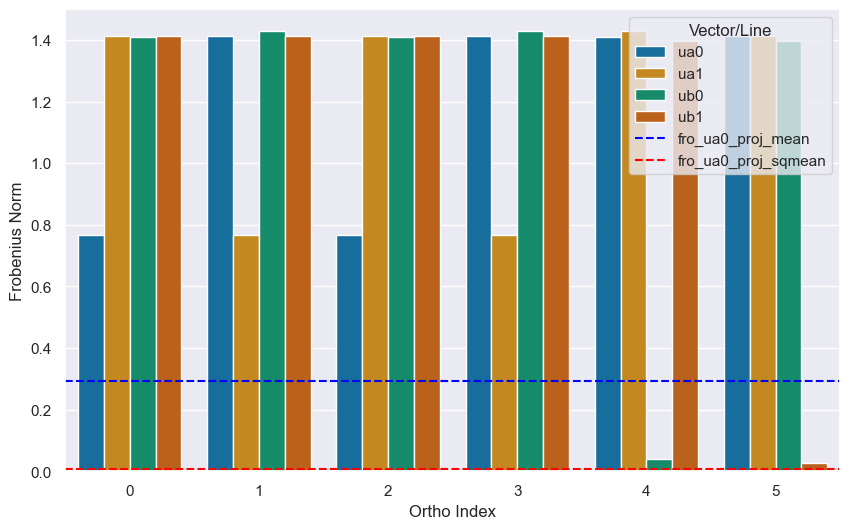

In [256]:
import seaborn as sns
import math
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme()
# use colorblind palette
sns.set_palette("colorblind")

fros_ua0 = [torch.linalg.norm(U[:, 0] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]
fros_ua1 = [torch.linalg.norm(U[:, 1] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]
fros_ub0 = [torch.linalg.norm(U[:, -2] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]
fros_ub1 = [torch.linalg.norm(U[:, -1] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]

ua0_proj = torch.stack([Uortho[:, i] for i in range(0, Uortho.shape[1]-Kb*Tb, 2)])
print(len(ua0_proj))
fro_ua0_proj_sqmean = torch.linalg.norm(U[:, 0] - (1/math.sqrt(Ka)) * ua0_proj.sum(dim=0)).item()
fro_ua0_proj_mean = torch.linalg.norm(U[:, 0] - (1/(Ka)) * ua0_proj.sum(dim=0)).item()

# Prepare data in longform for seaborn barplot
data = []
for idx in range(Uortho.shape[1]):
    data.append({'Ortho Index': idx, 'Vector': 'ua0', 'Frobenius Norm': fros_ua0[idx]})
    data.append({'Ortho Index': idx, 'Vector': 'ua1', 'Frobenius Norm': fros_ua1[idx]})
    data.append({'Ortho Index': idx, 'Vector': 'ub0', 'Frobenius Norm': fros_ub0[idx]})
    data.append({'Ortho Index': idx, 'Vector': 'ub1', 'Frobenius Norm': fros_ub1[idx]})
df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Ortho Index", y="Frobenius Norm", hue="Vector")
plt.xlabel("Ortho Index")
plt.ylabel("Frobenius Norm")
plt.legend(title="Vector")

# Add the two Frobenius distances as lines
plt.axhline(fro_ua0_proj_mean, color="blue", linestyle="--", label="fro_ua0_proj_mean")
plt.axhline(fro_ua0_proj_sqmean, color="red", linestyle="--", label="fro_ua0_proj_sqmean")


# Avoid duplicate legend for hue + lines
handles, labels = plt.gca().get_legend_handles_labels()
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Vector/Line")

plt.show()

In [257]:
# Check distance between ua @ sa @ vta and \sum_k uortho_k @ sortho_k @ vtortho_k

# w_a = ua @ sa @ vta
Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
# Uortho_a.shape, S_a.shape, Vortho_a.shape
w_a_tsv = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T)
w_a_wagt =  torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka*w_a_wagt

cos_a_tsv = cos_sim(w_a_tsv, w_a_wagt)
cos_a_wa = cos_sim(w_a_wa, w_a_wagt)

diff_a_tsv = torch.linalg.norm(w_a_tsv - w_a_wagt)
diff_a_wa = torch.linalg.norm(w_a_wa - w_a_wagt)

# Now for b
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]
# Uortho_a.shape, S_a.shape, Vortho_a.shape
w_b_tsv = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_wagt =  torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt

cos_b_tsv = cos_sim(w_b_tsv, w_b_wagt)
cos_b_wa = cos_sim(w_b_wa, w_b_wagt)

diff_b_tsv = torch.linalg.norm(w_b_tsv - w_b_wagt)
diff_b_wa = torch.linalg.norm(w_b_wa - w_b_wagt)

# print(f"A: ‖tsv - wa‖ = {diff_a_tsv:.6f}, ‖wa - wagt‖ = {diff_a_wa:.6f}, intf_wa = {intf_a_wa:.6f}, intf_tsv = {intf_a_tsv:.6f}")
# print(f"B: ‖tsv - wa‖ = {diff_b_tsv:.6f}, ‖wa - wagt‖ = {diff_b_wa:.6f}, intf_wa = {intf_b_wa:.6f}, intf_tsv = {intf_b_tsv:.6f}")


# Create merges
# w_tsv = torch.einsum("ij,j,jk->ik", Uortho, S, Vortho.T)
w_tsv = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) + 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_wa = 1/(Ka*Kb) * torch.einsum("ij,j,jk->ik", U, S, V.T)
w_wagt = 0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T) + 0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)

# Nicer, informative printout of interference results
intf_tsv_wagt = interference(w_tsv, w_wagt)
intf_wa_wagt = interference(w_wa, w_wagt)
print(f"Interference between w_tsv and w_wagt: {intf_tsv_wagt:.6f}")
print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

# intf_b_tsv = interference(w_b_tsv, w_wagt)
# intf_b_wa = interference(w_b_wa, w_wagt)

# intf_a_tsv = interference(w_a_tsv, w_wagt)
# intf_a_wa = interference(w_a_wa, w_wagt)


RuntimeError: einsum(): subscript j has size 2 for operand 2 which does not broadcast with previously seen size 4

In [289]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]


# Compare w_tsv to w_wagt
w_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho, S, Vortho.T) * 1/Uortho.shape[1]
w_tsv_sqmean = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) + 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_wa = torch.einsum("ij,j,jk->ik", U, S, V.T) * 1/U.shape[1]
w_wagt = 0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T) + 0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
intf_tsv_sqmean_wagt = interference(w_tsv_sqmean, w_wagt)
intf_tsv_mean_wagt = interference(w_tsv_mean, w_wagt)
intf_wa_wagt = interference(w_wa, w_wagt)

# Compare w_a_tsv to w_a_wagt
w_a_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) * 1/Uortho_a.shape[1]
w_a_tsv_sqmean = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T)
w_a_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka*w_a_wagt
intf_a_tsv_sqmean_wagt = interference(w_a_tsv_sqmean, w_a_wagt)
intf_a_tsv_mean_wagt = interference(w_a_tsv_mean, w_a_wagt)
intf_a_wa_wagt = interference(w_a_wa, w_a_wagt)


# Compare w_b_tsv to w_b_wagt
w_b_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T) * 1/Uortho_b.shape[1]
w_b_tsv_sqmean = 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt
intf_b_tsv_sqmean_wagt = interference(w_b_tsv_sqmean, w_b_wagt)
intf_b_tsv_mean_wagt = interference(w_b_tsv_mean, w_b_wagt)
intf_b_wa_wagt = interference(w_b_wa, w_b_wagt)


import pandas as pd

# 1. Organize data into a dictionary
data = {
    "TSV (SqMean)": [intf_tsv_sqmean_wagt, intf_a_tsv_sqmean_wagt, intf_b_tsv_sqmean_wagt],
    "TSV (Mean)":   [intf_tsv_mean_wagt,   intf_a_tsv_mean_wagt,   intf_b_tsv_mean_wagt],
    "WA (Baseline)": [intf_wa_wagt,          intf_a_wa_wagt,          intf_b_wa_wagt]
}

# 2. Create DataFrame with descriptive row index
df_intf = pd.DataFrame(data, index=["Total Weight", "Weight A", "Weight B"])

# 3. Print with a clear title and formatting
print("\n=== INTERFERENCE COMPARISON ===")
print(df_intf.to_string(float_format=lambda x: f"{x:.6f}"))


# print(f"Interference between w_tsv_sqmean and w_wagt: {intf_tsv_sqmean_wagt:.6f}")
# print(f"Interference between w_tsv_mean and w_wagt : {intf_tsv_mean_wagt:.6f}")
# print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

# print(f"Interference between w_a_tsv_sqmean and w_a_wagt: {intf_a_tsv_sqmean_wagt:.6f}")
# print(f"Interference between w_a_tsv_mean and w_a_wagt : {intf_a_tsv_mean_wagt:.6f}")
# print(f"Interference between w_a_wa and w_a_wagt : {intf_a_wa_wagt:.6f}")

# print(f"Interference between w_b_tsv_sqmean and w_b_wagt: {intf_b_tsv_sqmean_wagt:.6f}")
# print(f"Interference between w_b_tsv_mean and w_b_wagt : {intf_b_tsv_mean_wagt:.6f}")
# print(f"Interference between w_b_wa and w_b_wagt : {intf_b_wa_wagt:.6f}")


=== INTERFERENCE COMPARISON ===
              TSV (SqMean)  TSV (Mean)  WA (Baseline)
Total Weight      0.723188    0.427816       0.347982
Weight A          0.473931    0.239249       0.312626
Weight B          0.480723    0.027959       0.000000


In [282]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]

w_a_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) * 1/Uortho_a.shape[1]
w_a_tsv_sqmean = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T)
w_a_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka*w_a_wagt

# Printout of interference results
intf_tsv_sqmean_wagt = interference(w_a_tsv_sqmean, w_a_wagt)
intf_tsv_mean_wagt = interference(w_a_tsv_mean, w_a_wagt)
intf_wa_wagt = interference(w_a_wa, w_a_wagt)
print(f"Interference between w_tsv_sqmean and w_wagt: {intf_tsv_sqmean_wagt:.6f}")
print(f"Interference between w_tsv_mean and w_wagt : {intf_tsv_mean_wagt:.6f}")
print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

Interference between w_tsv_sqmean and w_wagt: 0.767726
Interference between w_tsv_mean and w_wagt : 0.385526
Interference between w_wa and w_wagt : 0.500862


In [283]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]

w_b_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T) * 1/Uortho_b.shape[1]
w_b_tsv_sqmean = 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt

# Printout of interference results
intf_tsv_sqmean_wagt = interference(w_b_tsv_sqmean, w_b_wagt)
intf_tsv_mean_wagt = interference(w_b_tsv_mean, w_b_wagt)
intf_wa_wagt = interference(w_b_wa, w_b_wagt)
print(f"Interference between w_tsv_sqmean and w_wagt: {intf_tsv_sqmean_wagt:.6f}")
print(f"Interference between w_tsv_mean and w_wagt : {intf_tsv_mean_wagt:.6f}")
print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

Interference between w_tsv_sqmean and w_wagt: 1.174928
Interference between w_tsv_mean and w_wagt : 0.591940
Interference between w_wa and w_wagt : 0.759910


In [49]:
import torch
from tqdm import tqdm

batched_kron = torch.vmap(torch.kron)
def make_ls_mats(pus, pvs, a_tilde):
    """Create least squares params from task proj mats and target mat

    Args:
        pus (torch.Tensor): Task left proj mats. Shape: (B, Do, Do)
        pvs (torch.Tensor): Task right proj mats. Shape: (B, Di, Di)
        a_tilde (torch.Tensor): Target mat. Shape: (B, Do, Di)

    Returns:
        mis_stack (torch.Tensor): (B*D, D)
        a_tilde_flat (torch.Tensor): (B*D*D)
    """
    B, Do, Di = a_tilde.shape
    D = Do*Di
    mis = batched_kron(pvs, pus)
    a_tilde_flat = a_tilde.reshape(-1)  # (B*Do*Di)
    mis_stack = mis.reshape(-1, D)  # (B*D, D)
    return mis_stack, a_tilde_flat


def merge_avg(a_tilde):
    return a_tilde.mean(dim=0)


def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    """Finds best ortho approx of x

    Args:
        x (torch.Tensor): (Di, Do)

    Returns:
        torch.Tensor: (Di, Do)
    """
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt


def merge_tsv(tensors):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def compute_lsopt_loss(a_hat, mis_stack, a_tilde_flat):
    pred = mis_stack @ a_hat.reshape(-1)
    loss = torch.nn.functional.mse_loss(pred, a_tilde_flat)  # default = mean
    return loss


def compute_lsopt_loss_gd(a_hat, a_tilde):
    """Computes the loss for the LSopt optimization.

    Args:
        a_hat (torch.Tensor): (Do, Di)
        a_tilde (torch.Tensor): (B, Do, Di)

    Returns:
        _type_: _description_
    """
    B, Do, Di = a_tilde.shape
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = max(1, R // B)
    u = u[:, :, :Rp]
    vt = vt[:, :Rp, :]
    pus = u @ u.transpose(1, 2)  # (B, Do, Do)
    v = vt.transpose(1, 2)
    pvs = v @ vt  # (B, Di, Di)
    preds = torch.einsum("boj,jk,bki->boi", pus, a_hat, pvs)
    loss = torch.linalg.norm(preds - a_tilde, ord="fro", dim=(1, 2)).square().mean()
    return loss



def merge_lsopt_gd(a_tilde, verbose=False, max_iter=1000, tol=1e-8, lr=0.01):
    B, Do, Di = a_tilde.shape
    device = a_tilde.device

    # mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)
    a_hat = torch.nn.Parameter(torch.randn(Do, Di, device=device, dtype=a_tilde.dtype))
    opt = torch.optim.AdamW([a_hat], lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, "min", patience=10, factor=0.1
    )

    loss_prev = float("inf")
    for it in tqdm(range(max_iter), desc="LSopt GD", leave=False):
        opt.zero_grad()
        # pred = mis_stack @ a_hat.reshape(-1)
        # loss = torch.nn.functional.mse_loss(pred, a_tilde_flat)  # default = mean
        # loss = compute_lsopt_loss(a_hat, mis_stack, a_tilde_flat)
        loss = compute_lsopt_loss_gd(a_hat, a_tilde)

        loss.backward()
        opt.step()
        sched.step(loss.item())

        lv = loss.item()
        if verbose:
            print(f"iter {it}, loss {lv}")

        if abs(lv - loss_prev) < tol:
            if verbose:
                print(f"Converged in {it} iterations")
            break
        loss_prev = lv

    return a_hat.detach()



def merge_lsopt(a_tilde, verbose=False):
    """
    Args:
        a_tilde (torch.Tensor): Task matrices. Shape: (B, Do, Di)
        verbose (bool): Whether to print debug info

    Returns:
        a_hat (torch.Tensor): Merged task matrix. Shape: (Do, Di)
    """
    # B, Do, Di = 8, 32, 64
    # a_tilde = torch.randn(B, Do, Di)
    B, Do, Di = a_tilde.shape
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    # truncate
    R = min(u.shape[1], vt.shape[2])
    Rp = R // len(a_tilde)
    u = u[:, :, :Rp]
    vt = vt[:, :Rp, :]

    ut = u.permute(0, 2, 1)
    v = vt.permute(0, 2, 1)
    pus = torch.einsum('bij,bjk->bik', u, ut)
    pvs = torch.einsum('bij,bjk->bik', v, vt)

    mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)
    if verbose:
        print('pus.shape', pus.shape)
        print('pvs.shape', pvs.shape)
        print('batched_kron.shape', batched_kron(pus, pvs).shape)
        print('mis_stack.shape', mis_stack.shape)
        print('a_tilde_flat.shape', a_tilde_flat.shape)

    print("Computing LS solution...")
    sol = torch.linalg.lstsq(mis_stack, a_tilde_flat)
    print("Done.")
    a_hat_vec = sol.solution
    a_hat = a_hat_vec.reshape(Do, Di)
    return a_hat

def compute_tsvopt_loss(u_ortho, s_hat, vt_ortho, a_tilde):
    """Computes the loss for the TSV optimization.

    Args:
        u_ortho (torch.Tensor): (Di, Rp)
        vt_ortho (torch.Tensor): (Rp, Do)
        a_tilde (torch.Tensor): (B, Do, Di)

    Returns:
        _type_: _description_
    """
    pred = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)  # (Di, Do)
    loss = (
        torch.linalg.norm(pred.unsqueeze(0) - a_tilde, ord="fro", dim=(1, 2))
        .square()
        .mean()
    )  # (B, Do, Di)
    return loss

def merge_tsvopt(a_tilde, verbose=False, n_iters=100, *args, **kwargs):
    N_tasks = len(a_tilde)
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    # s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)

    # Get optimal singular values
    s_hat = torch.nn.Parameter(s.reshape(-1).clone())
    opt = torch.optim.AdamW([s_hat], lr=0.01)
    for t in range(n_iters):
        opt.zero_grad()
        loss = compute_tsvopt_loss(u_ortho, s_hat, vt_ortho, a_tilde)
        loss.backward()
        opt.step()
    return torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)

B, Do, Di = 8, 32, 64
a_tilde = torch.randn(B, Do, Di)
# a_hat_1 = merge_lsopt(a_tilde)
a_hat_2 = merge_lsopt_gd(a_tilde, max_iter=1000, tol=1e-8, verbose=False)
# a_hat_3 = merge_tsvopt(a_tilde, n_iters=100)
print(a_hat_2.shape)
# print("Allclose?", torch.allclose(a_hat_1, a_hat_2, atol=1e-4))
# >>> torch.allclose(a_hat_1, a_hat_2, atol=1e-5)
# False

torch.Size([32, 64])


In [44]:
# B, Do, Di = 8, 32, 64
# a_tilde = torch.randn(B, Do, Di)
B, Do, Di = a_tilde.shape
u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
# truncate
R = min(u.shape[1], vt.shape[2])
Rp = R // len(a_tilde)
u = u[:, :, :Rp]
vt = vt[:, :Rp, :]

ut = u.permute(0, 2, 1)
v = vt.permute(0, 2, 1)
pus = torch.einsum('bij,bjk->bik', u, ut)
pvs = torch.einsum('bij,bjk->bik', v, vt)

mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)

loss_rand = compute_lsopt_loss(torch.randn(Do, Di), mis_stack, a_tilde_flat)
loss_lsopt = compute_lsopt_loss(a_hat_1, mis_stack, a_tilde_flat)
loss_lsopt_gd = compute_lsopt_loss(a_hat_2, mis_stack, a_tilde_flat)

print("Loss rand", loss_rand.item())
print("Loss lsopt", loss_lsopt.item())
print("Loss lsopt_gd", loss_lsopt_gd.item())


Loss rand 1.0221692323684692
Loss lsopt 1.0026545524597168
Loss lsopt_gd 1.0294201374053955


Computing LS solution...
Done.


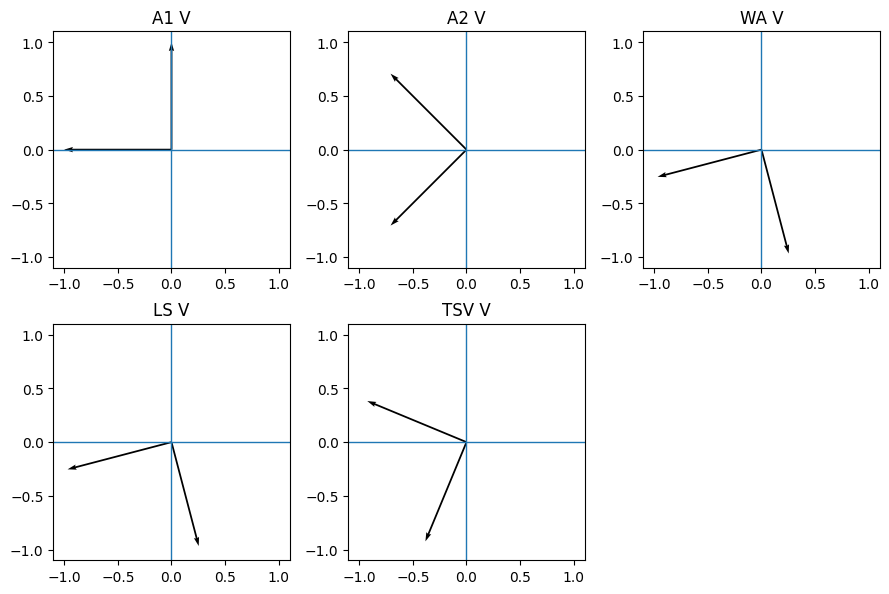

In [ ]:
import matplotlib.pyplot as plt
import math
# ----------------------------
# Toy with tunable orthogonality
# ----------------------------
ortho = 0.5                 # 0 = aligned, 1 = orthogonal
theta_v = ortho * (math.pi/2)

B, Do, Di = 2, 2, 2

v1 = torch.tensor([1.0, 0.0])
v2 = torch.tensor([math.cos(theta_v), math.sin(theta_v)])

u1 = torch.tensor([1.0, 1.0]);  u1 = u1 / u1.norm()
u2 = torch.tensor([1.0, -1.0]); u2 = u2 / u2.norm()

s1, s2 = 2.0, 1.5
A1 = s1 * torch.outer(u1, v1)
A2 = s2 * torch.outer(u2, v2)
a_tilde = torch.stack([A1, A2], dim=0)

A_wa  = merge_avg(a_tilde)
A_ls  = merge_lsopt(a_tilde)
A_tsv = merge_tsv(a_tilde)


# ----------------------------
# Plot right singular vectors
# ----------------------------
def right_singular_vecs(A):
    _, _, Vt = torch.linalg.svd(A, full_matrices=False)
    return Vt.T

def plot_right_vecs(ax, A, title):
    V = right_singular_vecs(A)
    ax.axhline(0, linewidth=1); ax.axvline(0, linewidth=1)
    ax.quiver([0,0], [0,0], V[0,:], V[1,:],
              angles='xy', scale_units='xy', scale=1)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_title(title)

fig, axs = plt.subplots(2, 3, figsize=(9, 6))
plot_right_vecs(axs[0,0], A1,  "A1 V")
plot_right_vecs(axs[0,1], A2,  "A2 V")
plot_right_vecs(axs[0,2], A_wa,"WA V")
plot_right_vecs(axs[1,0], A_ls,"LS V")
plot_right_vecs(axs[1,1], A_tsv,"TSV V")
axs[1,2].axis("off")
plt.tight_layout()
plt.show()

### Geometric interpretation of TSV

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_56485/1681312568.py:95: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Y = A @ X_unit_sphere


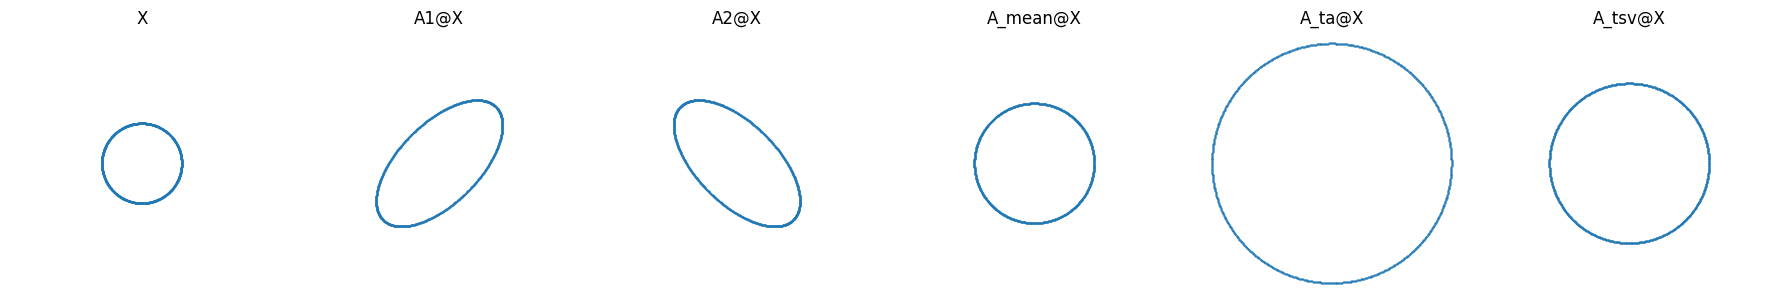

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def rot(deg):
    t = np.deg2rad(deg)
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s], [s, c]])

def merge_mean(As):
    return sum(As) / len(As)

def merge_ta(As):
    return sum(As)

def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    """Finds best ortho approx of x

    Args:
        x (torch.Tensor): (Di, Do)

    Returns:
        torch.Tensor: (Di, Do)
    """
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt

def get_tsv_merge(tensors):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def merge_tsv(As, r=1):
    # U = np.concatenate([np.linalg.svd(A, full_matrices=False)[0][:, :r] for A in As], axis=1)
    # V = np.concatenate([np.linalg.svd(A, full_matrices=False)[2].T[:, :r] for A in As], axis=1)
    # U, _ = np.linalg.qr(U)
    # V, _ = np.linalg.qr(V)
    # Abar = merge_mean(As)
    # B = U.T @ Abar @ V
    # Ub, s, Vhb = np.linalg.svd(B, full_matrices=False)
    # return U @ (Ub * s) @ Vhb @ V.T
    return get_tsv_merge(torch.stack([torch.from_numpy(A) for A in As]))


# data on unit circle
tvs = np.linspace(0, 2*np.pi, 800, endpoint=False)
X_unit_sphere = np.stack([np.cos(tvs), np.sin(tvs)])

R1, R2 = rot(45), rot(-45)
S = np.diag([2.0, 1.0])
A1 = R1 @ S @ R1.T
A2 = R2 @ S @ R2.T

A_mean = merge_mean([A1, A2])
A_ta = merge_ta([A1, A2])
A_tsv  = merge_tsv([A1, A2], r=1)

mats = [
    ("X", np.eye(2)),
    ("A1@X", A1),
    ("A2@X", A2),
    ("A_mean@X", A_mean),
    ("A_ta@X", A_ta),
    ("A_tsv@X", A_tsv),
]

fig, ax = plt.subplots(1, len(mats), figsize=(3*len(mats), 3), sharex=True, sharey=True)
for a, (title, A) in zip(ax, mats):
    Y = A @ X_unit_sphere
    a.plot(Y[0], Y[1], ".", ms=1)
    a.set_title(title); a.set_aspect("equal"); a.axis("off")
plt.tight_layout(); plt.show()


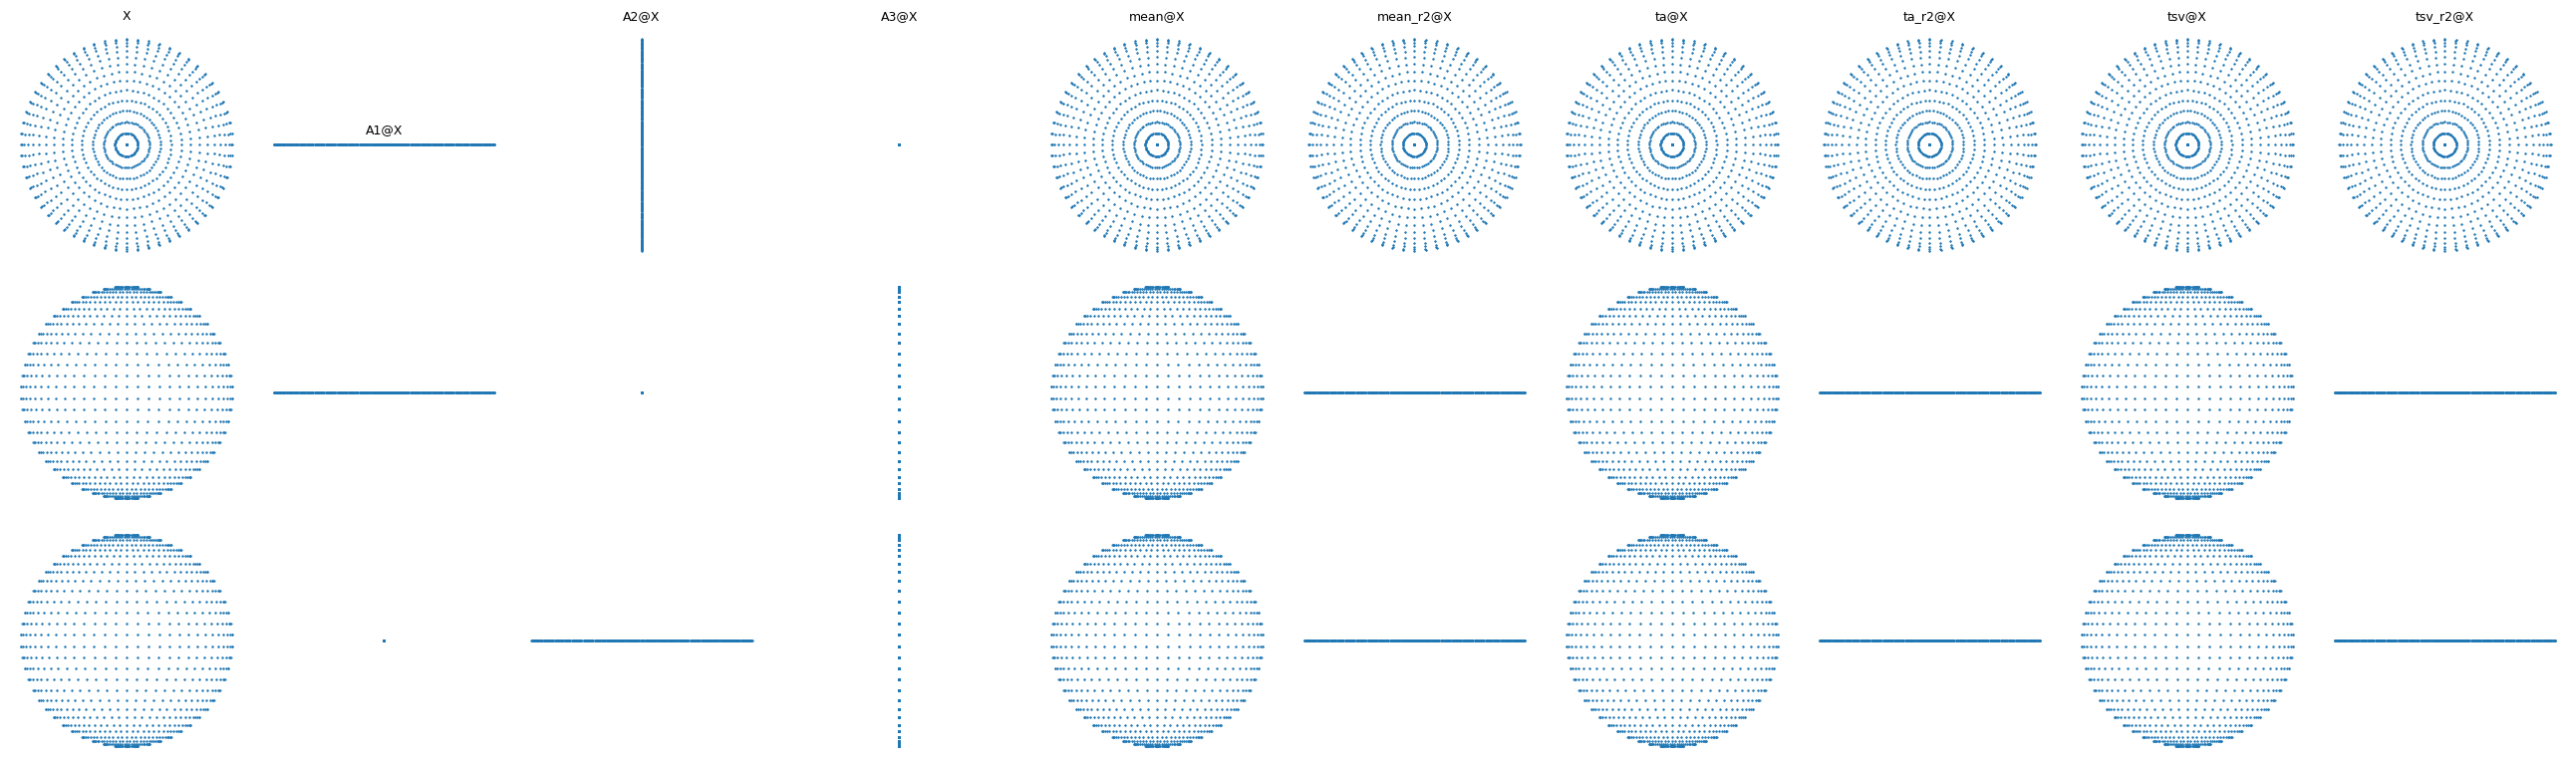

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def merge_mean(As):
    return sum(As) / len(As)

def merge_ta(As):
    return sum(As)

def best_rank_k_np(A, k):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt

def get_tsv_merge(tensors):
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks  # rank per task (with full SVD this becomes 1 in 3-task, 3D case)
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    B, Di, _ = u.shape
    _, _, Do = vt.shape
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)

    u_ortho = compute_procrustes(u_hat)
    vt_ortho = compute_procrustes(vt_hat.T).T
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def merge_tsv(As):
    return get_tsv_merge(torch.stack([torch.from_numpy(A).float() for A in As])).numpy()


# =========================
# 🔥 MINIMAL “AHA” CHANGES:
# 1) go to 3D
# 2) use 3 rank-1 “tasks” on different axes
# 3) enforce a rank budget after merging (rank-2)
# 4) visualize via 2D projections (xy, xz, yz)
# =========================

# data on unit sphere in 3D
phi = np.linspace(0, 2*np.pi, 60, endpoint=False)
theta_v = np.linspace(0, np.pi, 30, endpoint=True)
phi, theta_v = np.meshgrid(phi, theta_v)
X_unit_sphere = np.stack([
    np.sin(theta_v) * np.cos(phi),
    np.sin(theta_v) * np.sin(phi),
    np.cos(theta_v),
]).reshape(3, -1)

# three rank-1-ish maps, orthogonal directions
A1 = np.diag([2.0, 0.0, 0.0])  # stretch x
A2 = np.diag([0.0, 2.0, 0.0])  # stretch y
A3 = np.diag([0.0, 0.0, 2.0])  # stretch z
As = [A1, A2, A3]

A_mean = merge_mean(As)
A_ta   = merge_ta(As)
A_tsv  = merge_tsv(As)

# enforce the same rank budget (this is where WA vs TSV diverge)
k = 2
A_mean_k = best_rank_k_np(A_mean, k)
A_ta_k   = best_rank_k_np(A_ta, k)
A_tsv_k  = best_rank_k_np(A_tsv, k)

mats = [
    ("X", np.eye(3)),
    ("A1@X", A1),
    ("A2@X", A2),
    ("A3@X", A3),

    ("mean@X", A_mean),
    (f"mean_r{k}@X", A_mean_k),

    ("ta@X", A_ta),
    (f"ta_r{k}@X", A_ta_k),

    ("tsv@X", A_tsv),
    (f"tsv_r{k}@X", A_tsv_k),
]

# plot 2D projections: xy, xz, yz
projs = [("xy", (0, 1)), ("xz", (0, 2)), ("yz", (1, 2))]

fig, ax = plt.subplots(
    len(projs), len(mats),
    figsize=(2.6 * len(mats), 2.6 * len(projs)),
    sharex=False, sharey=False
)

for r, (pname, (i, j)) in enumerate(projs):
    for c, (title, A) in enumerate(mats):
        Y = A @ X_unit_sphere
        ax[r, c].plot(Y[i], Y[j], ".", ms=1)
        if r == 0:
            ax[r, c].set_title(title, fontsize=9)
        if c == 0:
            ax[r, c].set_ylabel(pname, rotation=0, labelpad=12, fontsize=10)
        ax[r, c].set_aspect("equal")
        ax[r, c].axis("off")

plt.tight_layout()
plt.show()


### OPT

In [ ]:
import os
import json
from typing import List
import numpy as np
import torch

os.environ["OPENCLIP_CACHEDIR"] = os.environ["SCRATCH"] + "/openclip"


import matplotlib.pyplot as plt
from src.models.task_vectors import NonLinearTaskVector


MODELS_ROOT = os.path.expanduser("models/checkpoints")
# datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
model = "ViT-B-16"
device = "cuda:0"

# Calculate task vectors
task_vectors = []
pretrained_checkpoint = f"{MODELS_ROOT}/{model}/MNISTVal/nonlinear_zeroshot.pt"
for dataset in datasets:
    finetuned_checkpoint = f"{MODELS_ROOT}/{model}/{dataset}Val/nonlinear_finetuned.pt"
    task_vectors.append(
        NonLinearTaskVector(model, pretrained_checkpoint, finetuned_checkpoint)
    )

# # Pull out single matrix
# mats = []

# for key in task_vectors[0].vector:
#     if len(task_vectors[0].vector[key].shape) == 2 and "text_projection" not in key:
#         if task_vectors[0].vector[key].min() == task_vectors[0].vector[key].max() == 0:
#             continue
#         for tv in task_vectors:
#             mats.append(tv.vector[key])
#         break

# mats = torch.stack(mats)

In [ ]:
# Pull out single matrix
mats = []

for layer_name in task_vectors[0].vector:
    if len(task_vectors[0].vector[layer_name].shape) == 2 and "text_projection" not in layer_name:
        if task_vectors[0].vector[layer_name].min() == task_vectors[0].vector[layer_name].max() == 0:
            continue
        for tv in task_vectors:
            mats.append(tv.vector[layer_name])
        break

mats = torch.stack(mats)

In [ ]:
# Save the mats
torch.save(mats, "results/mats.pt")

In [16]:
import torch
# Load the mats
mats = torch.load("results/mats.pt")
print(mats.shape), mats.min(), mats.max()


torch.Size([6, 197, 768])


(None, tensor(-0.0014), tensor(0.0015))

In [32]:
import numpy as np
def calc_rank(S, norm_thresh=0.95):
    # Rank based on approximation error (Eq. 6) in the paper
    rank = np.argmax(np.sqrt(np.cumsum(S.pow(2) / S.pow(2).sum())) > norm_thresh)
    return rank

def compute_sar(u, s, mats):

    # figure out effective rank
    rank_eff = calc_rank(s)
    u = u[:, :rank_eff]

    proj_m_w = torch.einsum("ij,jk,bkl->bil", u, u.T, mats)
    return torch.linalg.norm(proj_m_w, ord="fro", dim=(1, 2)) / torch.linalg.norm(mats, ord="fro", dim=(1, 2))  # (b,)


def compute_delta_m_sum(mats):
    delta_m = torch.sum(mats, dim=0)
    u, s, vt = torch.linalg.svd(delta_m, full_matrices=False)
    return delta_m, u, s

def compute_delta_m_iso(mats):
    delta_m = torch.sum(mats, dim=0)
    u, s, vt = torch.linalg.svd(delta_m, full_matrices=False)
    s_mean = torch.ones_like(s) * s.mean()
    return torch.einsum("ij,j,jk->ik", u, s_mean, vt), u, s

def compute_delta_m_opt(mats):
    delta_t_outers = torch.einsum("bik,bkj->bij", mats, mats.permute(0, 2, 1))
    delta_t_frobs = torch.linalg.norm(mats, ord="fro", dim=(1, 2))[
        :, None, None
    ]
    mat_a = (delta_t_outers / delta_t_frobs).sum(dim=0)
    lam, u = torch.linalg.eig(mat_a)
    return None, u, torch.ones_like(lam)

methods = [
    ("sum", compute_delta_m_sum),
    ("iso", compute_delta_m_iso),
    ("opt", compute_delta_m_opt),
]

rows = []
for method_name, method_fn in methods:
    delta_m, u, s = method_fn(mats)
    sar_m = compute_sar(u, s, mats)
    rows.append({"method": method_name, "sar": sar_m})

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_36156/1199381627.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rank = np.argmax(np.sqrt(np.cumsum(S.pow(2) / S.pow(2).sum())) > norm_thresh)


NotImplementedError: "gt_cpu" not implemented for 'ComplexFloat'

In [28]:
rows

[{'method': 'sum',
  'sar': tensor([0.7909, 0.8007, 0.8295, 0.8179, 0.8240, 0.8547])},
 {'method': 'iso',
  'sar': tensor([0.9549, 0.9521, 0.9563, 0.9526, 0.9525, 0.9568])}]